# Entrenamiento de Modelos — MFCCs Aumentados Diarizados

Versión del notebook que utiliza los datos diarizados aumentados ( / ).

In [1]:
import pickle
import numpy as np
import pandas as pd
import mlflow

#Tablas y Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#Preprocesado
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#Modelos
import joblib
from sklearn.base import clone
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import PredefinedSplit
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mlflow.set_tracking_uri("sqlite:///../resultados/resultados_voces.db")
mlflow.set_experiment("Clasificacion_Modelos_Clasicos_Notebooks")

<Experiment: artifact_location='file:///C:/Users/pedro/git/InvestigacionFinGrado/notebooks/mlruns/2', creation_time=1779615987942, experiment_id='2', last_update_time=1779615987942, lifecycle_stage='active', name='Clasificacion_Modelos_Clasicos_Notebooks', tags={}, trace_location=None, workspace='default'>

In [3]:
ruta_train = '../datos_entrenamiento/train_mfcc_chunked_aumentado_diarizado.pkl'
ruta_test = '../datos_entrenamiento/test_mfcc_chunked_aumentado_diarizado.pkl'

datos_train = pickle.load(open(ruta_train, 'rb'))
datos_test = pickle.load(open(ruta_test, 'rb'))

df_train = pd.DataFrame(datos_train)
df_test = pd.DataFrame(datos_test)

print("Forma del Dataset de entrenamiento:", df_train.shape)
print()
print("Encontrar datos nulos --->", df_train.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_train.isnull().any().any())

print("Forma del Dataset de test:", df_test.shape)
print()
print("Encontrar datos nulos --->", df_test.isnull().sum())
print()
print("¿Hay valores nulos?: ", df_test.isnull().any().any())

Forma del Dataset de entrenamiento: (1768, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False
Forma del Dataset de test: (100, 5)

Encontrar datos nulos ---> nombre_archivo    0
mfccs             0
caja_toracica     0
grupo             0
fold              0
dtype: int64

¿Hay valores nulos?:  False


En este caso, como sí hemos aplicado chunking de manera previa, todas las entradas de nuestro dataframe tendrán el mismo número de coeficientes. Es decir, estamos trabajando con un dataframe normalizado en cuanto a longitud de datos se refiere.

Esto nos permite trabajar de manera directa en la extracción de características en base a los coeficientes de mel, para así pasar directamente al entrenamiento de modelos. Los modelos que vamos a entrenar (RF, SVM y GB) requieren que todas las muestras del conjunto de datos tengan exactamente la misma dimensionalidad de entrada, y esto es algo que tenemos de base en este caso.

## Extracción Características

Al igual que en el notebook anterior, necesitamos transformar las matrices MFCC (30 × 1001) en vectores unidimensionales para poder trabajar con modelos clásicos de ML. Aplicaremos las dos mismas estrategias:

- **Mean+Std pooling**: comprime cada muestra en 60 características (30 medias + 30 desviaciones típicas). Mitiga la maldición de la dimensionalidad y es la representación más robusta para datasets de tamaño moderado.
- **Flatten completo**: genera ~30.030 características por muestra.

In [8]:
df_train.head()

,nombre_archivo,mfccs,caja_toracica,grupo,fold
0,Nueva grabación 35_chunk000_original.wav,"[[-509.01492, -486.2265, -471.39362, -478.1155...",Mixto,Oxigeno Bajo Flujo,1
1,Nueva grabación 35_chunk000_noise.wav,"[[-435.11584, -395.16718, -390.88538, -387.793...",Mixto,Oxigeno Bajo Flujo,1
2,Nueva grabación 35_chunk000_pitch.wav,"[[-505.59113, -474.118, -464.56104, -457.32242...",Mixto,Oxigeno Bajo Flujo,1
3,Nueva grabación 35_chunk000_stretch.wav,"[[-516.5359, -492.094, -474.74338, -478.8489, ...",Mixto,Oxigeno Bajo Flujo,1
4,Nueva grabación 35_chunk001_original.wav,"[[-458.3255, -471.12286, -474.46725, -450.0719...",Mixto,Oxigeno Bajo Flujo,1


In [13]:
#Funcion transformar datasets:
def generar_datasets_aplanados(df):
      metadatos = df[['nombre_archivo', 'grupo', 'caja_toracica', 'fold']]
      n_mfcc = df['mfccs'].iloc[0].shape[0]

      # Dataset 1: Mean + Std (60 features)
      medias = pd.DataFrame(
          df['mfccs'].apply(lambda x: np.mean(x, axis=1)).tolist(),
          columns=[f'mfcc_media_{i+1}' for i in range(n_mfcc)],
          index=df.index
      )
      stds = pd.DataFrame(
          df['mfccs'].apply(lambda x: np.std(x, axis=1)).tolist(),
          columns=[f'mfcc_std_{i+1}' for i in range(n_mfcc)],
          index=df.index
      )
      df_pooling = pd.concat([metadatos, medias, stds], axis=1)

      # Dataset 2: Flatten completo (~30k features)
      df_flatten_features = pd.DataFrame(
          df['mfccs'].apply(lambda x: x.flatten()).tolist(),
          index=df.index
      )
      df_flatten = pd.concat([metadatos, df_flatten_features], axis=1)

      return df_pooling, df_flatten

df_train_pool, df_train_flat = generar_datasets_aplanados(df_train)
df_test_pool, df_test_flat = generar_datasets_aplanados(df_test)

In [14]:
print(f"Shape Train Plano: {df_train_flat.shape} + Shape Test Plano: {df_test_flat.shape}")
print(f"Shape Train Pooleado: {df_train_pool.shape} + Shape Test Pooleado: {df_test_pool.shape}")

Shape Train Plano: (1768, 30034) + Shape Test Plano: (100, 30034)
Shape Train Pooleado: (1768, 64) + Shape Test Pooleado: (100, 64)


### Extracción Características + Modelos DF_FLAT

Comenzaremos aplicando una reducción agresiva de características. Sin embargo, teniendo en cuenta la elevada dimensionalidad de las características, no podemos simplemente pasar a calcular la matriz de correlación, ya que supondría un coste computacional extremadamente elevado.

Sin embargo, podemos aplicar otra técnica que si nos pueda permitir reducir las características de manera agresiva, que es variance_threshold. Esta función permite eliminar todas aquellas características que tengan un valor menor o igual de varianza al que nosotros establezcamos.

In [16]:
columnas_a_quitar_pca = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

scaler_pca = StandardScaler()
subset_X = df_train_flat.drop(columns=columnas_a_quitar_pca)
df_train_flat_transformed = scaler_pca.fit_transform(subset_X)

pca_full = PCA()
pca_full.fit_transform(df_train_flat_transformed)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
print(cumulative_variance)

[0.03017203 0.05574258 0.07663096 ... 0.99998695 0.99999964 0.99999964]


Como podemos observar, ni aplicando un threshold del 10% podemos reducir la dimensionalidad. Lo mejor puede ser pasar directamente a aplicar PCA y SelectKBest, en dos experimentos distintos.

#### PCA en FLAT

En este caso, iremos viendo con cuantas características nos podemos quedar con cada % de varianza, y eligiremos el numero que mejor nos venga.

In [23]:
#Numero de predictores con 95%
n_components_base = df_train_flat.drop(columns = columnas_a_quitar_pca).shape[1]
print(f"Nº Componentes de base: {n_components_base}")
n_components_95 = np.argmax(cumulative_variance >= 0.95)
print(f"Componentes necesarios para explicar el 95%: {n_components_95}")

#Numero de predictores con 90%
n_components_90 = np.argmax(cumulative_variance >= 0.90)
print(f"Componentes necesarios para explicar el 90%: {n_components_90}")

#Numero de predictores con 88%
n_components_88 = np.argmax(cumulative_variance >= 0.88)
print(f"Componentes necesarios para explicar el 88%: {n_components_88}")

#Numero de predictores con 85%
n_components_85 = np.argmax(cumulative_variance >= 0.85)
print(f"Componentes necesarios para explicar el 85%: {n_components_85}")

#Numero de predictores con 80%
n_components_80 = np.argmax(cumulative_variance >= 0.80)
print(f"Componentes necesarios para explicar el 80%: {n_components_80}")

#Numero de predictores con 75%
n_components_75 = np.argmax(cumulative_variance >= 0.75)
print(f"Componentes necesarios para explicar el 75%: {n_components_75}")

Nº Componentes de base: 30030
Componentes necesarios para explicar el 95%: 1183
Componentes necesarios para explicar el 90%: 976
Componentes necesarios para explicar el 88%: 907
Componentes necesarios para explicar el 85%: 814
Componentes necesarios para explicar el 80%: 682
Componentes necesarios para explicar el 75%: 573


Podemos observar como, pese a reducir en cierta medida el % de varianza, nos seguimos encontrando con un gran número de predictores. Lo idóneo, teniendo en cuenta la cantidad de muestras (1768), sería intentar reducir el nº de componentes a unos 125-150 predictores. Seguirá aun así siendo una gran cantidad de predictores, que puede que lleve a cierto sobreentrenamiento, o en un mejor caso, solo nos lleve a un entrenamiento con elevado coste computacional, sin embargo, este número de características representa una relación muestras/predictores que puede ser útil.

Vamos a observar con que % de varianza nos debemos quedar si queremos quedarnos con 125 o 150 componentes principales:

In [26]:
print(f"Varianza explicada con 125 componentes: {cumulative_variance[125]:.4f}")

print(f"Varianza explicada con 150 componentes: {cumulative_variance[150]:.4f}")

Varianza explicada con 125 componentes: 0.3967
Varianza explicada con 150 componentes: 0.4289


Aun que perdamos bastante información, vamos a quedarnos con este numero de componentes (más bien, con el numero de componentes que representan el 45% de la varianza).

In [29]:
X_train_num_pca = df_train_flat.drop(columns=columnas_a_quitar_pca)
X_test_num_pca = df_test_flat.drop(columns=columnas_a_quitar_pca)

scaler_flat = StandardScaler()
X_train_scaled_pca = scaler_flat.fit_transform(X_train_num_pca)
X_test_scaled_pca = scaler_flat.transform(X_test_num_pca)

n_componentes = 0.45 #Nos quedamos con el 45% de la varianza
pca = PCA(n_components=n_componentes, random_state=42)
X_train_pca_flat = pca.fit_transform(X_train_scaled_pca)
X_test_pca_flat = pca.transform(X_test_scaled_pca)

n_componentes_finales = X_train_pca_flat.shape[1]
print(f"El PCA ha seleccionado {n_componentes_finales} componentes principales.")

df_pca_train_flat = pd.DataFrame(
    X_train_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_train_flat.index
)
df_train_flat_1 = pd.concat([df_train_flat[columnas_a_quitar_pca], df_pca_train_flat], axis=1)

df_pca_test_flat = pd.DataFrame(
    X_test_pca_flat,
    columns=[f'MFCC_flat_pca{i+1}' for i in range(n_componentes_finales)],
    index=df_test_flat.index
)
df_test_flat_1 = pd.concat([df_test_flat[columnas_a_quitar_pca], df_pca_test_flat], axis=1)

print("\nVista previa del conjunto de ENTRENAMIENTO post-pca:")
display(df_train_flat_1.head())

El PCA ha seleccionado 169 componentes principales.

Vista previa del conjunto de ENTRENAMIENTO post-pca:


,nombre_archivo,grupo,caja_toracica,fold,MFCC_flat_pca1,MFCC_flat_pca2,MFCC_flat_pca3,MFCC_flat_pca4,MFCC_flat_pca5,MFCC_flat_pca6,...,MFCC_flat_pca160,MFCC_flat_pca161,MFCC_flat_pca162,MFCC_flat_pca163,MFCC_flat_pca164,MFCC_flat_pca165,MFCC_flat_pca166,MFCC_flat_pca167,MFCC_flat_pca168,MFCC_flat_pca169
0,Nueva grabación 35_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,1,1.444071,11.788978,-25.441952,6.140910,12.552386,14.126451,...,-7.936941,6.940764,-3.376883,3.527169,-0.281198,11.054359,6.941899,-0.683325,4.598691,0.288666
1,Nueva grabación 35_chunk000_noise.wav,Oxigeno Bajo Flujo,Mixto,1,-39.310089,0.379854,-36.466728,6.307034,5.448895,16.521191,...,-6.479118,5.213386,-3.852669,3.683816,-0.739004,9.429631,4.597404,-0.232495,2.509028,0.996062
2,Nueva grabación 35_chunk000_pitch.wav,Oxigeno Bajo Flujo,Mixto,1,2.079954,18.204094,-24.073502,1.847494,12.733790,16.649269,...,-7.277556,7.362336,-5.176919,-3.639845,2.689348,-1.993621,-3.615815,-5.071625,2.360361,3.051685
3,Nueva grabación 35_chunk000_stretch.wav,Oxigeno Bajo Flujo,Mixto,1,12.800494,18.133602,-39.319370,2.507896,-10.885415,-1.063482,...,1.440177,1.730073,0.476917,0.832628,1.380772,-0.890280,1.990083,0.680759,2.273174,0.495324
4,Nueva grabación 35_chunk001_original.wav,Oxigeno Bajo Flujo,Mixto,1,23.618427,22.044510,-15.689096,2.087357,16.212799,8.454201,...,-0.797280,-4.194725,-0.602123,-3.354687,-4.620920,-1.242857,7.448147,-0.288343,-4.777297,-0.010241


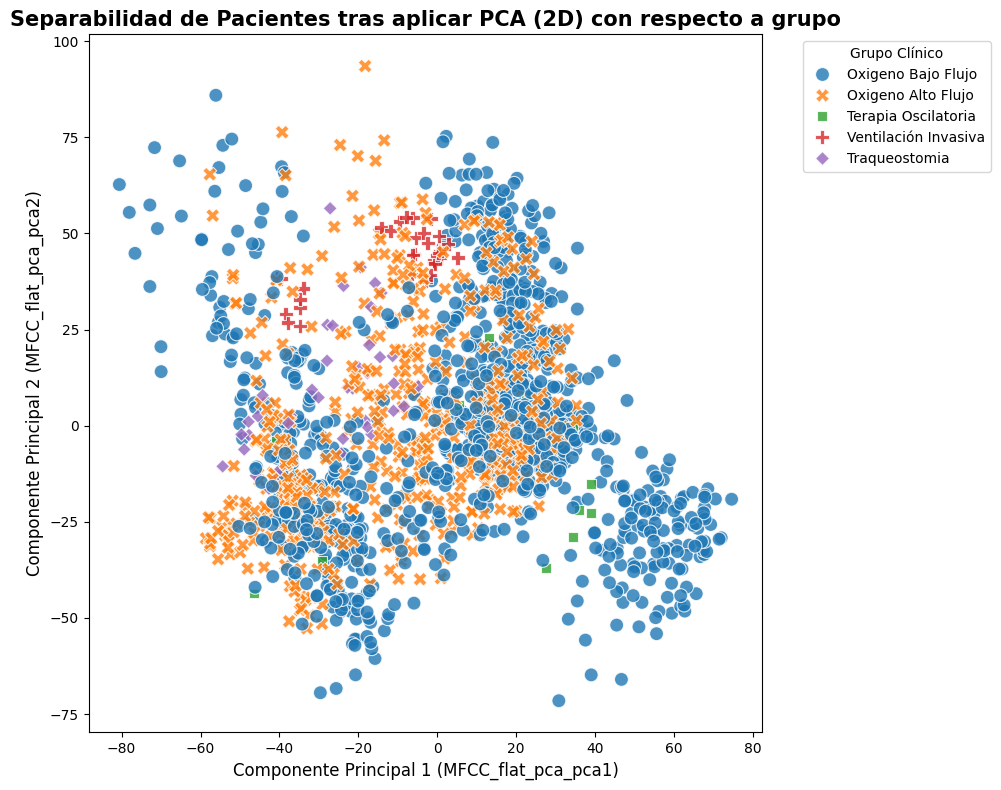

In [31]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_flat_1, 
    x='MFCC_flat_pca1', 
    y='MFCC_flat_pca2', 
    hue='grupo', 
    style='grupo', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a grupo', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Grupo Clínico')

plt.tight_layout()
plt.show()

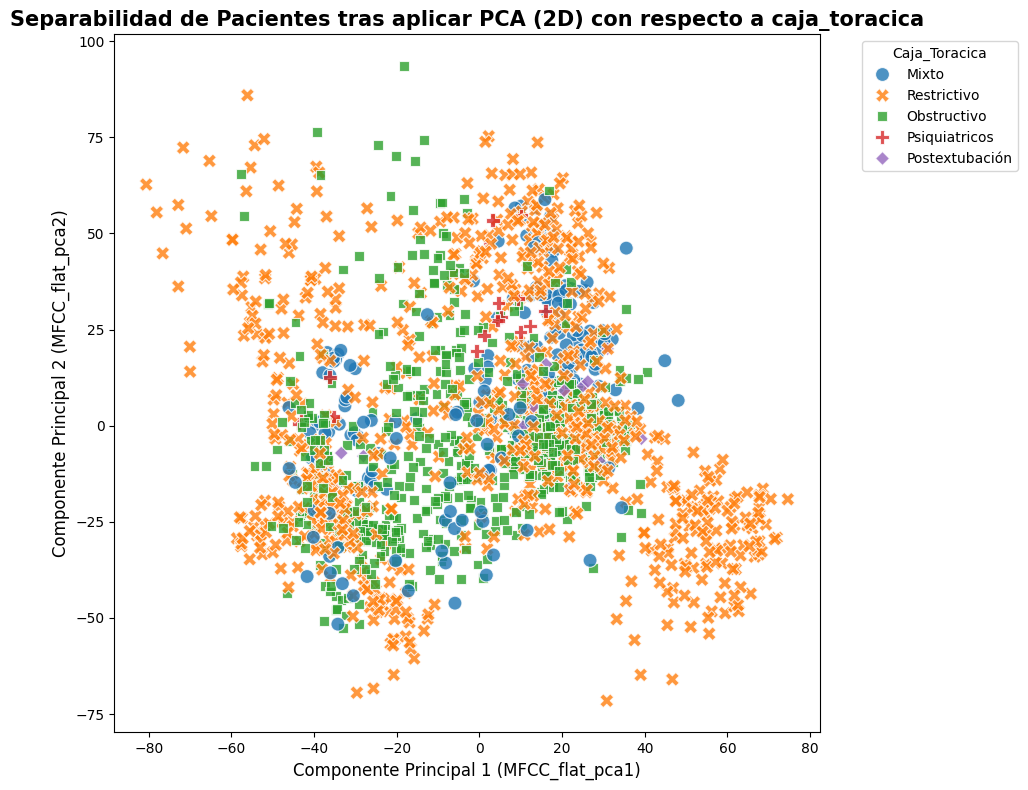

In [33]:
#Breve análisis visual de los datos con PCA.
plt.figure(figsize=(10, 8))

#Elegimos los 2 primeros Embedding por que son los que mas información aportan
sns.scatterplot(
    data=df_train_flat_1, 
    x='MFCC_flat_pca1', 
    y='MFCC_flat_pca2', 
    hue='caja_toracica', 
    style='caja_toracica', 
    s=100,         
    alpha=0.8      
)

plt.title('Separabilidad de Pacientes tras aplicar PCA (2D) con respecto a caja_toracica', fontsize=15, fontweight='bold')
plt.xlabel('Componente Principal 1 (MFCC_flat_pca1)', fontsize=12)
plt.ylabel('Componente Principal 2 (MFCC_flat_pca2)', fontsize=12)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Caja_Toracica')

plt.tight_layout()
plt.show()

Con estos gráficos de dispersión buscamos representar cada chunk como un punto en un gráfico de coordenadas, teniendo en cuenta los valores de MFCC_flat_pca1 y MFCC_flat_pca2. Los 2 primeros componentes principales de un PCA son aquellas que agrupan mayor cantidad de información (varianza). En ambos gráficos podemos observar que no hay nubes de puntos claramente separadas.

En este caso podemos observar que los datos presentan una extrema complejidad acústica. El nivel de solapamiento entre las clases de mayor volumen confirma que los diferentes grupos y patologías no son linealmente separables utilizando únicamente sus dos componentes de mayor varianza.

Sin embargo, esta misma densidad de puntos contiene patrones subyacentes valiosos. Aunque a nivel global observemos una gran mezcla, la concentración de datos sugiere que en el espacio multidimensional del PCA existen vecindarios muy poblados de chunks. La existencia de estas densidades locales justifica el uso, de nuevo, de modelos como K-Nearest Neighbors (KNN).

#### Entrenamiento Modelos Flat con PCA

Para este caso aplicaremos modelos básicos como SVM, RF o GB sobre los datos procesados de Embedding con pca (Primera ruta). Como hemos observado, los datos de momento no presentan mucha correlación con respecto al grupo o a la caja_toracica (patología). Esperamos que para este primer análisis no obtener resultados excesivamente excelentes.

In [ ]:
from sklearn.metrics import make_scorer
scoring_cv = {
    'accuracy':    make_scorer(accuracy_score),
    'f1_macro':    make_scorer(f1_score, average='macro',    zero_division=0),
    'f1_weighted': make_scorer(f1_score, average='weighted', zero_division=0),
}

def evaluar_modelo_pca_flat(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c = grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c = grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv", f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv", f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [39]:
columnas_pca = [col for col in df_train_flat_1.columns if 'pca' in col]

X_train_model = df_train_flat_1[columnas_pca]
X_test_model = df_test_flat_1[columnas_pca]

y_train_grupo = df_train_flat_1['grupo']
y_test_grupo = df_test_flat_1['grupo']

y_train_caja = df_train_flat_1['caja_toracica']
y_test_caja = df_test_flat_1['caja_toracica']

In [41]:
folds_oficiales = df_train_flat_1['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 86.00% | F1-Score (Macro): 36.56%
CAJA TORÁCICA -> Accuracy: 43.00% | F1-Score (Macro): 21.67%


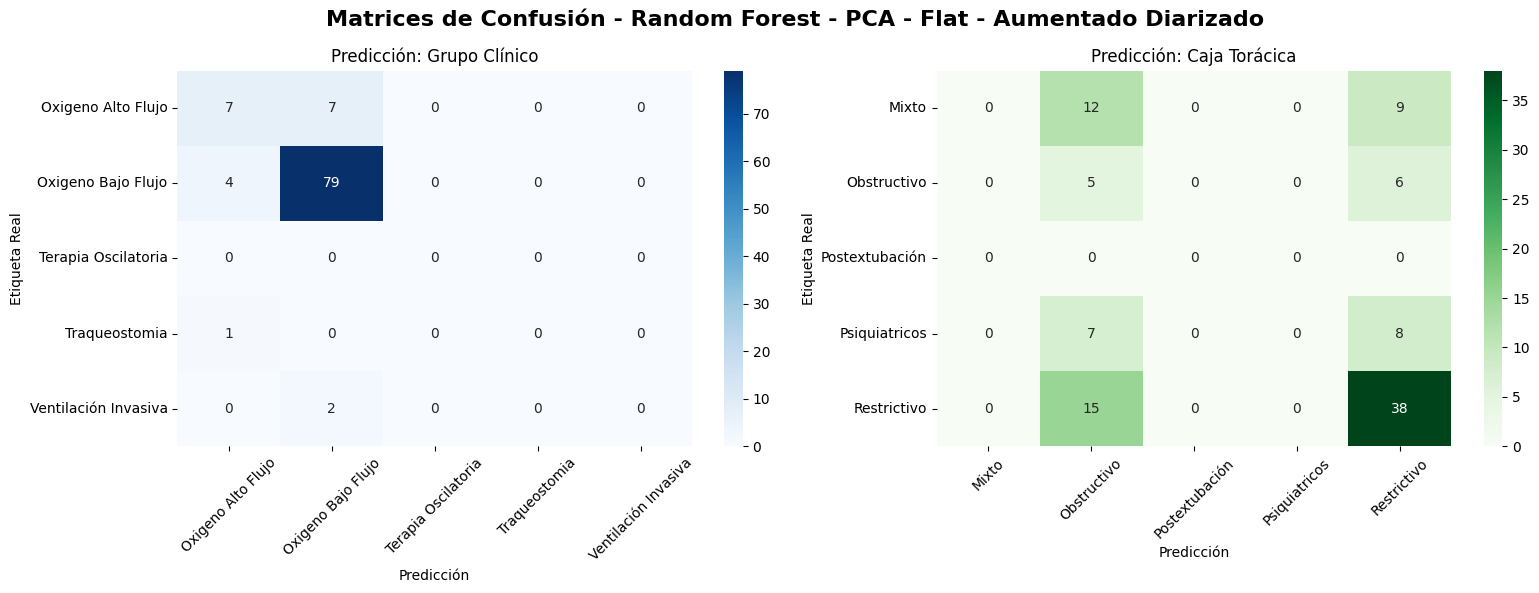

In [43]:
#Tunearemos los hiperparámetros con las ejecuciones y veremos cuales son las mejores configuraciones para cada modelo. Para cada uno haremos que la ejecución inicial sea con 
#hiperparámetros base de la documentación

#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 150}
GRUPOS -> Accuracy: 81.00% | F1-Score (Macro): 34.38%
CAJA TORÁCICA -> Accuracy: 44.00% | F1-Score (Macro): 23.81%


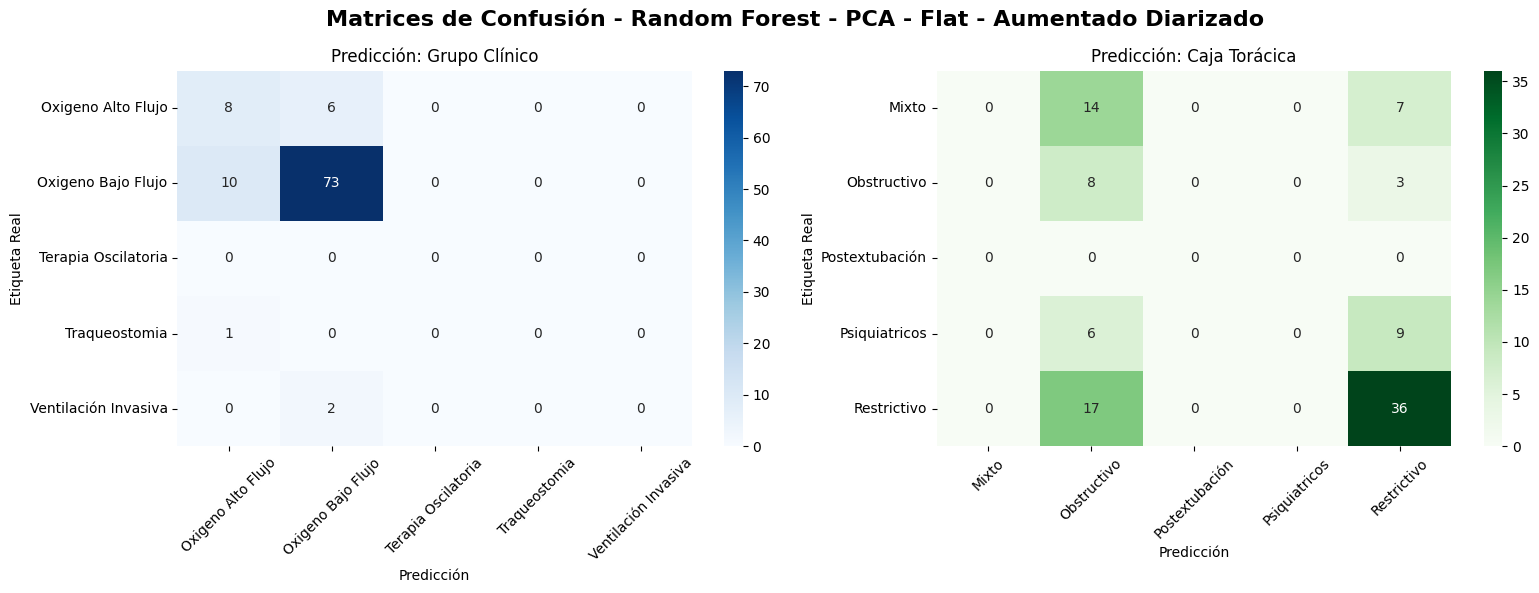

In [45]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")


Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
GRUPOS -> Accuracy: 86.00% | F1-Score (Macro): 38.66%
CAJA TORÁCICA -> Accuracy: 46.00% | F1-Score (Macro): 24.66%


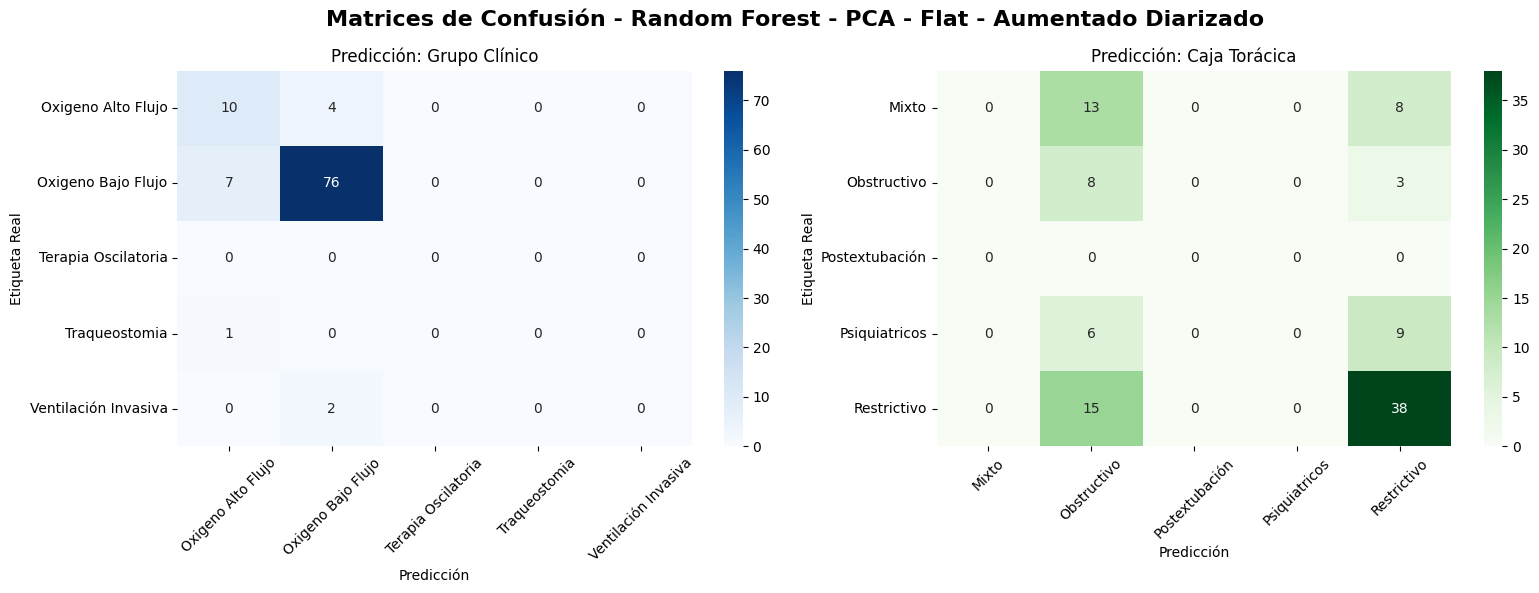

In [47]:
param_grid_rf_2_grupo_flat_pca = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_2_caja_flat_pca = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [5, 10],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_grupo_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_caja_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 8, 'min_samples_split': 2, 'n_estimators': 300}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 10, 'n_estimators': 100}
GRUPOS -> Accuracy: 81.00% | F1-Score (Macro): 35.08%
CAJA TORÁCICA -> Accuracy: 45.00% | F1-Score (Macro): 23.28%


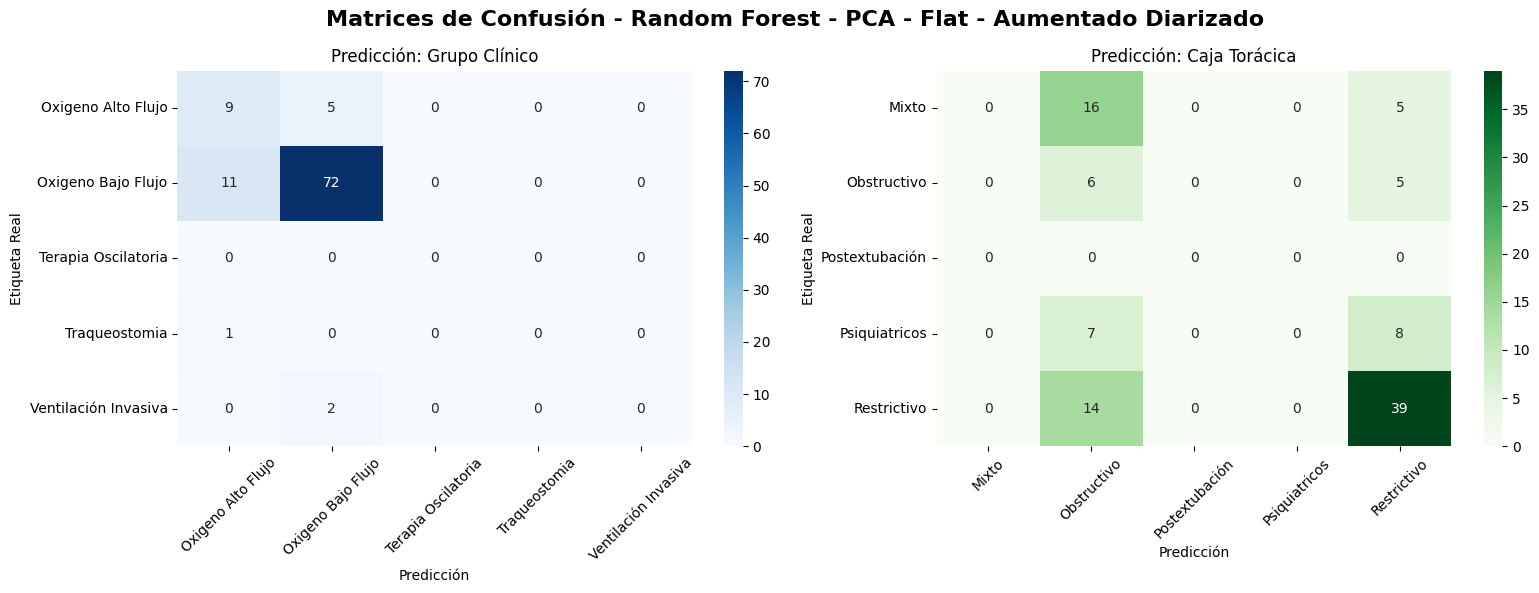

In [49]:
param_grid_rf_3_grupo_flat_pca = {
    'n_estimators': [200, 300],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [6, 8],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_3_caja_flat_pca = {
    'n_estimators': [100, 150],      
    'max_depth': [None],        
    'min_samples_split': [10, 15],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_grupo_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_3_caja_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 6, 'min_samples_split': 2, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}
GRUPOS -> Accuracy: 86.00% | F1-Score (Macro): 38.66%
CAJA TORÁCICA -> Accuracy: 46.00% | F1-Score (Macro): 24.66%


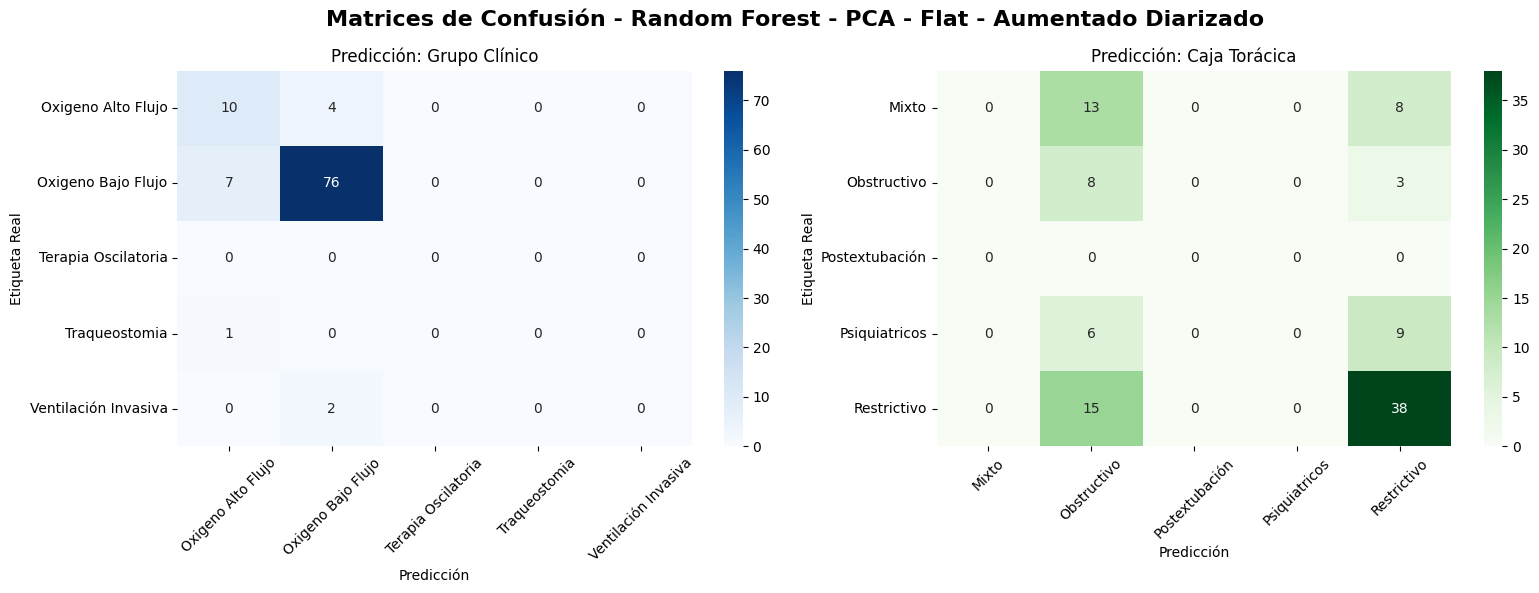

In [51]:
param_grid_rf_final_grupo_flat_pca = {
    'n_estimators': [200],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_flat_pca = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [10],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_flat_pca, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_rf_grupo, grid_rf_caja, "Random Forest - PCA - Flat - Aumentado Diarizado")

##### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.00% | F1-Score (Macro): 30.35%
CAJA TORÁCICA -> Accuracy: 44.00% | F1-Score (Macro): 28.49%


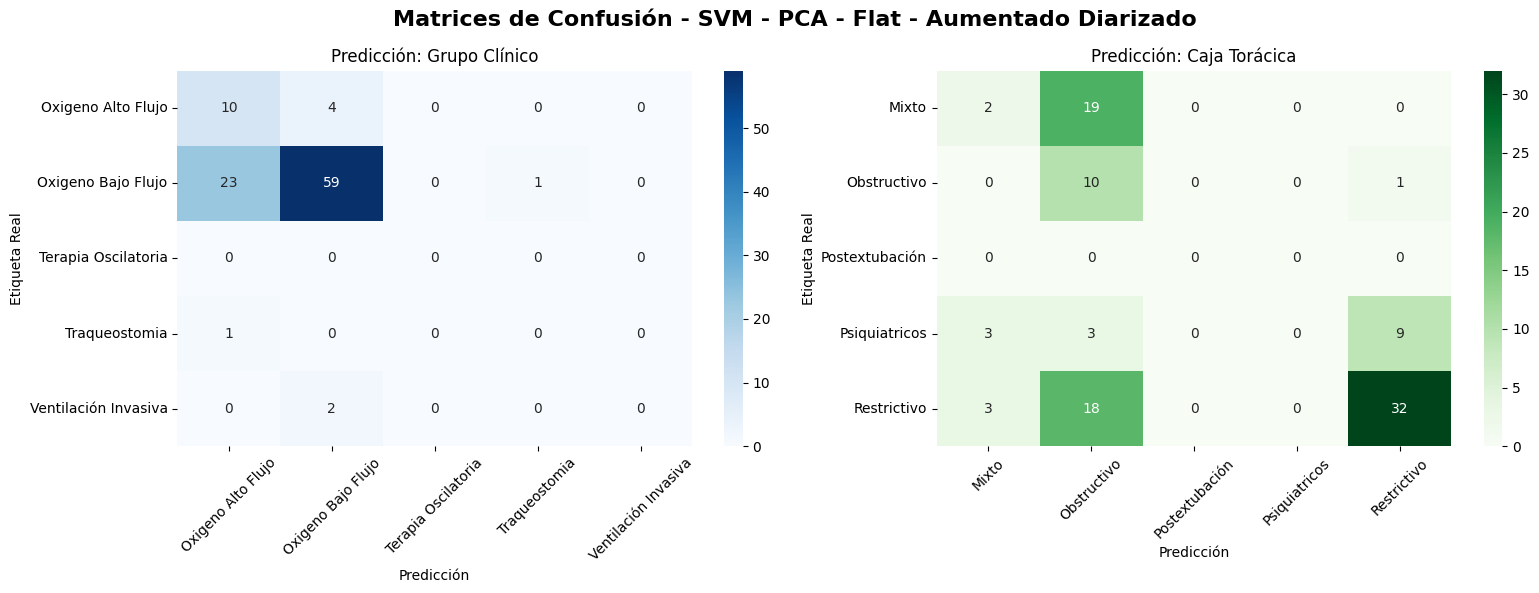

In [53]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")



Mejores Hiperparámetros para Grupo Clínico: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 59.00% | F1-Score (Macro): 26.37%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 26.75%


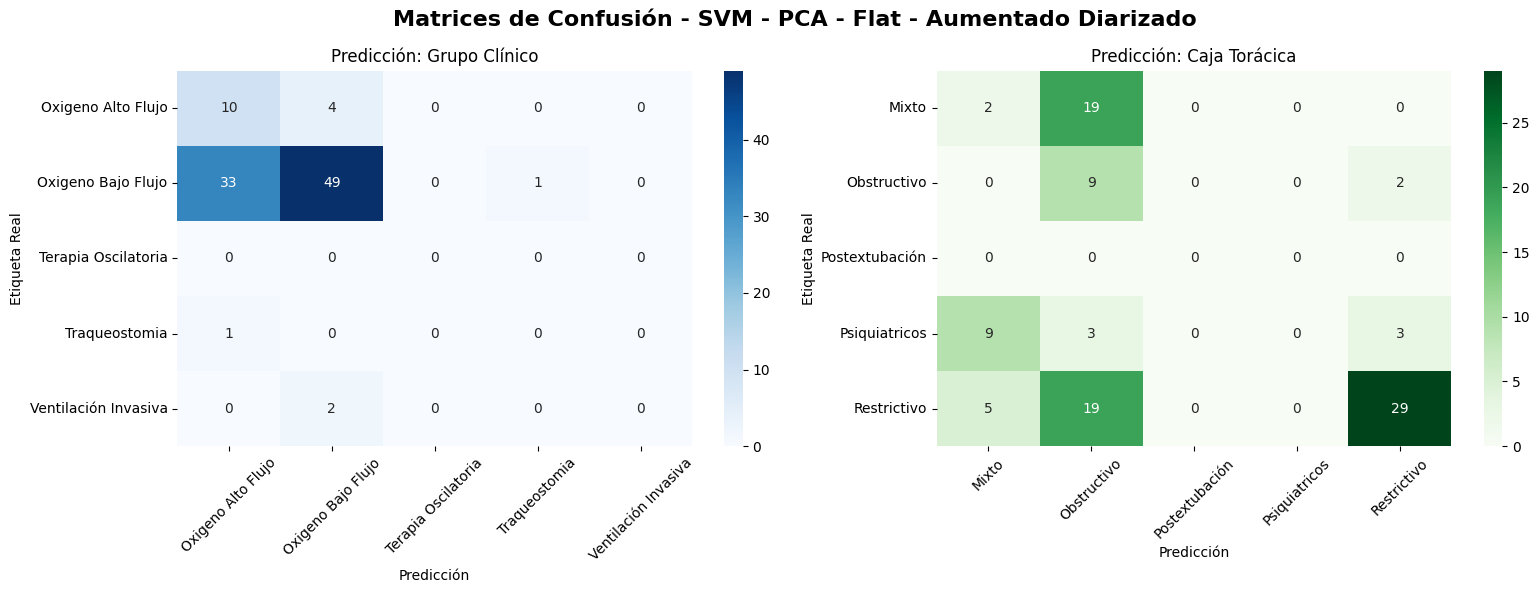

In [54]:
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.00% | F1-Score (Macro): 30.35%
CAJA TORÁCICA -> Accuracy: 47.00% | F1-Score (Macro): 28.38%


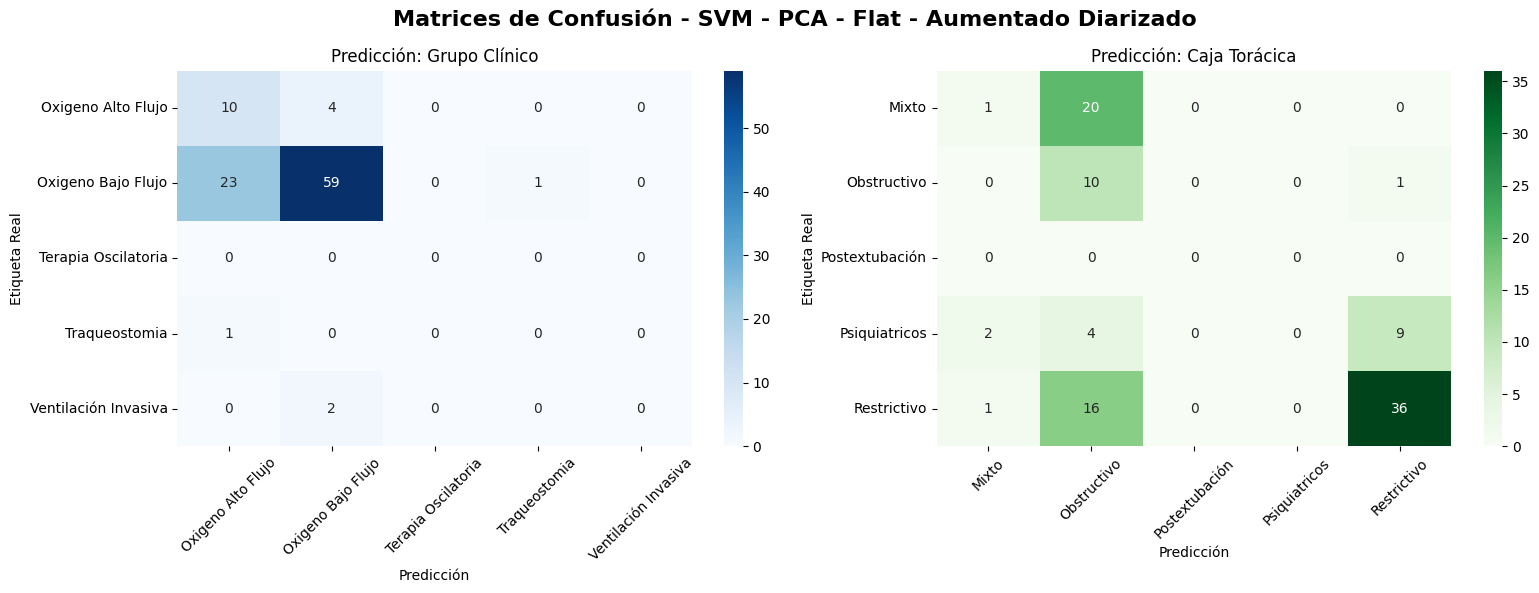

In [58]:
param_grid_svm_2_pca_flat = {
    'C': [1.0, 2.0, 2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.00% | F1-Score (Macro): 30.35%
CAJA TORÁCICA -> Accuracy: 47.00% | F1-Score (Macro): 28.38%


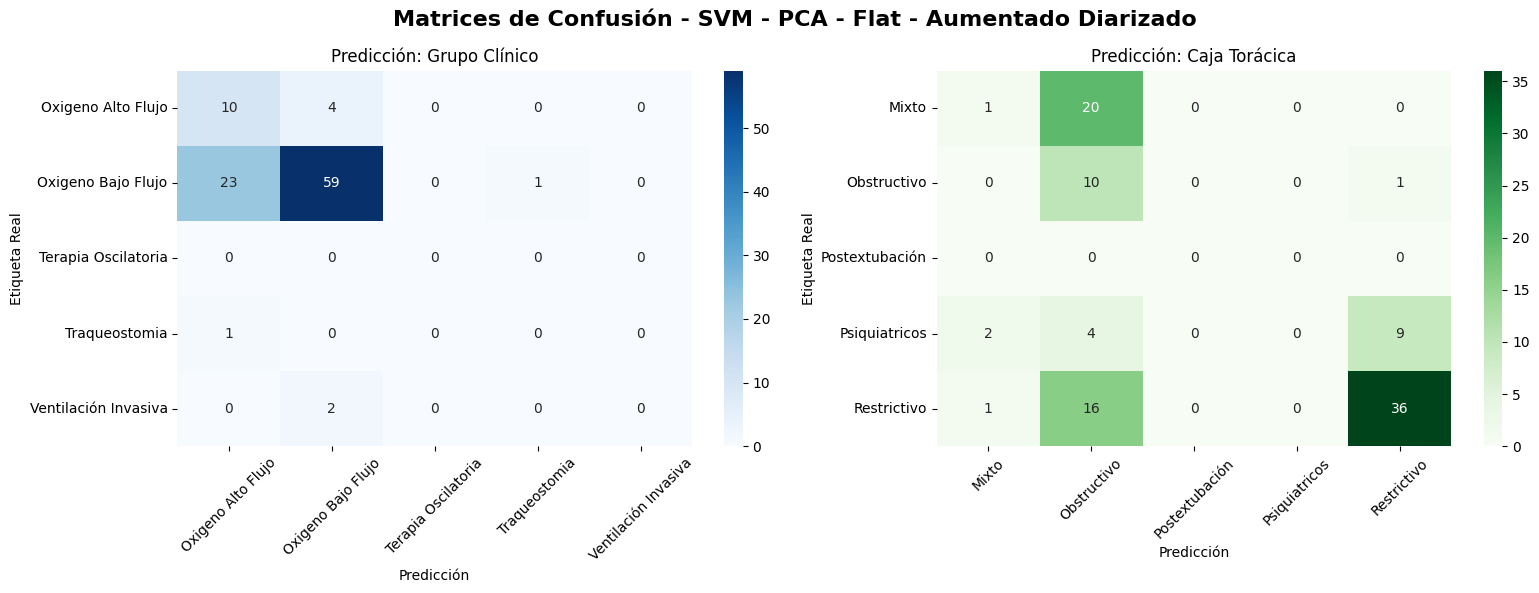

In [60]:
param_grid_svm_grupo_pca_flat_final = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_caja_pca_flat_final = {
    'C': [2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_grupo_pca_flat_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_caja_pca_flat_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_svm_grupo, grid_svm_caja, "SVM - PCA - Flat - Aumentado Diarizado")

#### LightGBM

En lugar del `GradientBoostingClassifier` de scikit-learn, utilizaremos **LightGBM** (*Light Gradient Boosting Machine*). Ambos pertenecen a la familia de *gradient boosting*, pero difieren fundamentalmente en cómo construyen los árboles.

El GB clásico de scikit-learn evalúa todos los posibles valores de corte para cada característica en cada nodo, con una complejidad aproximada de **O(T × n × d)** —siendo *T* el número de estimadores, *n* las muestras y *d* las características—, y lo hace de forma **secuencial** sin paralelización interna.

LightGBM resuelve esto mediante árboles basados en **histogramas**: discretiza los valores de cada característica en un número fijo de bins (255 por defecto), reduciendo el coste de búsqueda de splits a **O(T × bins × d)**, independientemente del número de muestras. En nuestro caso concreto, trabajamos con 1074 muestras de entrenamiento tras el chunking, lo que unido a las 171 características PCA hace que el GB clásico sea desproporcionadamente costoso. Adicionalmente, LightGBM soporta paralelización interna en la construcción de árboles, a diferencia del GB clásico.

Otra ventaja es que LightGBM acepta el parámetro `class_weight='balanced'` de forma nativa, por lo que no es necesario calcular `sample_weight` manualmente como en el GB de scikit-learn.

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 79.00% | F1-Score (Macro): 34.04%
CAJA TORÁCICA -> Accuracy: 43.00% | F1-Score (Macro): 26.65%


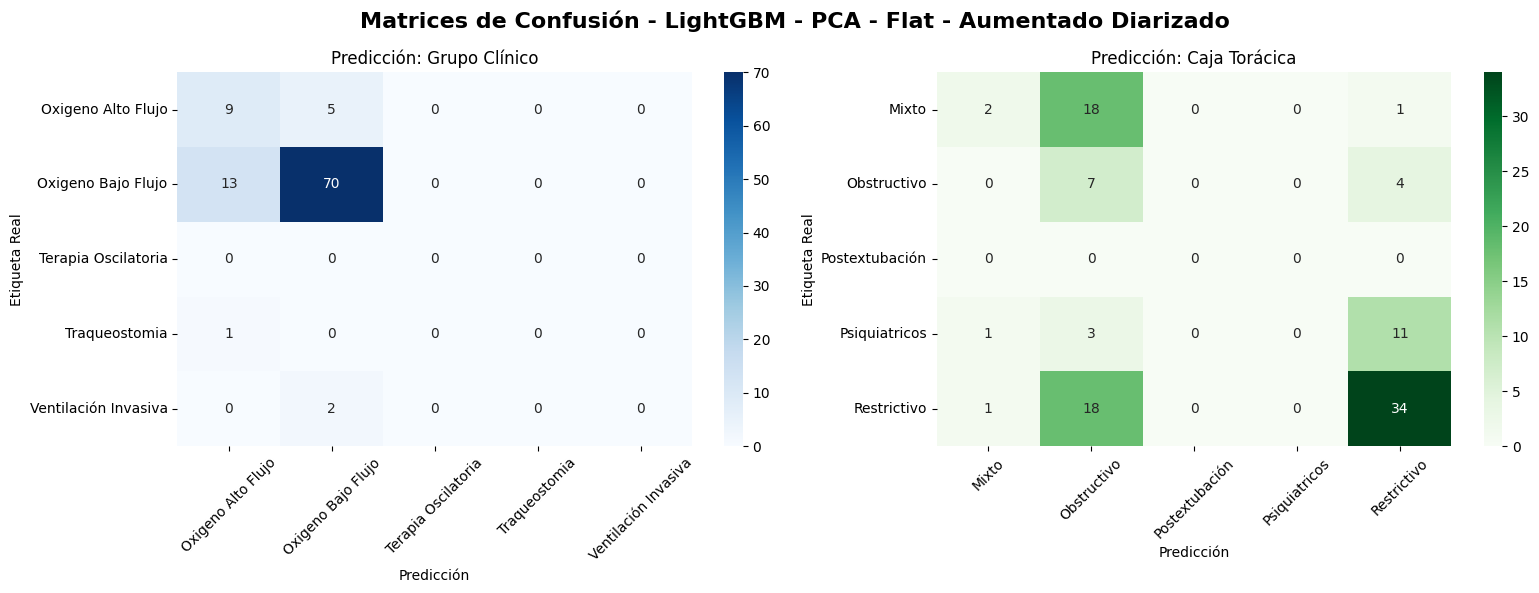

In [62]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
GRUPOS -> Accuracy: 79.00% | F1-Score (Macro): 34.66%
CAJA TORÁCICA -> Accuracy: 41.00% | F1-Score (Macro): 23.76%


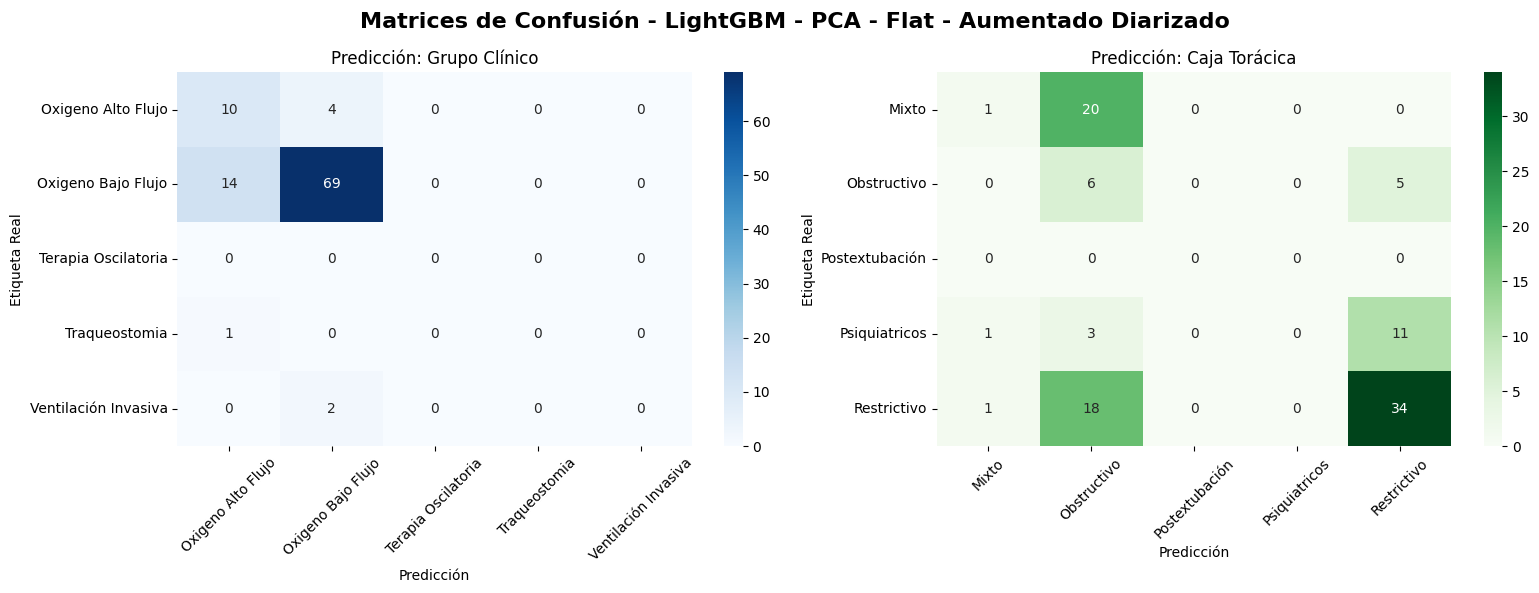

In [63]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 300, 'num_leaves': 63}
GRUPOS -> Accuracy: 79.00% | F1-Score (Macro): 34.66%
CAJA TORÁCICA -> Accuracy: 40.00% | F1-Score (Macro): 23.34%


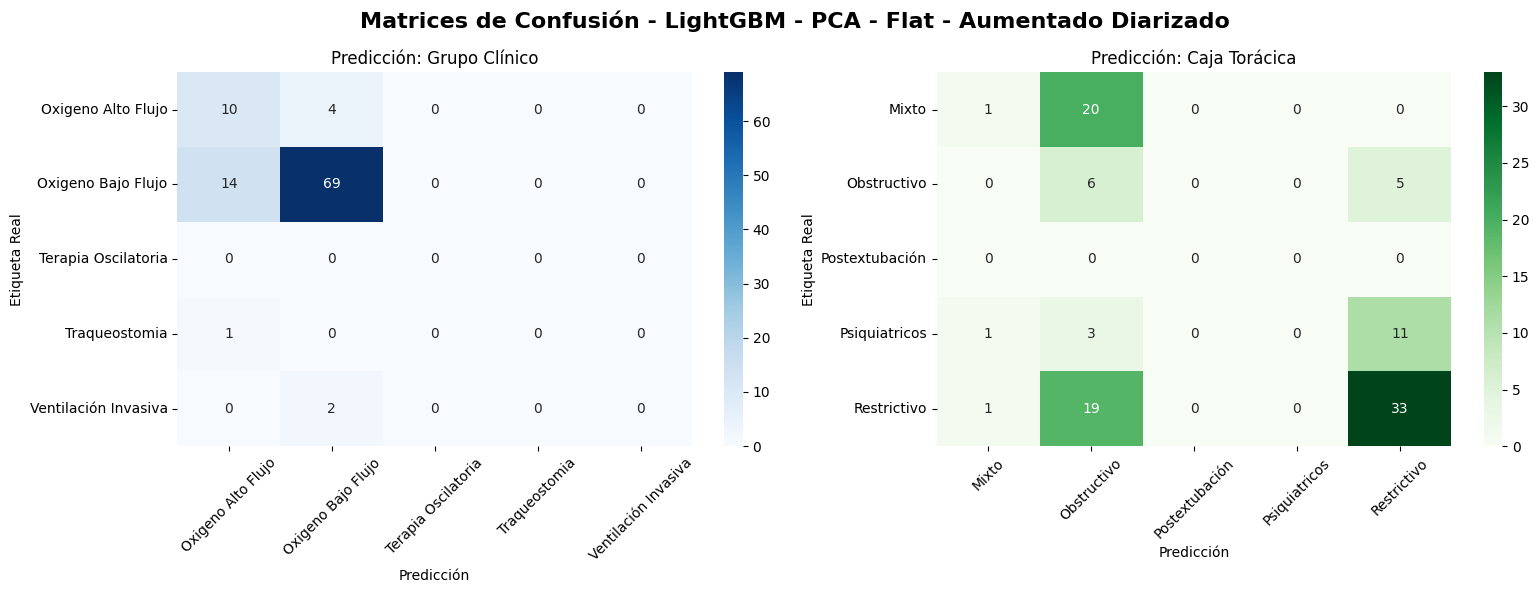

In [67]:
param_grid_lgbm_2_grupo_pca_flat = {
    'n_estimators': [200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

param_grid_lgbm_2_caja_pca_flat = {
    'n_estimators': [100, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_grupo_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_caja_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 79.00% | F1-Score (Macro): 34.66%
CAJA TORÁCICA -> Accuracy: 43.00% | F1-Score (Macro): 26.65%


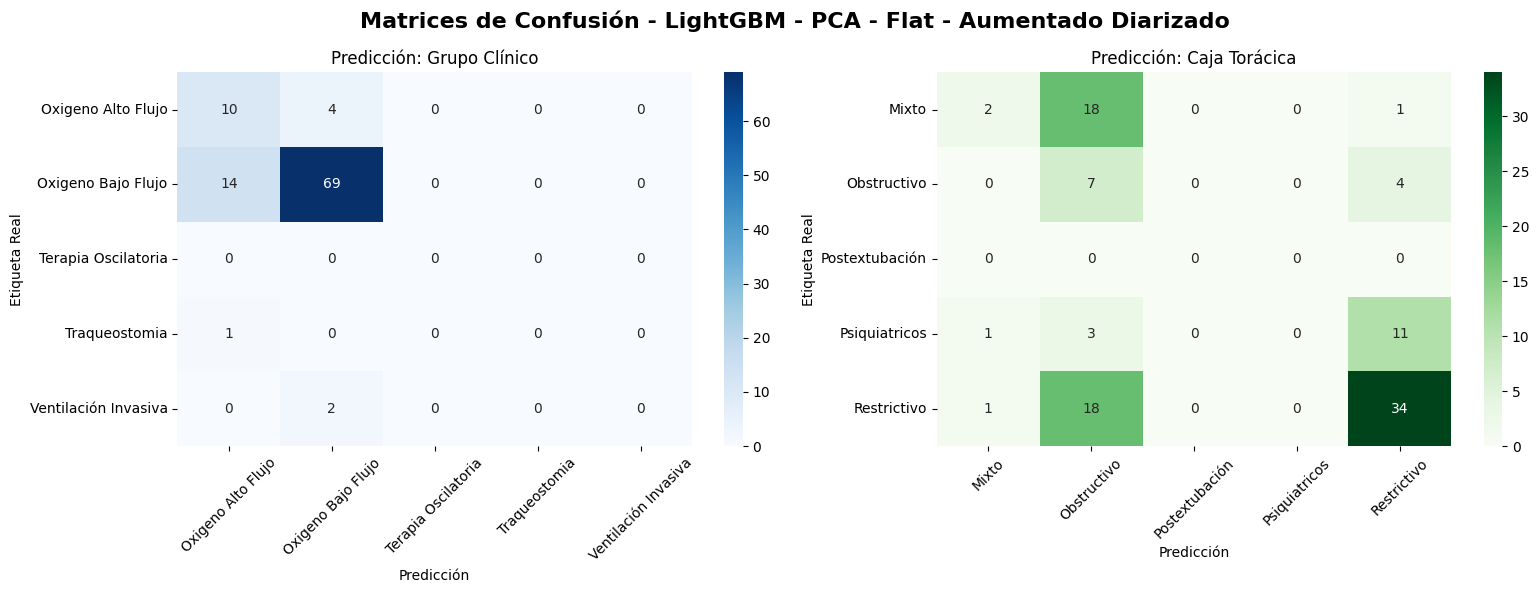

In [69]:
param_grid_lgbm_final_grupo_pca_flat = {
    'n_estimators': [200],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [50]
}

param_grid_lgbm_final_caja_pca_flat = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "PCA")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pca_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pca_flat(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - PCA - Flat - Aumentado Diarizado")

##### KNN

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 75.00% | F1-Score (Macro): 33.16%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 21.02%


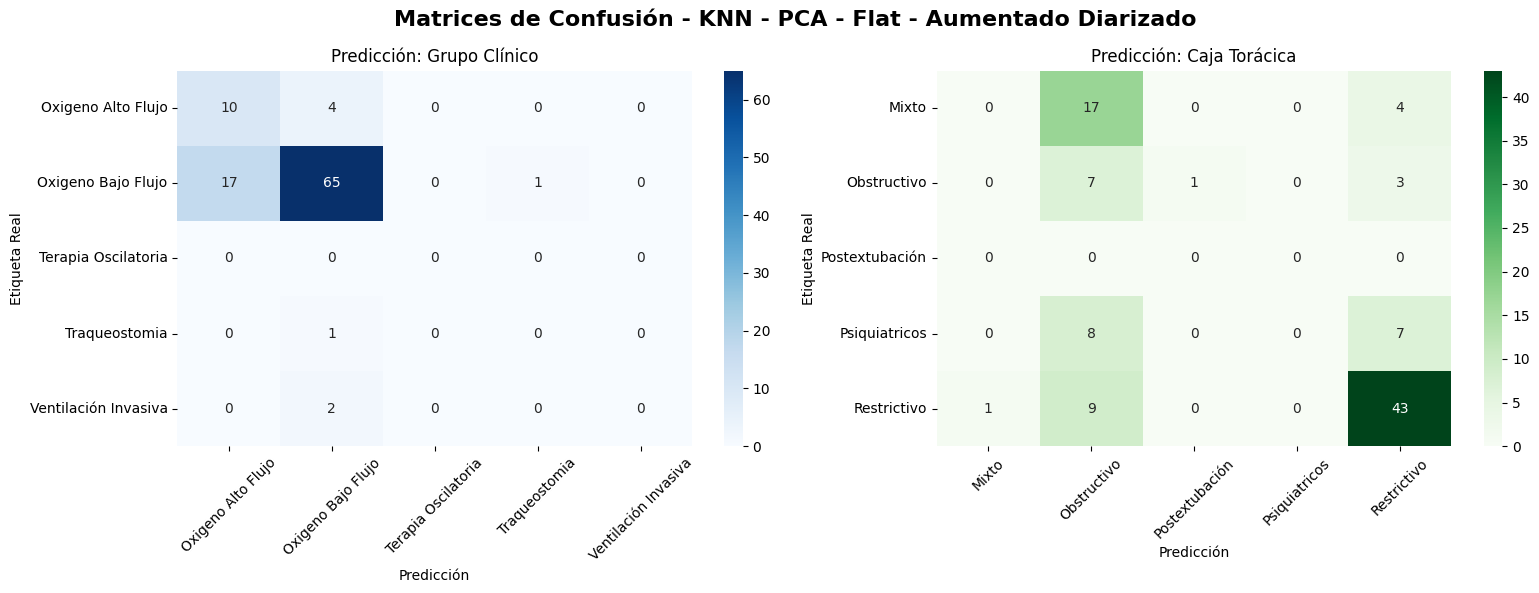

In [72]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'cosine', 'n_neighbors': 5, 'weights': 'uniform'}
GRUPOS -> Accuracy: 64.00% | F1-Score (Macro): 27.00%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 22.91%


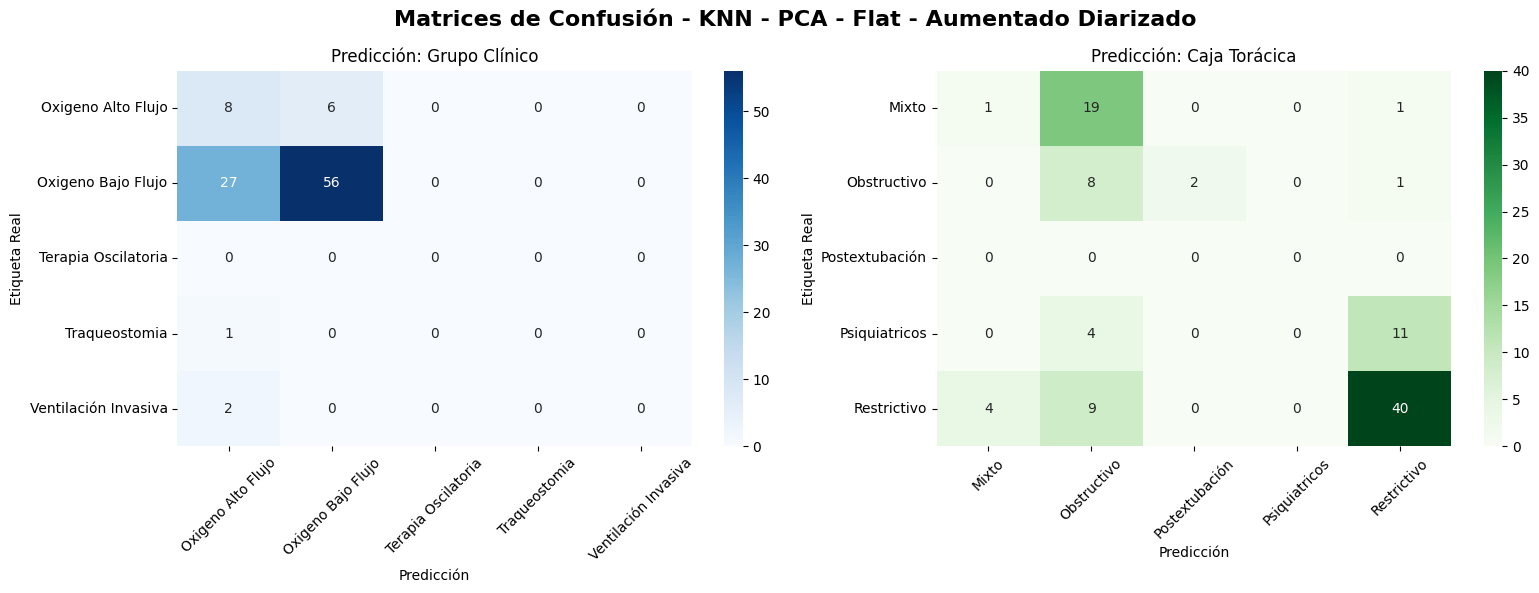

In [73]:
param_grid_knn_1 = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 64.00% | F1-Score (Macro): 27.00%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 19.94%


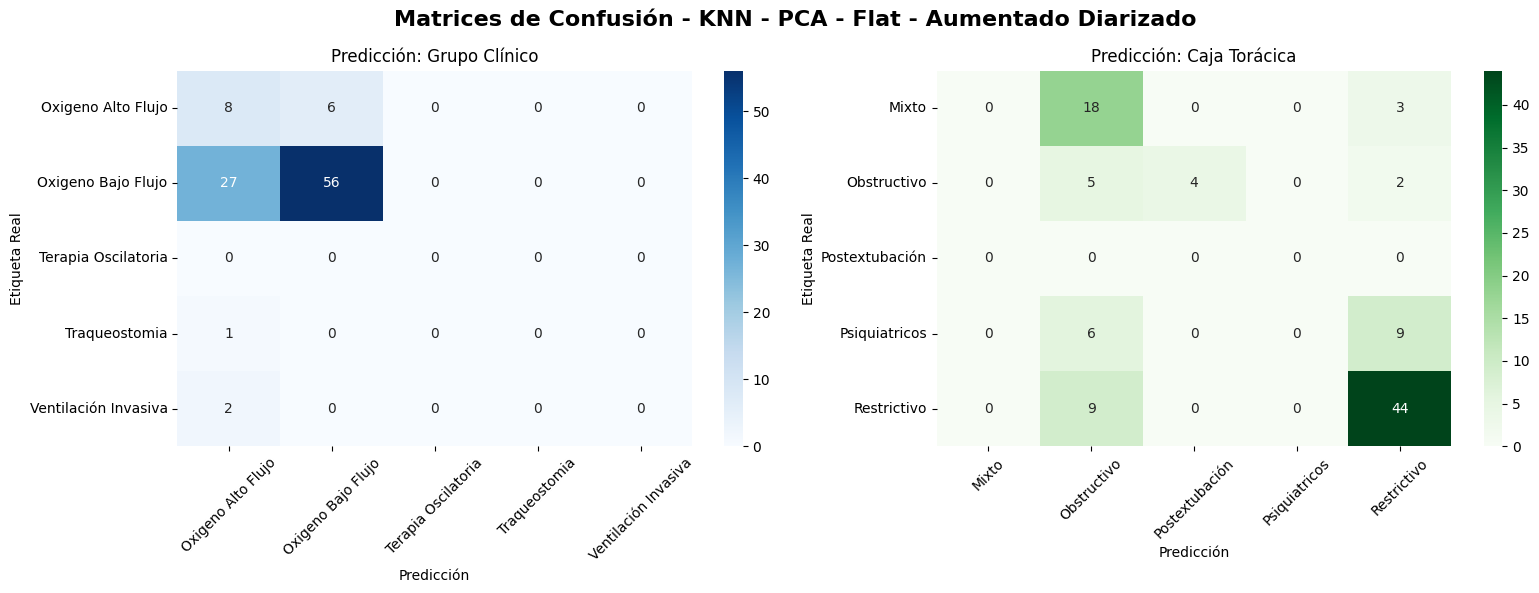

In [76]:
param_grid_knn_2_minkowski = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tune2_minkowski"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 75.00% | F1-Score (Macro): 33.16%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 21.02%


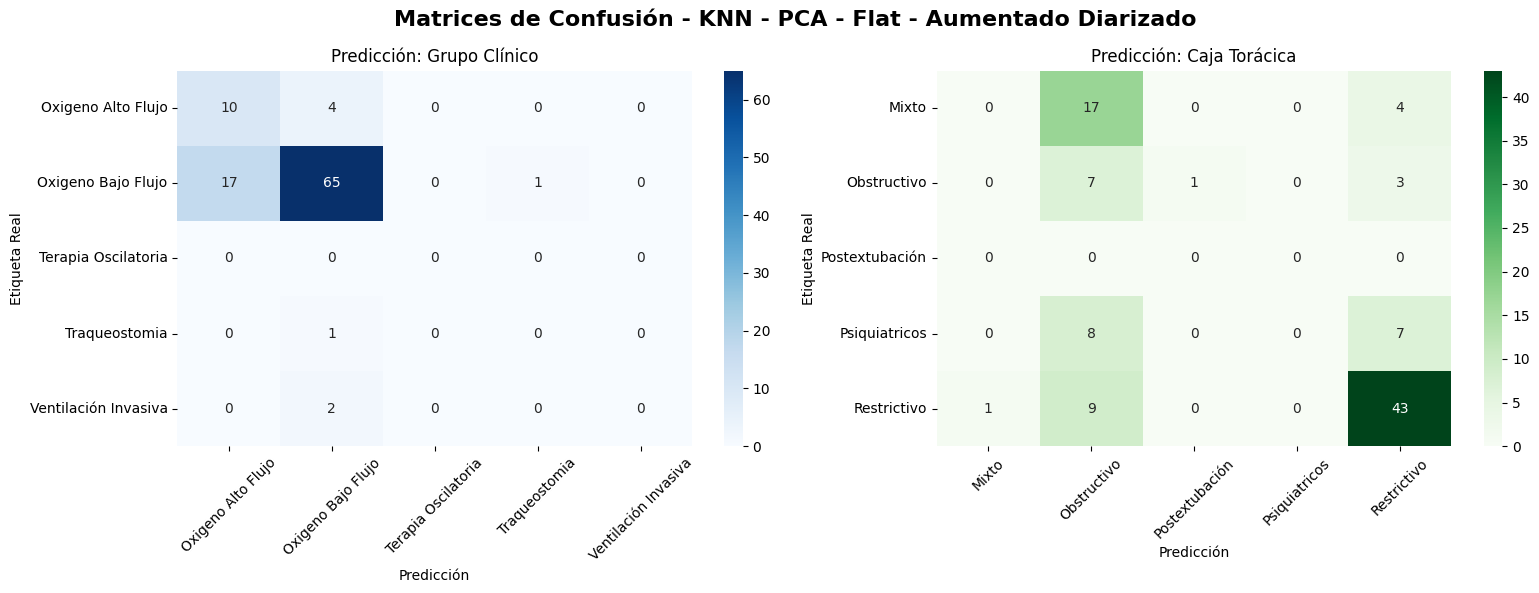

In [78]:
#El mejor es el de base:
param_grid_final_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]              
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_pca_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "PCA")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_final_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_final_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pca_flat(grid_knn_grupo, grid_knn_caja, "KNN - PCA - Flat - Aumentado Diarizado")

#### SelectKBest en FLAT

Nosotros, para hacer la selección supervisada de características usando de la técnica SelectKBest, seleccionaremos las mejores características para grupo y las mejores características para caja toracica: esto nos llevaría a tener dos datasets distintos, uno para cada clase a predecir.

In [83]:
columnas_a_quitar = columnas_a_quitar_pca

#Separamos valores a usar en la predicción de las otras columnas:
X_train_num = df_train_flat.drop(columns=columnas_a_quitar)
X_test_num = df_test_flat.drop(columns=columnas_a_quitar)

#Escalamos valores
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

#Obtenemos metadatos
meta_train = df_train_flat[columnas_a_quitar].reset_index(drop=True)
meta_test = df_test_flat[columnas_a_quitar].reset_index(drop=True)

In [84]:
y_train_grupo = meta_train['grupo']
y_test_grupo = meta_test['grupo']

y_train_caja = meta_train['caja_toracica']
y_test_caja = meta_test['caja_toracica']

K_FEATURES = 75 #Seleccionamos las 50 mejores características.

# Seleccionamos 75 características. Con 1692 muestras la relación muestras/características
# (≈23:1) es muy favorable. Al ser SelectKBest supervisado (ANOVA F-test), estas 75
# características son las de mayor correlación estadística con la variable objetivo,
# a diferencia del PCA que opera de forma no supervisada.

#Seleccionamos para grupo
selector_grupo = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_grupo_selected = selector_grupo.fit_transform(X_train_scaled, y_train_grupo)
X_test_grupo_selected = selector_grupo.transform(X_test_scaled)

selector_caja = SelectKBest(score_func=f_classif, k=K_FEATURES)
X_train_caja_selected = selector_caja.fit_transform(X_train_scaled, y_train_caja)
X_test_caja_selected = selector_caja.transform(X_test_scaled)

X_train_grupo_selected = np.array(X_train_grupo_selected)
X_test_grupo_selected  = np.array(X_test_grupo_selected)
X_train_caja_selected  = np.array(X_train_caja_selected)
X_test_caja_selected   = np.array(X_test_caja_selected)

#### Entrenamiento de modelos

Ahora podemos pasar directamente a hacer el entrenamiento de modelos, pero usando los conjuntos de datos "selected"

##### RF

In [87]:
def evaluar_modelo_kbest_flat(grid_grupo, grid_caja, X_test_grupo, X_test_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g = grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c= grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c= grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c= grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv",f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv", f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

In [88]:
folds_oficiales = df_train_flat['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

##### RF

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 89.00% | F1-Score (Macro): 39.34%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 25.10%


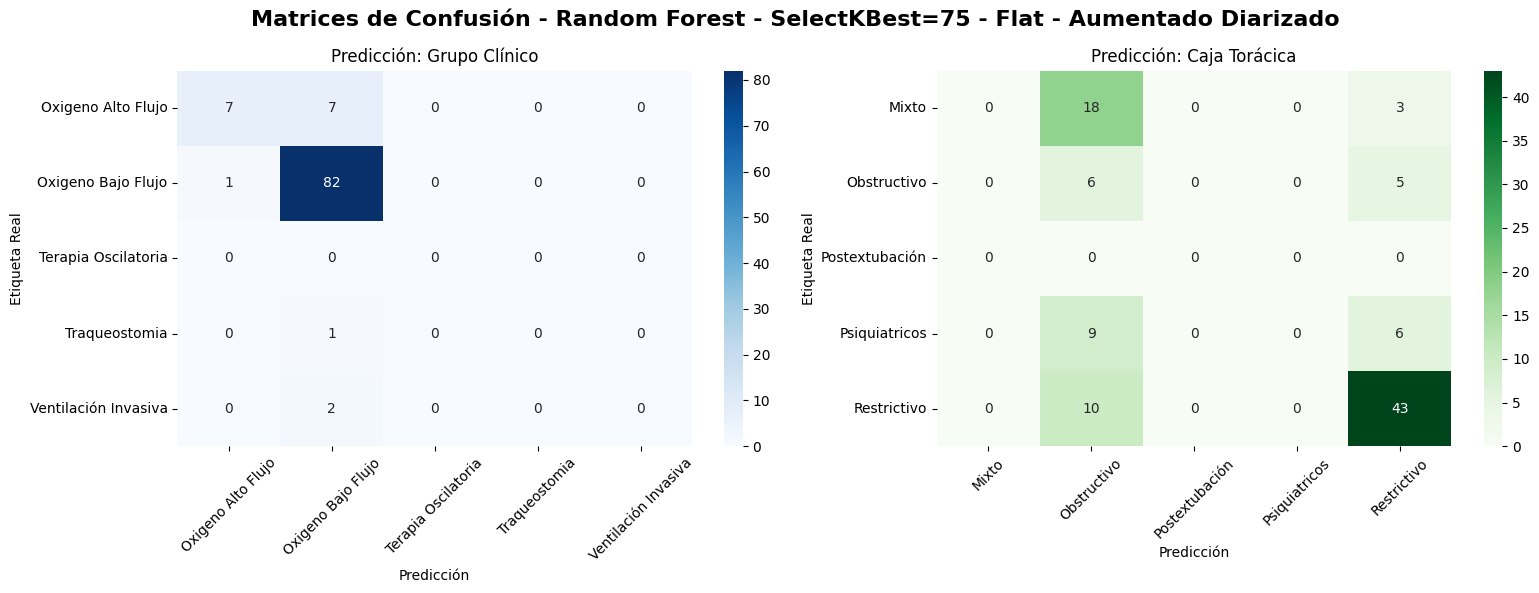

In [90]:
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 150}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 89.00% | F1-Score (Macro): 39.34%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 27.74%


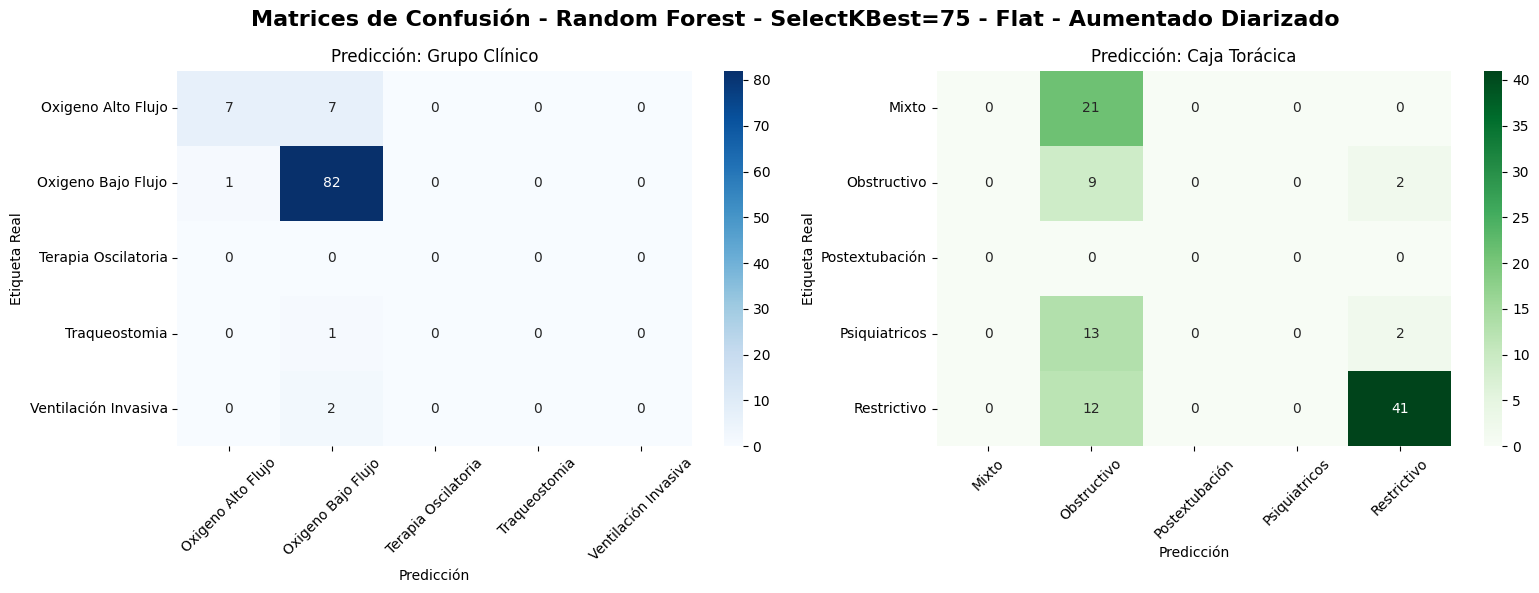

In [94]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 87.00% | F1-Score (Macro): 36.78%
CAJA TORÁCICA -> Accuracy: 48.00% | F1-Score (Macro): 24.98%


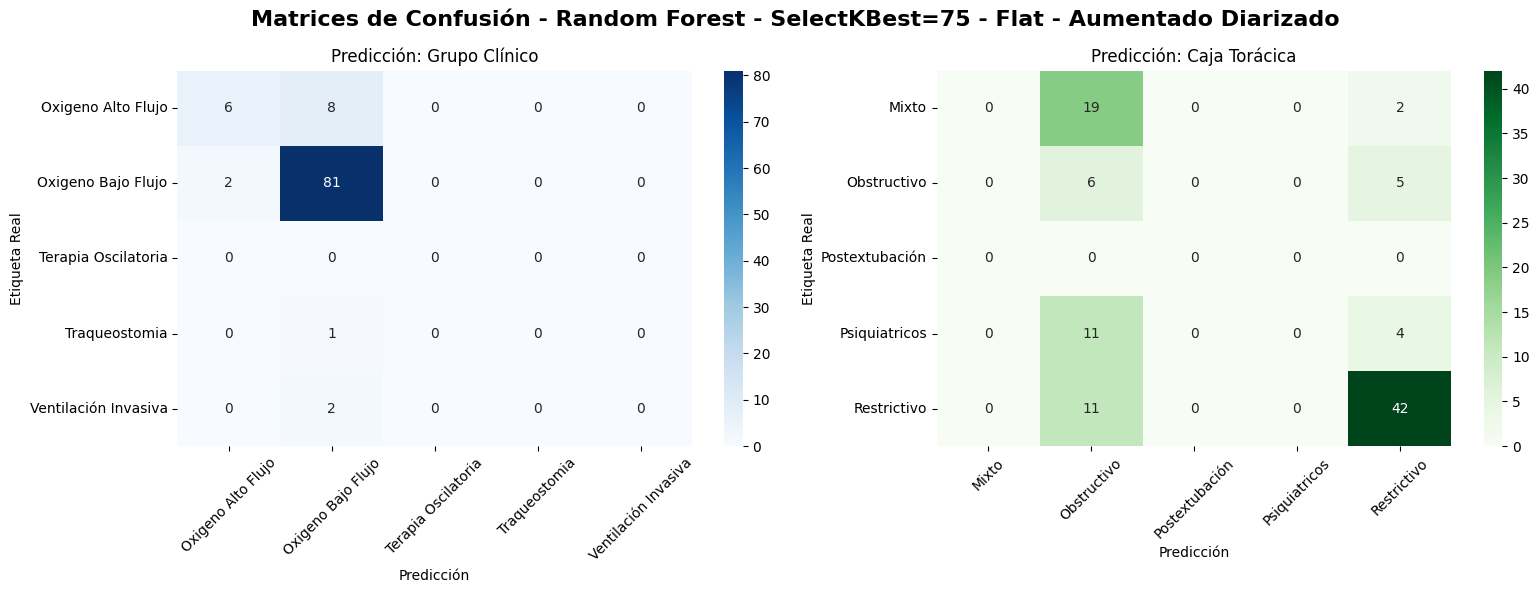

In [97]:
param_grid_rf_2_kbest_flat = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [5, 7],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparámetros para Torácica: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 89.00% | F1-Score (Macro): 39.34%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 27.74%


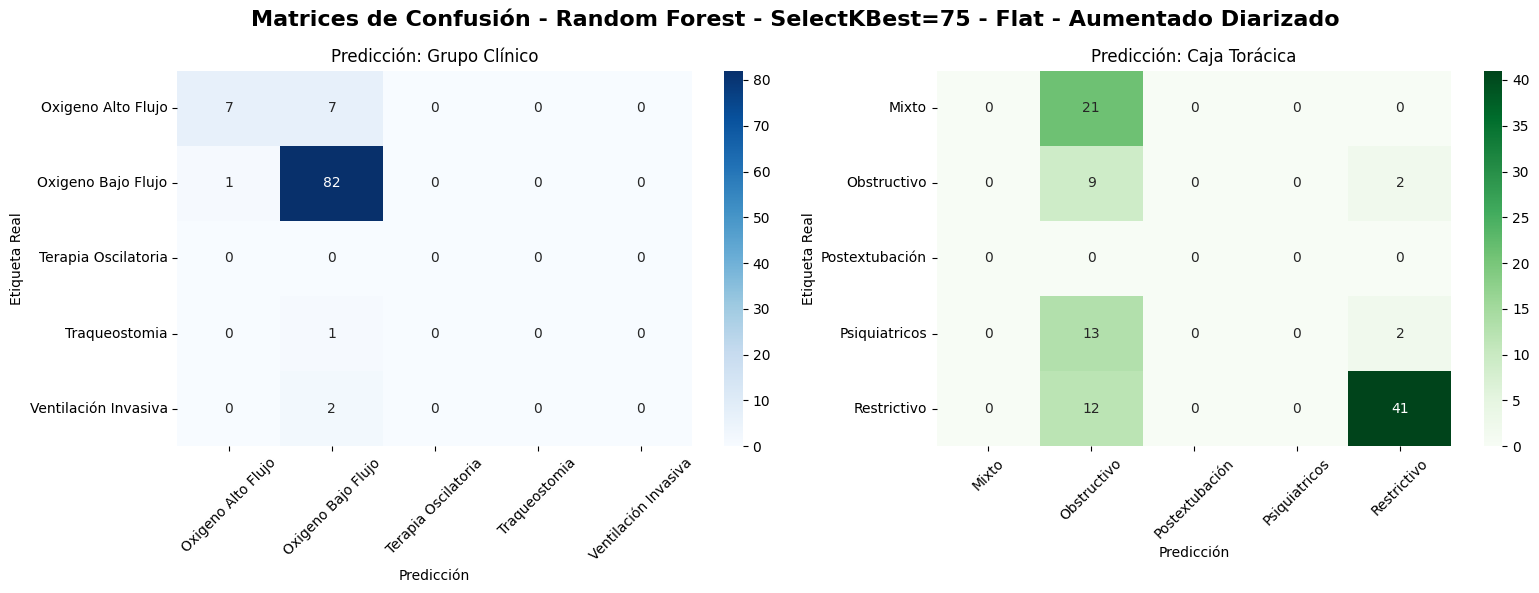

In [99]:
param_grid_rf_final_grupo_kbest_flat = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]        
}

param_grid_rf_final_caja_kbest_flat = {
    'n_estimators': [100],      
    'max_depth': [10],        
    'min_samples_split': [2],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]          
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_rf_grupo, 
        grid_caja=grid_rf_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="Random Forest - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

#### SVM

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 65.00% | F1-Score (Macro): 24.22%
CAJA TORÁCICA -> Accuracy: 44.00% | F1-Score (Macro): 24.51%


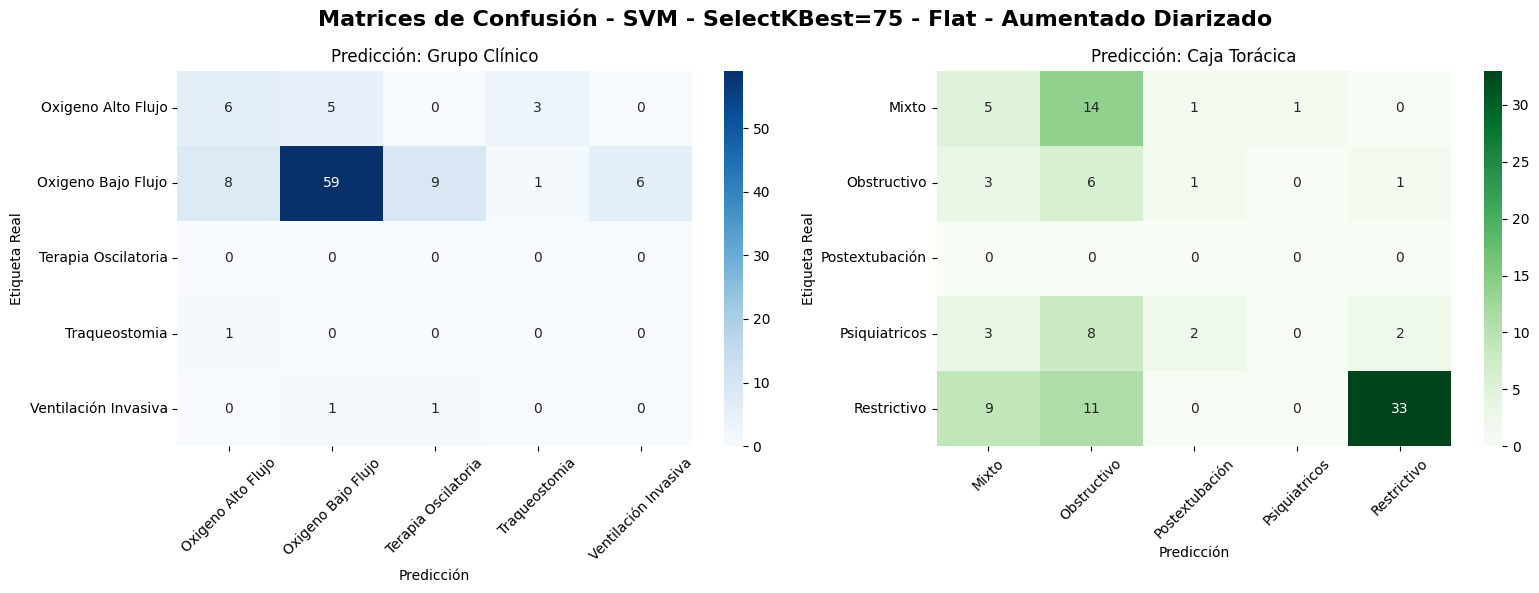

In [101]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.00% | F1-Score (Macro): 25.47%
CAJA TORÁCICA -> Accuracy: 46.00% | F1-Score (Macro): 31.68%


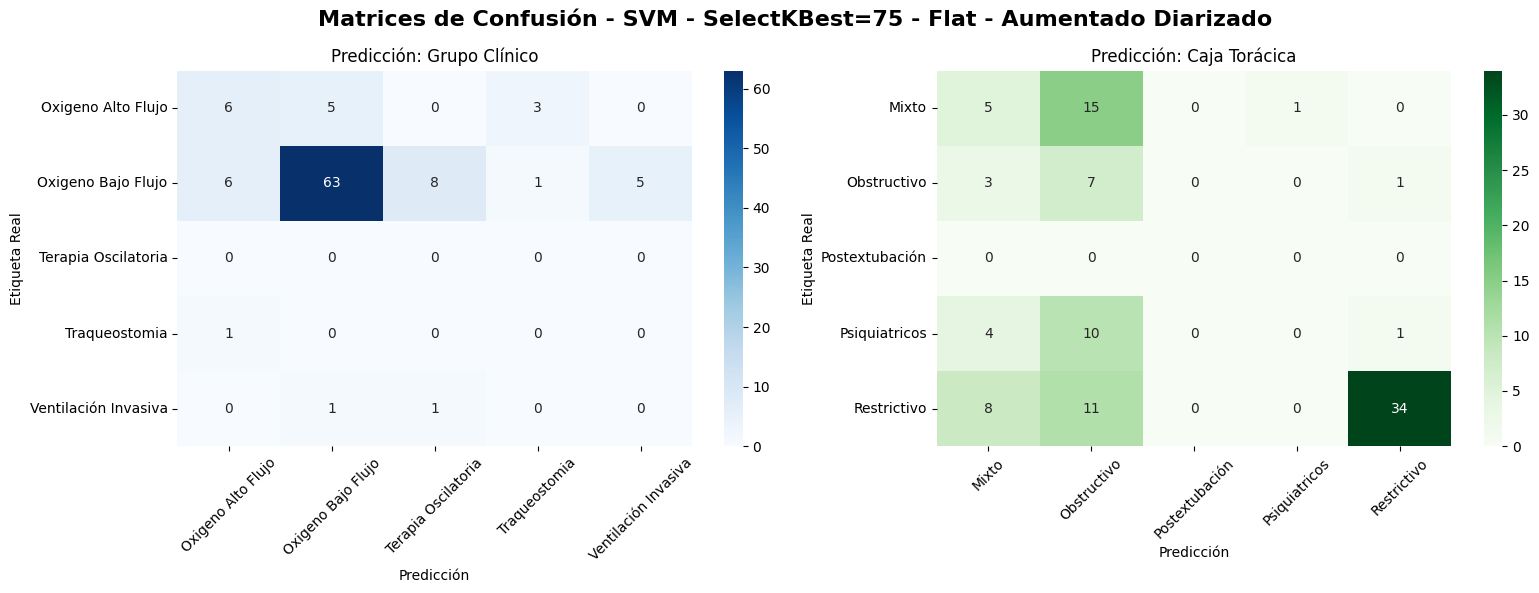

In [102]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 70.00% | F1-Score (Macro): 25.91%
CAJA TORÁCICA -> Accuracy: 50.00% | F1-Score (Macro): 34.99%


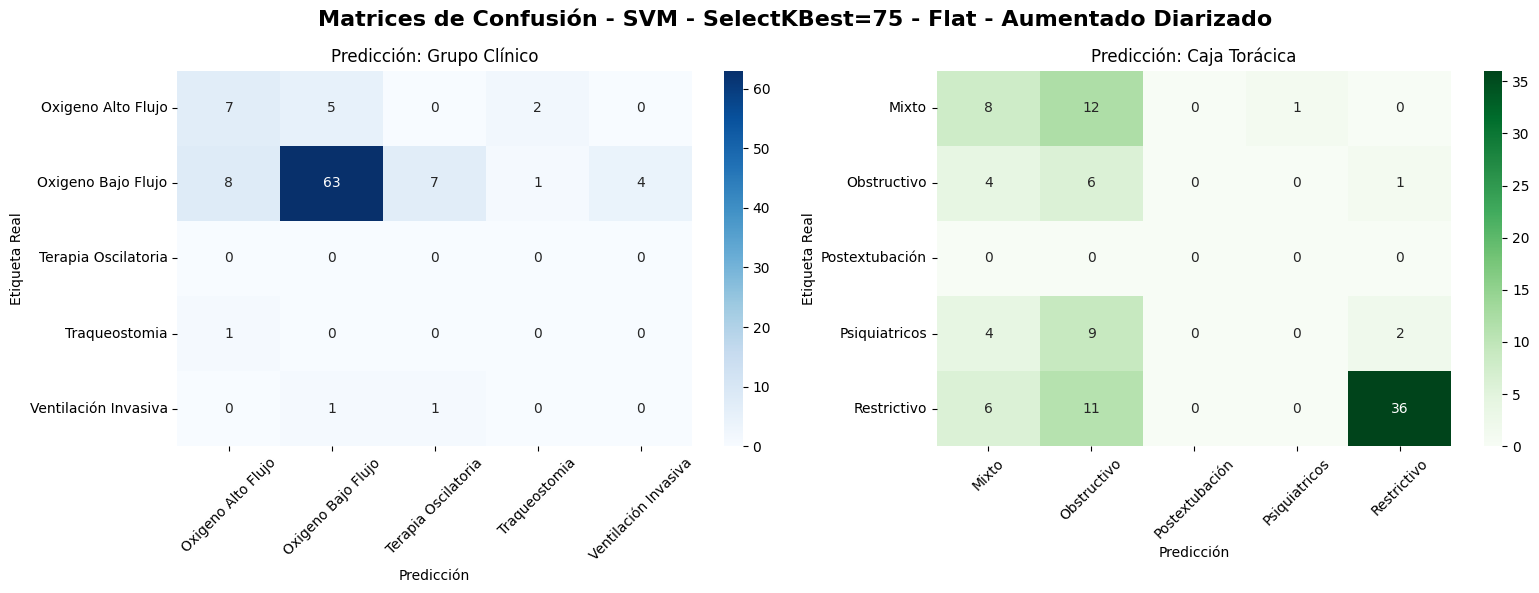

In [106]:
param_grid_svm_2_kbest_flat = {
    'C': [1.0, 2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}
with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 69.00% | F1-Score (Macro): 25.46%
CAJA TORÁCICA -> Accuracy: 52.00% | F1-Score (Macro): 36.56%


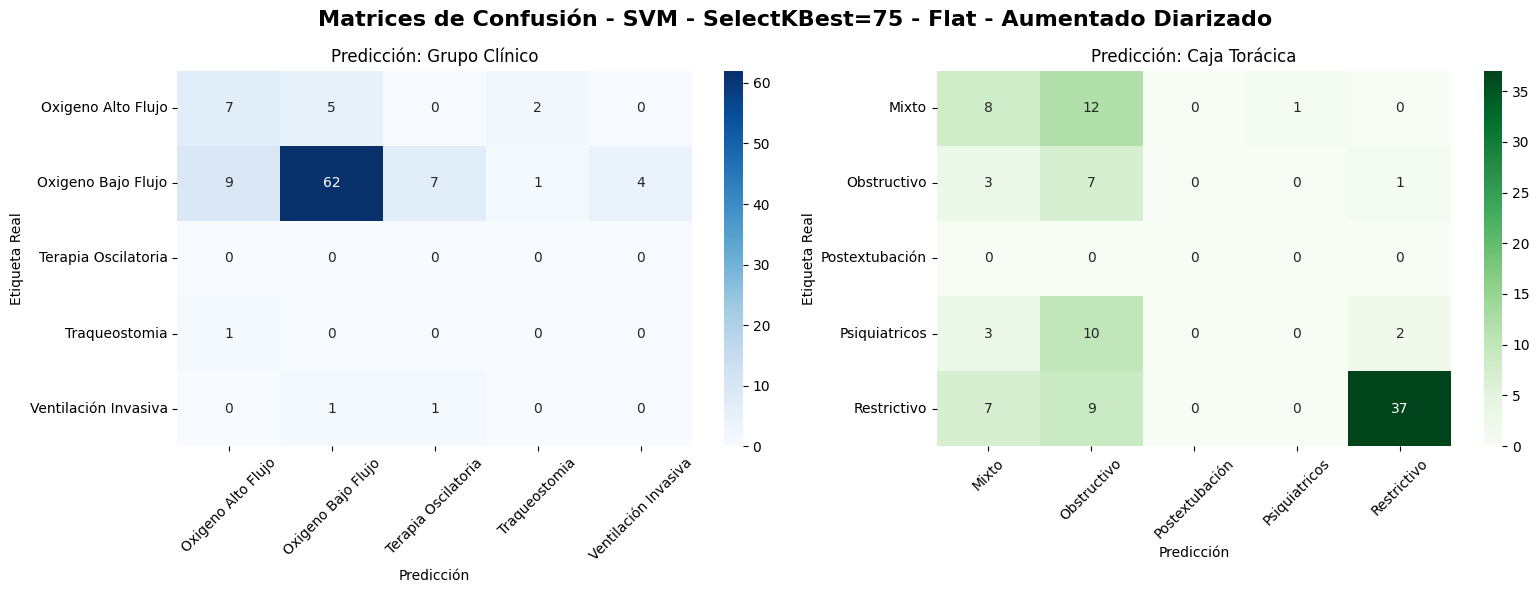

In [108]:
param_grid_svm_3_kbest_flat = {
    'C': [2.0, 2.5, 3.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_3_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_3_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'C': 2.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparámetros para Torácica: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 70.00% | F1-Score (Macro): 25.91%
CAJA TORÁCICA -> Accuracy: 52.00% | F1-Score (Macro): 36.56%


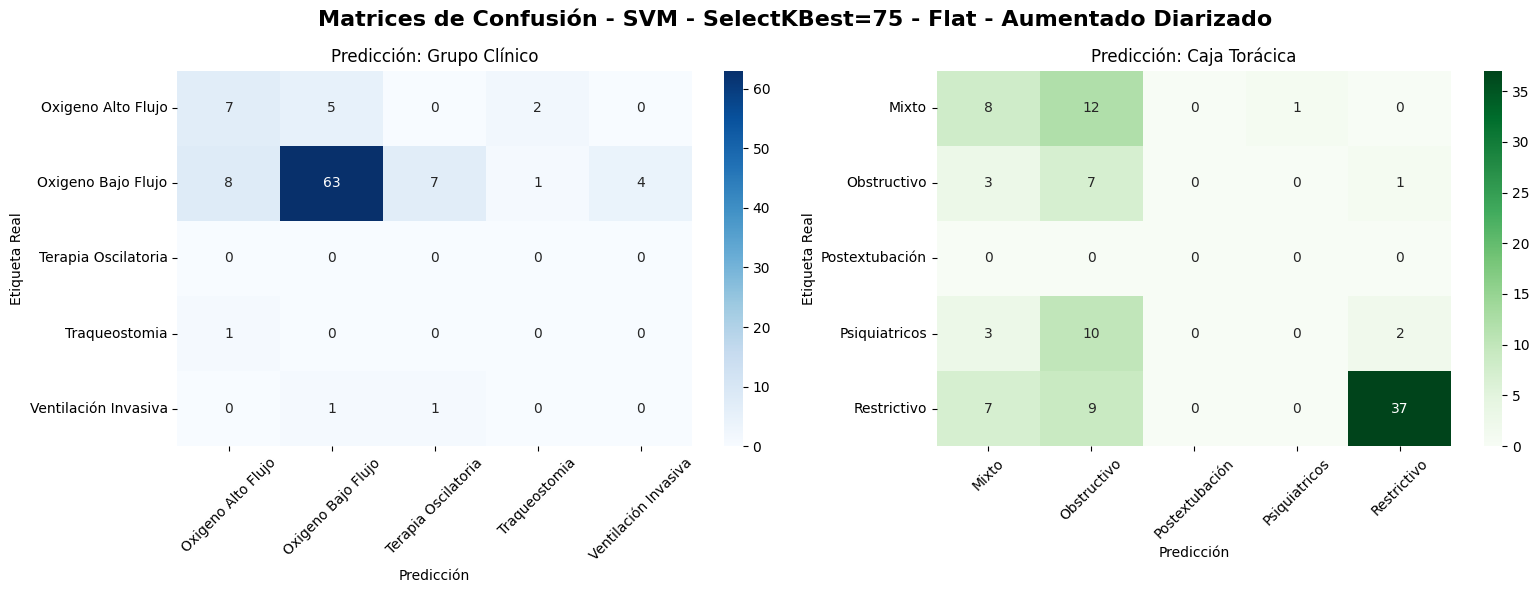

In [110]:
param_grid_svm_final_grupo_kbest_flat = {
    'C': [2.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

param_grid_svm_final_caja_kbest_flat = {
    'C': [2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_svm_grupo, 
        grid_caja=grid_svm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="SVM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

#### LightGBM

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 86.00% | F1-Score (Macro): 36.97%
CAJA TORÁCICA -> Accuracy: 51.00% | F1-Score (Macro): 29.14%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


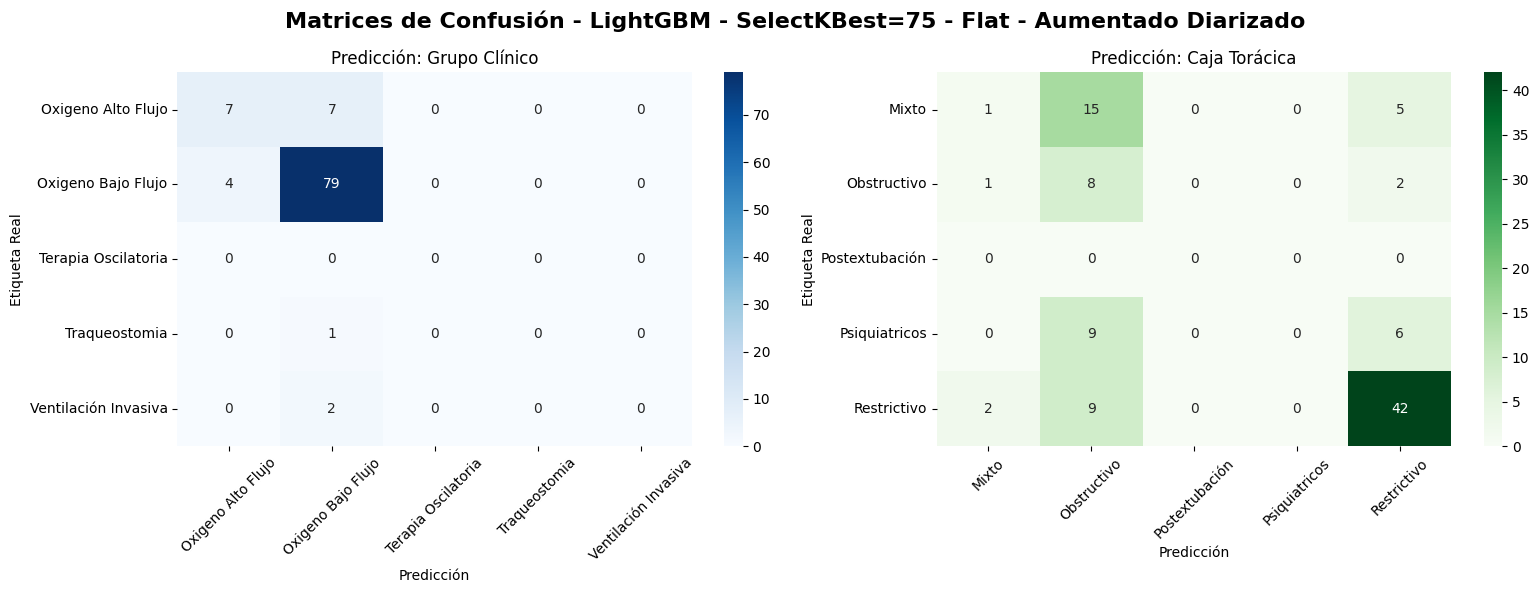

In [113]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 63}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
GRUPOS -> Accuracy: 82.00% | F1-Score (Macro): 26.88%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 26.53%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


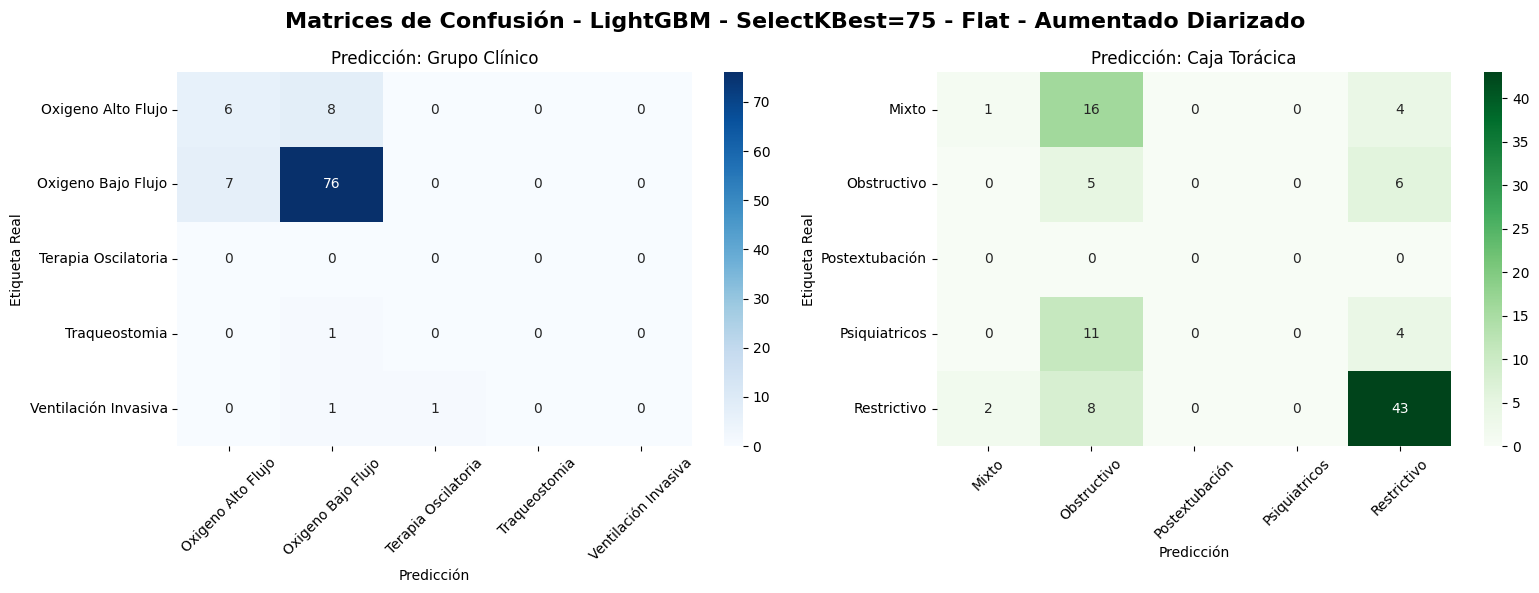

In [114]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 63}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 31}
GRUPOS -> Accuracy: 87.00% | F1-Score (Macro): 37.70%
CAJA TORÁCICA -> Accuracy: 51.00% | F1-Score (Macro): 29.12%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


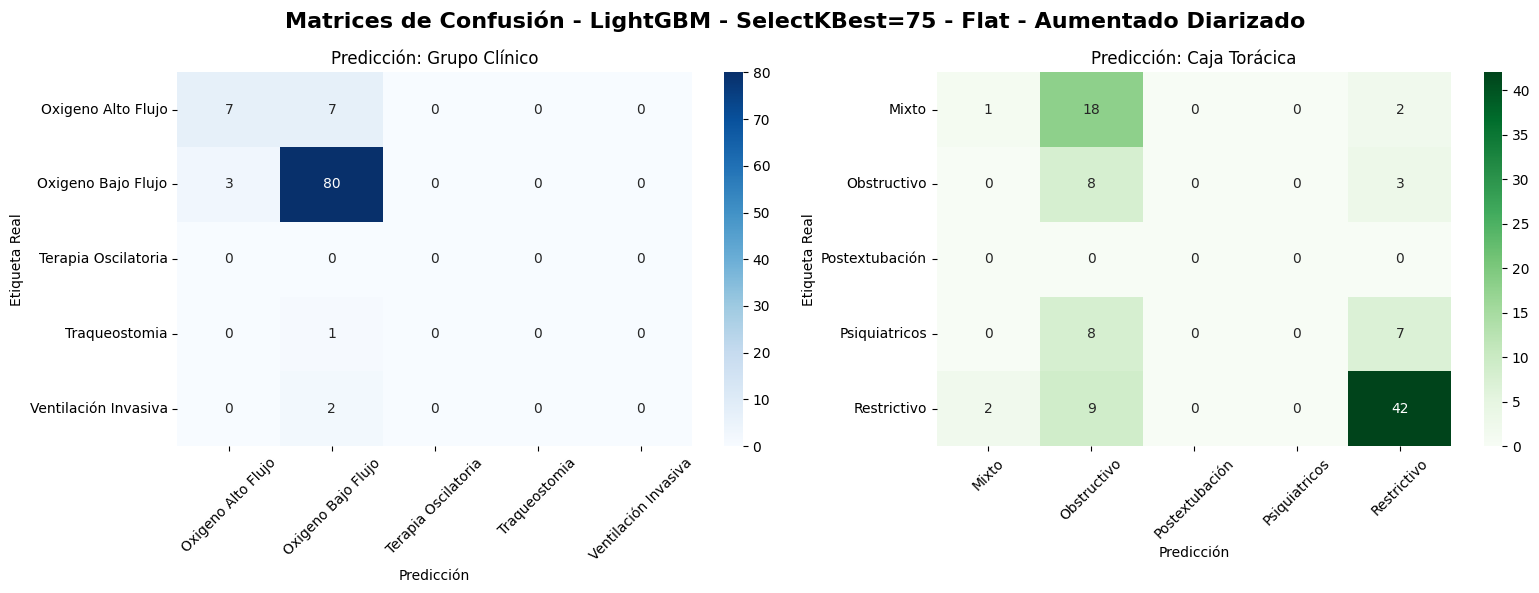

In [118]:
param_grid_lgbm_2_grupo_kbest_flat = {
    'n_estimators': [100, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31, 63],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_2_caja_kbest_flat = {
    'n_estimators': [100, 200],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 63}
Mejores Hiperparámetros para Torácica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 87.00% | F1-Score (Macro): 37.70%
CAJA TORÁCICA -> Accuracy: 51.00% | F1-Score (Macro): 29.14%


C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


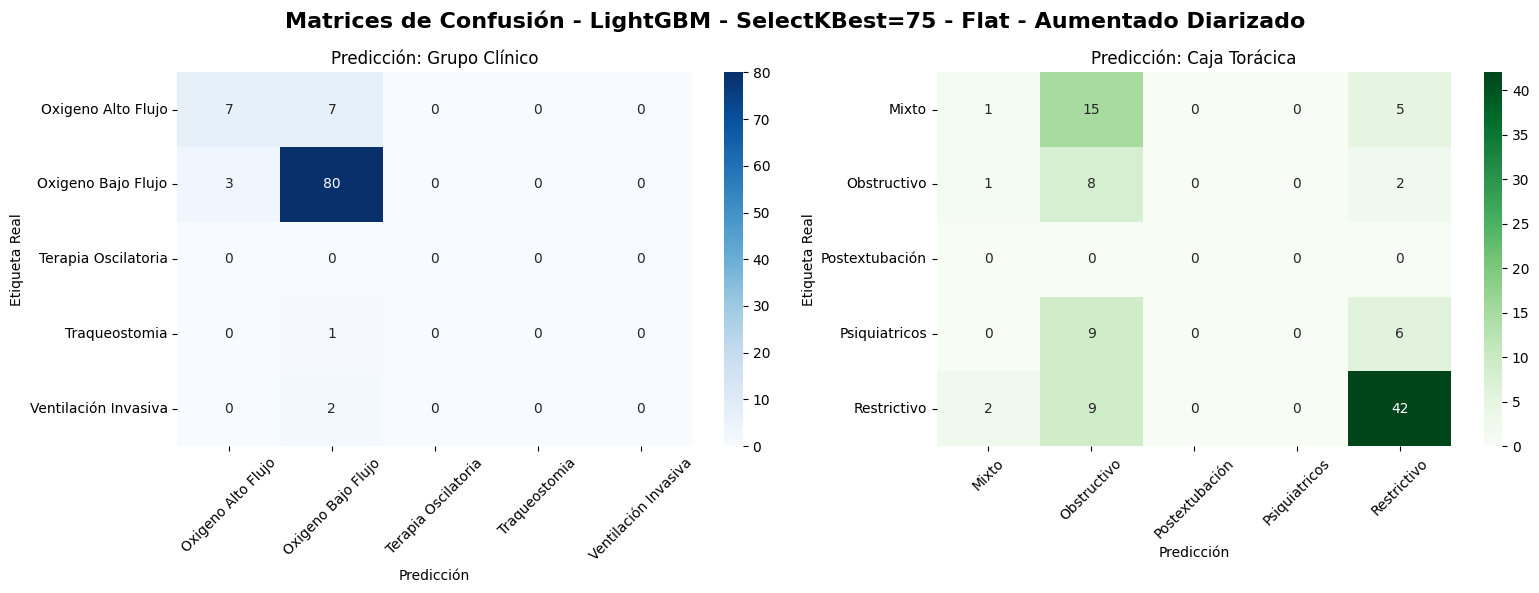

In [120]:
param_grid_lgbm_grupo_final_kbest_flat = {
    'n_estimators': [300],
    'learning_rate': [0.15],
    'num_leaves': [63],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_caja_final_kbest_flat = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_flat_Kbest_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_grupo_final_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_caja_final_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_caja_selected, y_train_caja)
    
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_lgbm_grupo, 
        grid_caja=grid_lgbm_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="LightGBM - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

##### KNN

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 79.00% | F1-Score (Macro): 23.23%
CAJA TORÁCICA -> Accuracy: 43.00% | F1-Score (Macro): 27.24%


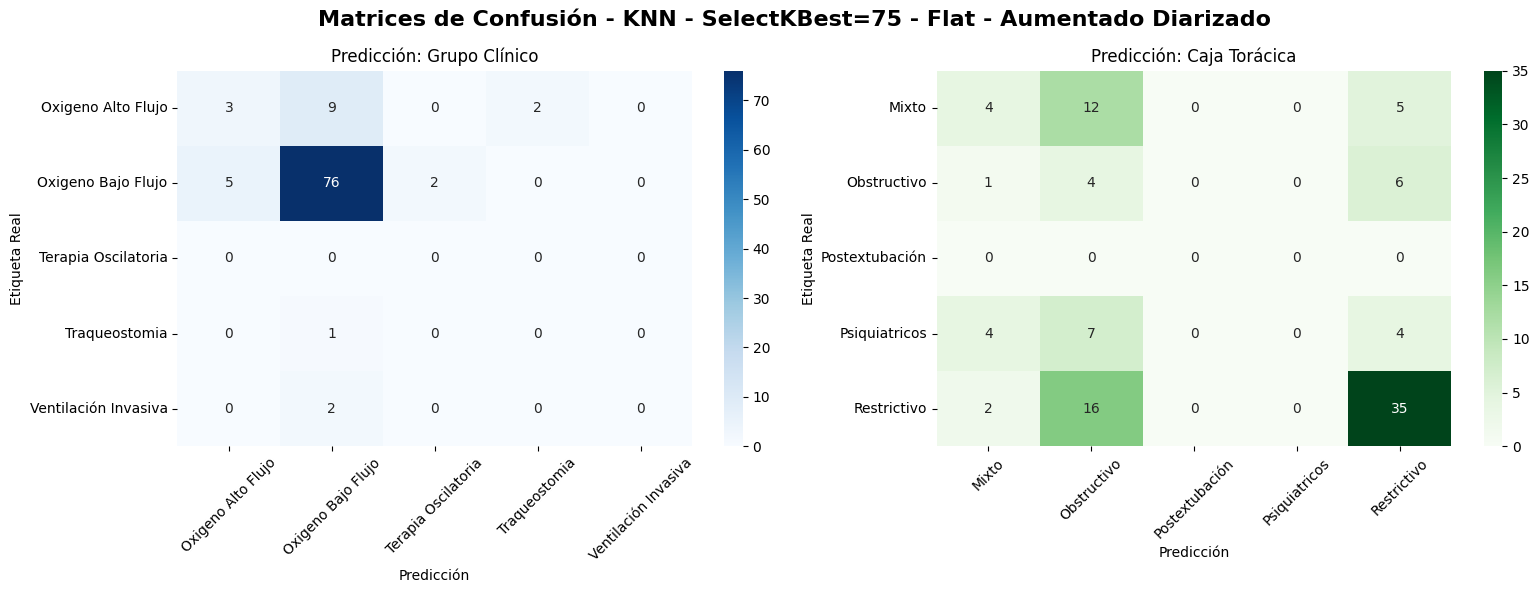

In [122]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_caja_selected, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.21376632 0.21674223 0.23039767 0.19620604 0.2836795  0.22365192
        nan 0.20278026        nan 0.2013446         nan 0.2586016
 0.22648286 0.21428147 0.26572938 0.25189042 0.24497002 0.2314468 ]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.28126661 0.23953091 0.26103121 0.26829008 0.29617823 0.29681712
        nan 0.22070848        nan 0.26667694        nan 0.2997094
 0.21524967 0.21519528 0.23229015 0.22305823 0.28881097 0.26851809]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'distance'}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 31.92%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 26.92%


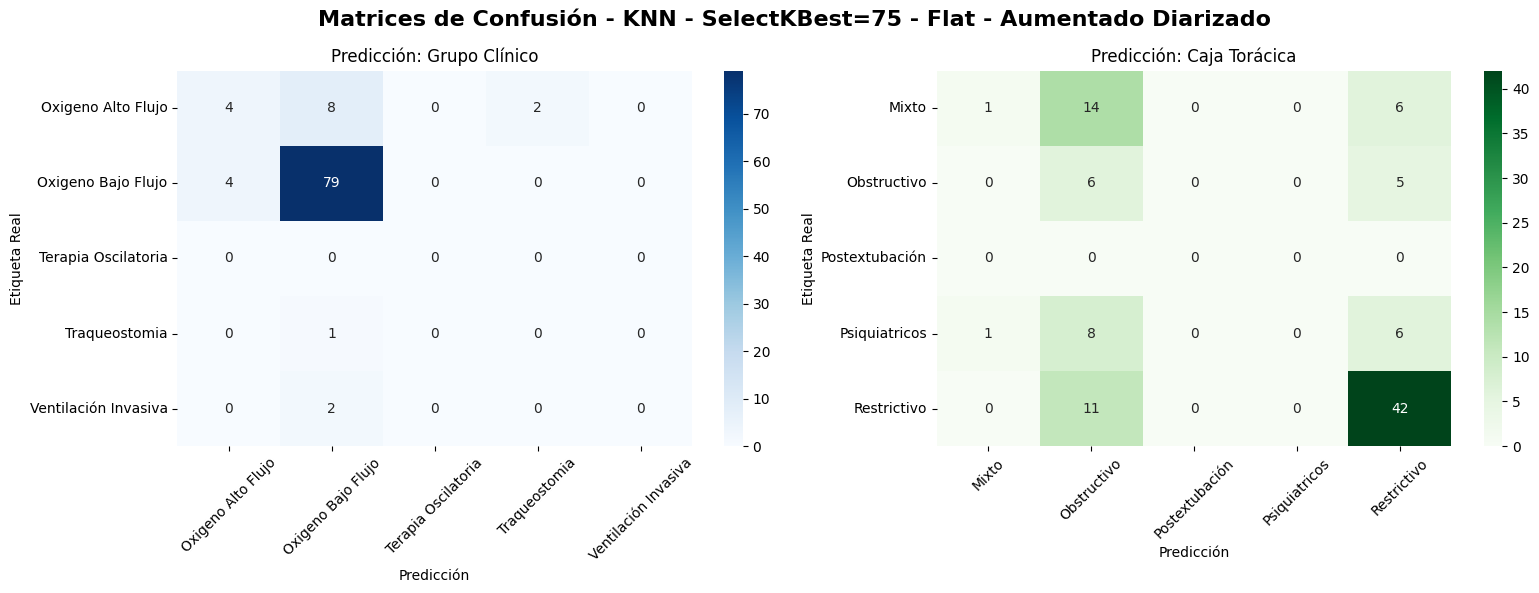

In [123]:
param_grid_knn_1 = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_caja_selected, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan 0.20278026 0.21376632 0.21674223        nan 0.21114518
        nan 0.2013446  0.23039767 0.19620604        nan 0.23190016
        nan 0.2586016  0.2836795  0.22365192        nan 0.24049594]
  warnings.warn(
C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [       nan 0.22070848 0.28126661 0.23953091        nan 0.22735383
        nan 0.26667694 0.26103121 0.26829008        nan 0.2367501
        nan 0.2997094  0.29617823 0.29681712        nan 0.29605687]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 31.92%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 26.92%


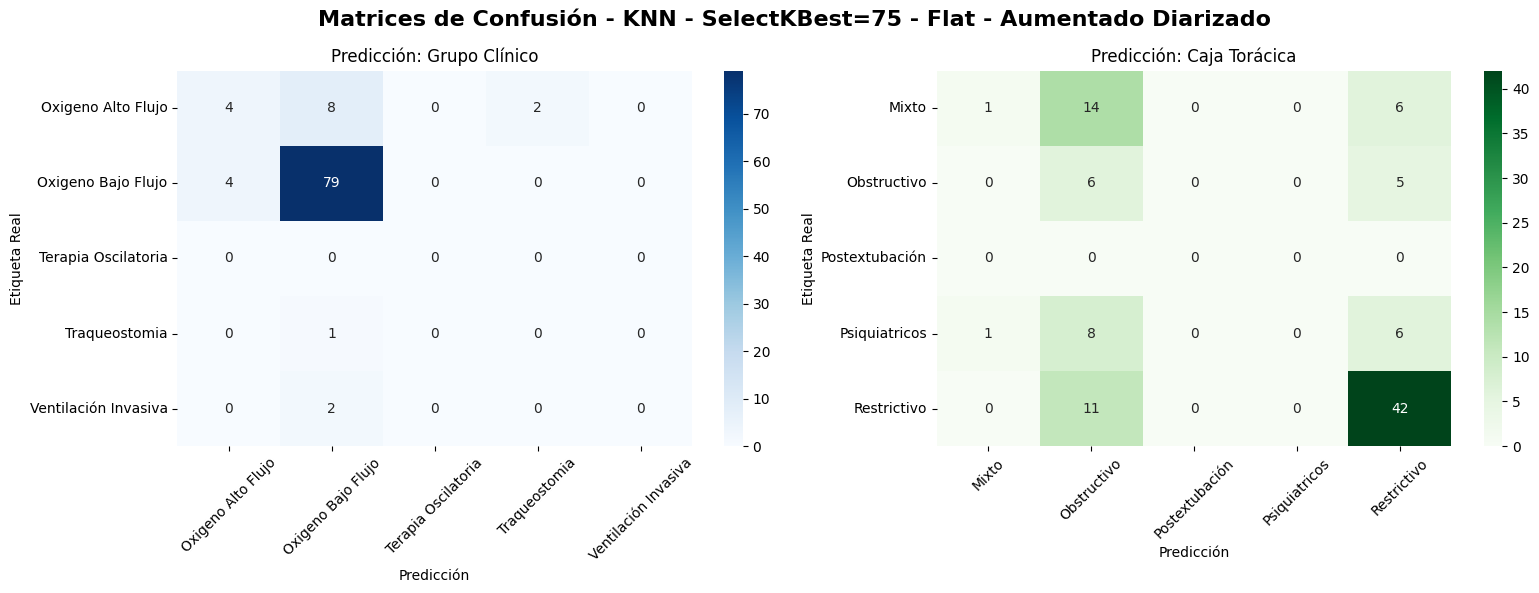

In [127]:
param_grid_knn_2_minkowski = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune2_minkowski"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_caja_selected, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

C:\Users\pedro\anaconda3\envs\env_audio\lib\site-packages\sklearn\model_selection\_search.py:1135: UserWarning: One or more of the test scores are non-finite: [0.2836795  0.30291006 0.31096103        nan        nan        nan
 0.24497002 0.2799569  0.27829067]
  warnings.warn(


Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 13, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 82.00% | F1-Score (Macro): 32.40%
CAJA TORÁCICA -> Accuracy: 43.00% | F1-Score (Macro): 27.24%


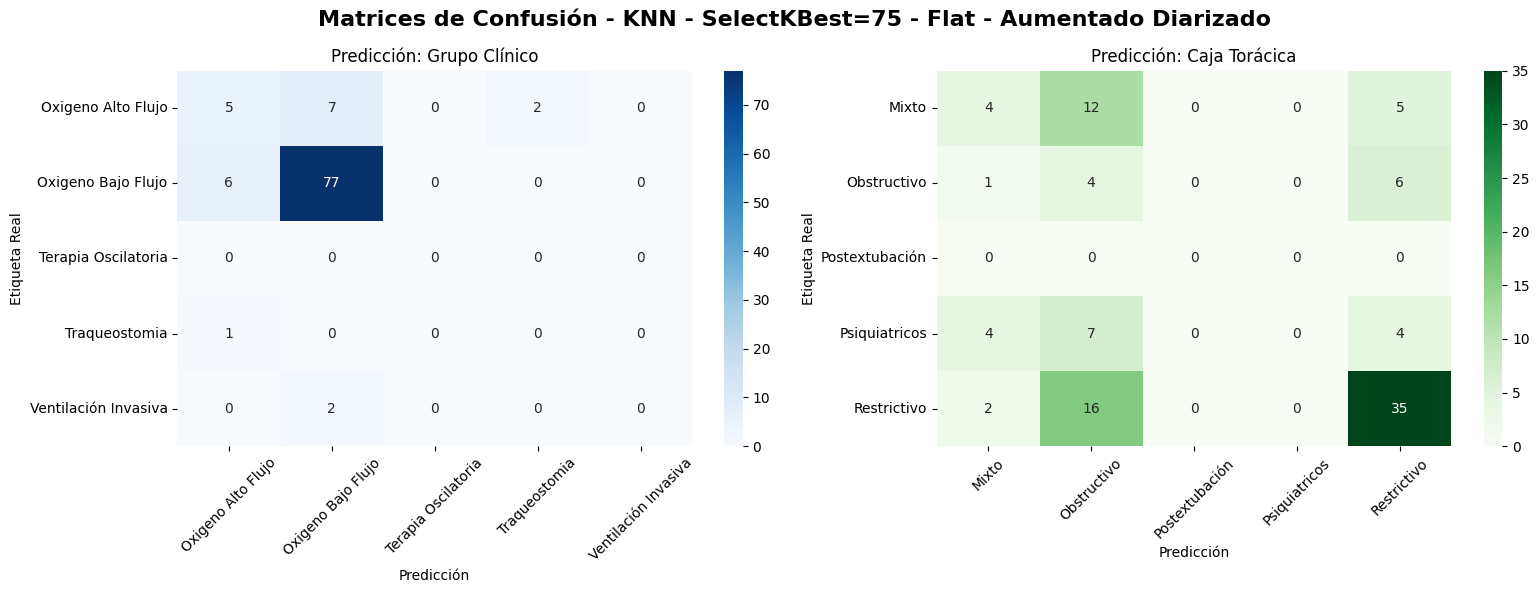

In [129]:
param_grid_knn_3_grupo_kbest_flat = {
    'n_neighbors': [9, 11, 13],   
    'weights': ['uniform'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

param_grid_knn_3_caja_kbest_flat = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_3_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_caja_selected, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

Mejores Hiperparámetros para Grupo Clínico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparámetros para Torácica: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'distance'}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 31.92%
CAJA TORÁCICA -> Accuracy: 49.00% | F1-Score (Macro): 26.92%


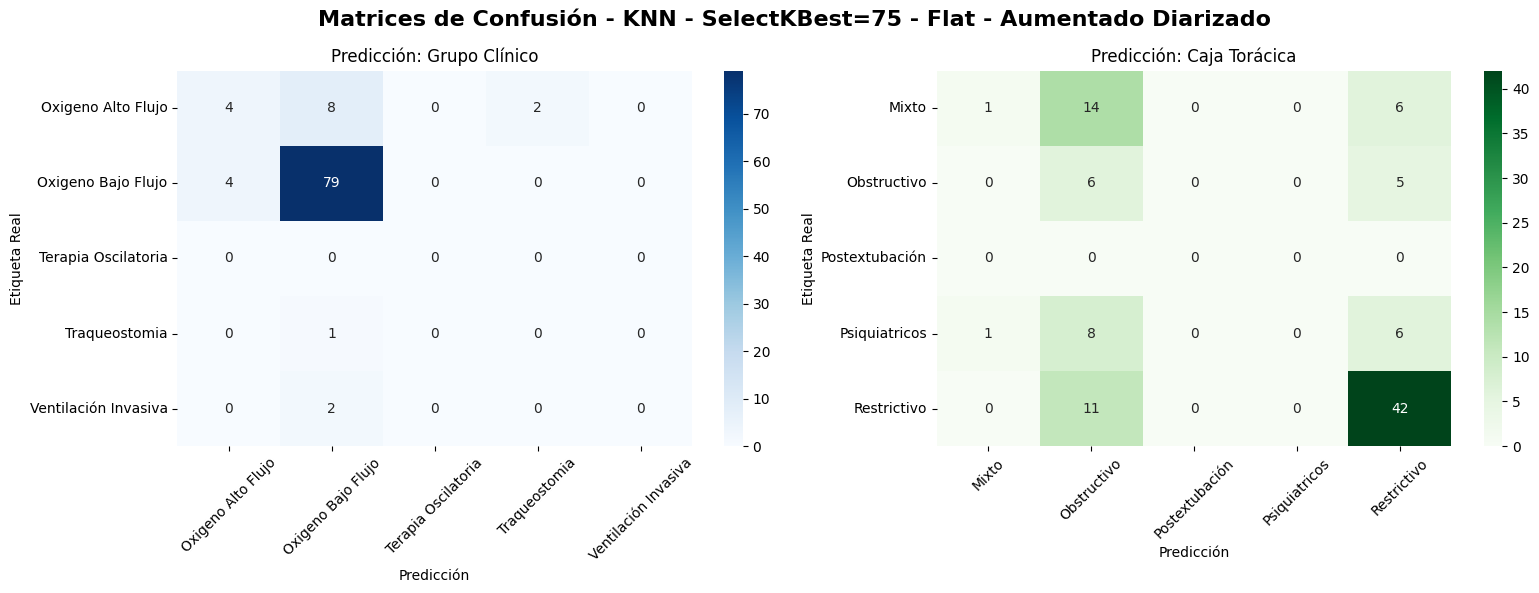

In [135]:
param_grid_knn_final_grupo_kbest_flat = {
    'n_neighbors': [9],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

param_grid_knn_final_caja_kbest_flat = {
    'n_neighbors': [9],       
    'weights': ['distance'],   
    'algorithm': ['auto'],    
    'p': [1]                 
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_flat_Kbest_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_flat") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Kbest")
    
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_final_grupo_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_grupo_selected, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final_caja_kbest_flat, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_caja_selected, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_kbest_flat(
        grid_grupo=grid_knn_grupo, 
        grid_caja=grid_knn_caja, 
        X_test_grupo=X_test_grupo_selected,
        X_test_caja=X_test_caja_selected,   
        nombre_modelo="KNN - SelectKBest=75 - Flat - Aumentado Diarizado"
    )

### Extracción Características + Modelos DF_POOL

En este caso, nos encontramos con un menos numero de componentes, por lo que simplemente podemos aplicar una reducción de características basándonos en matrices y mapas de correlación, eliminando aquellos datos que no aporten varianza al sistema, debido a que estén extremadamente correlacionados entre ellos. 

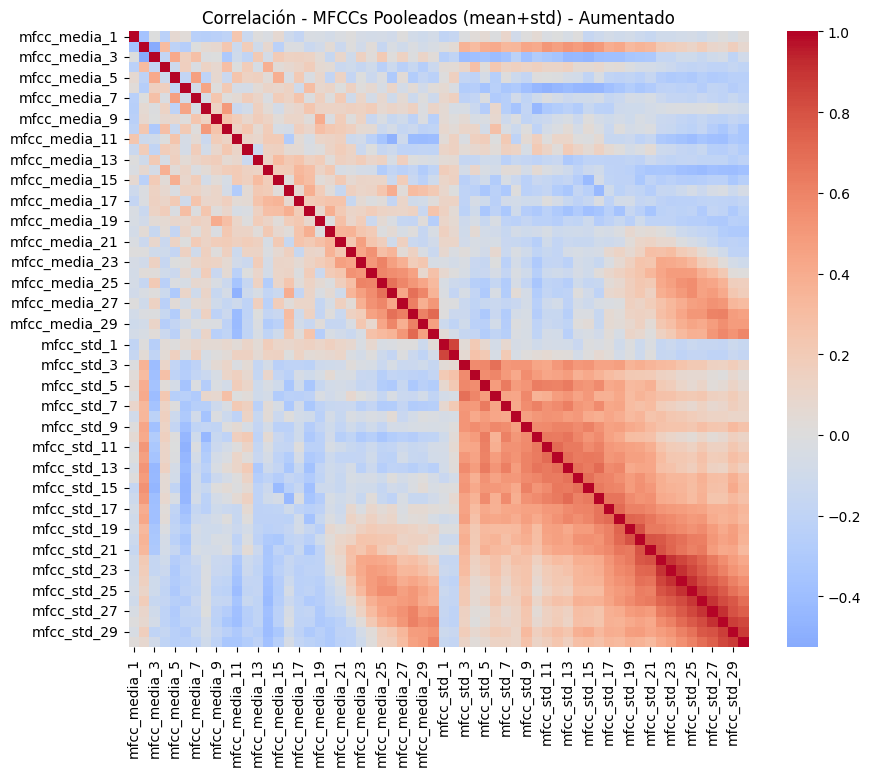

In [138]:
columnas_a_quitar = ['nombre_archivo', 'grupo', 'caja_toracica', 'fold']

X_train = df_train_pool.drop(columns=columnas_a_quitar)

corr_matrix = X_train.corr()

def plot_corr(df, title):
    plt.figure(figsize=(10, 8))
    sns.heatmap(df.corr(), cmap='coolwarm', center=0)
    plt.title(f"Correlación - {title}")
    plt.show()

plot_corr(X_train, "MFCCs Pooleados (mean+std) - Aumentado")

Con esto podemos observar que no hay muchos componentes que estén correlacionados entre sí, excepto por los últimos valores de desviación estándar, los cuales presentan una mayor correlación positiva entre sí. 

En el caso de que observemos valores de correlación elevados entre features, podremos simplemente eliminarlos, ya que aportan información redundante. Si reducimos la dimensionalidad, nuestro modelo se protegerá del sobreaprendizaje y el entrenamiento no será tan costoso.

In [141]:
#Vamos a comprobar la correlación de todas las columnas mfcc_std, y ver si alguna supera cierto umbral
#Este umbral será del 80%, simplemente lo establecemos para ver si alguna de las características supera al menos el 80% de correlación.
columnas_correlacionadas = [f'mfcc_std_{i}' for i in range(1, 31)]
X_correlacionado = X_train[columnas_correlacionadas]

umbral = 0.8
matriz_corr_sub = X_correlacionado.corr()
for i in range(len(matriz_corr_sub.columns)):
    for j in range(i):
        col1 = matriz_corr_sub.columns[i]
        col2 = matriz_corr_sub.columns[j]
        correlacion = matriz_corr_sub.iloc[i, j]
        if(correlacion >= umbral):
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")

mfcc_std_2 y mfcc_std_1 -> Correlación: 0.851
mfcc_std_22 y mfcc_std_21 -> Correlación: 0.801
mfcc_std_23 y mfcc_std_22 -> Correlación: 0.901
mfcc_std_24 y mfcc_std_22 -> Correlación: 0.844
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.910
mfcc_std_25 y mfcc_std_23 -> Correlación: 0.837
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.910
mfcc_std_26 y mfcc_std_24 -> Correlación: 0.824
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.893
mfcc_std_27 y mfcc_std_25 -> Correlación: 0.835
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.903
mfcc_std_28 y mfcc_std_26 -> Correlación: 0.819
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.908
mfcc_std_29 y mfcc_std_27 -> Correlación: 0.800
mfcc_std_29 y mfcc_std_28 -> Correlación: 0.865
mfcc_std_30 y mfcc_std_28 -> Correlación: 0.835
mfcc_std_30 y mfcc_std_29 -> Correlación: 0.876


Con esto podemos ver que hay muchas características que tienen mas del 80% de correlación, sin embargo, muy pocas son las que superan el 85% y solo una pareja supera el 90%.
En este caso, vamos a eliminar aquellas características que superen el 88% de correlación, tratandose de un valor elevado que nos permite reducir la redundancia entre características altamente correlacionadas sin perder información relevante. De este modo, mantenemos la mayor parte de la varianza del espacio original mientras eliminamos únicamente aquellos pares de características que aportan información prácticamente idéntica al modelo.

In [144]:
umbral = 0.88
pares_a_eliminar = set()

matriz_correlacion = X_train.corr()
for i in range(len(matriz_correlacion.columns)):
    for j in range(i):
        if abs(matriz_correlacion.iloc[i, j]) > umbral:
            col1 = matriz_correlacion.columns[i]
            col2 = matriz_correlacion.columns[j]
            correlacion = matriz_correlacion.iloc[i, j]
            print(f"{col1} y {col2} -> Correlación: {correlacion:.3f}")
            
            pares_a_eliminar.add(col1)

print("Columnas a eliminar: ")
print(f"{list(pares_a_eliminar)}. Número total = {len(pares_a_eliminar)}")

#Las eliminamos:
X_pool_reducido_train = df_train_pool.drop(columns = pares_a_eliminar)
X_pool_reducido_test = df_test_pool.drop(columns = pares_a_eliminar)

mfcc_std_23 y mfcc_std_22 -> Correlación: 0.901
mfcc_std_24 y mfcc_std_23 -> Correlación: 0.910
mfcc_std_25 y mfcc_std_24 -> Correlación: 0.910
mfcc_std_26 y mfcc_std_25 -> Correlación: 0.893
mfcc_std_27 y mfcc_std_26 -> Correlación: 0.903
mfcc_std_28 y mfcc_std_27 -> Correlación: 0.908
Columnas a eliminar: 
['mfcc_std_24', 'mfcc_std_27', 'mfcc_std_23', 'mfcc_std_26', 'mfcc_std_28', 'mfcc_std_25']. Número total = 6


In [146]:
X_pool_reducido_train.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_29,mfcc_std_30
0,Nueva grabación 35_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,1,-395.698486,128.222229,14.744758,22.322153,-2.179193,-0.845031,...,8.078880,8.287791,8.140392,7.223805,7.031056,7.511221,7.103521,6.590380,6.290315,6.236607
1,Nueva grabación 35_chunk000_noise.wav,Oxigeno Bajo Flujo,Mixto,1,-349.473114,82.767708,32.128635,14.525670,2.841852,-2.949173,...,7.174268,7.861986,7.353000,6.952439,6.647730,7.125384,6.854292,6.645799,6.102417,6.034530
2,Nueva grabación 35_chunk000_pitch.wav,Oxigeno Bajo Flujo,Mixto,1,-418.688263,125.656860,12.638882,17.950361,-5.893126,-0.413051,...,8.742253,7.728314,7.641020,8.079556,7.727164,7.608553,6.740842,6.875745,6.573294,6.302396
3,Nueva grabación 35_chunk000_stretch.wav,Oxigeno Bajo Flujo,Mixto,1,-371.298889,112.904831,12.231077,20.831930,-1.895343,0.428420,...,7.920151,8.511979,7.504880,6.698994,6.779708,7.337951,7.273961,6.445471,6.102879,5.929830
4,Nueva grabación 35_chunk001_original.wav,Oxigeno Bajo Flujo,Mixto,1,-428.804596,153.596085,17.333927,19.624739,-11.297798,-2.113892,...,9.049518,8.386796,7.746895,7.247343,7.059947,7.692526,7.388311,7.013615,6.780173,6.246421


In [148]:
X_pool_reducido_test.head()

,nombre_archivo,grupo,caja_toracica,fold,mfcc_media_1,mfcc_media_2,mfcc_media_3,mfcc_media_4,mfcc_media_5,mfcc_media_6,...,mfcc_std_15,mfcc_std_16,mfcc_std_17,mfcc_std_18,mfcc_std_19,mfcc_std_20,mfcc_std_21,mfcc_std_22,mfcc_std_29,mfcc_std_30
0,Asma obesidad grave vni planta_chunk000_origin...,Ventilación Invasiva,Obstructivo,-1,-347.397308,152.618515,-4.039323,15.344717,-7.147772,-0.646143,...,7.605223,7.272128,7.821926,7.489320,7.761930,8.026902,7.296608,7.711050,6.994756,7.767807
1,Asma obesidad grave vni planta_chunk001_origin...,Ventilación Invasiva,Obstructivo,-1,-332.255371,150.329376,-3.941918,21.230268,2.013406,1.089561,...,7.324595,7.708858,7.714864,7.541369,7.457634,7.277525,6.670115,7.070172,6.256949,6.571935
2,Epoc como respira_chunk000_original.wav,Oxigeno Bajo Flujo,Mixto,-1,-358.504883,134.448837,0.406933,16.095858,-2.650863,-0.984964,...,8.725954,9.953770,8.566491,7.991161,7.648807,7.963410,8.086476,7.624747,9.800377,9.690172
3,Nueva grabación 76_chunk000_original.wav,Oxigeno Bajo Flujo,Obstructivo,-1,-366.050812,158.791000,-11.541698,14.499049,-0.010592,-12.866079,...,9.663743,10.773887,8.582017,8.412975,9.595258,8.443752,7.737671,7.865356,7.661285,6.637894
4,Nueva grabación 76_chunk001_original.wav,Oxigeno Bajo Flujo,Obstructivo,-1,-369.023071,180.118210,-6.522538,16.260237,-2.599717,-12.724245,...,9.664106,11.853927,9.160433,9.561089,9.515362,8.416492,7.832788,8.284888,6.356373,6.561573


En este caso, creemos que tenemos un numero bastante reducido de características con el que trabajar, por lo que pasaremos directamente al entrenamiento de modelos.

#### Entrenamiento de Modelos.

In [152]:
columnas_num = [col for col in X_pool_reducido_train.columns if 'mfcc' in col]

X_train_model = X_pool_reducido_train[columnas_num]
X_test_model = X_pool_reducido_test[columnas_num]

y_train_grupo = df_train_pool['grupo']
y_test_grupo = df_test_pool['grupo']

y_train_caja = df_train_pool['caja_toracica']
y_test_caja = df_test_pool['caja_toracica']

folds_oficiales = df_train_pool['fold'].values
ps = PredefinedSplit(test_fold=folds_oficiales)

def evaluar_modelo_pool(grid_grupo, grid_caja, nombre_modelo):    
    print(f"Mejores Hiperparámetros Grupo: {grid_grupo.best_params_}")
    print(f"Mejores Hiperparámetros Caja:  {grid_caja.best_params_}")
    idx_g = grid_grupo.best_index_
    idx_c = grid_caja.best_index_
    acc_g= grid_grupo.cv_results_['mean_test_accuracy'][idx_g]
    f1_mac_g = grid_grupo.cv_results_['mean_test_f1_macro'][idx_g]
    f1_w_g = grid_grupo.cv_results_['mean_test_f1_weighted'][idx_g]
    std_g = grid_grupo.cv_results_['std_test_f1_macro'][idx_g]
    acc_c= grid_caja.cv_results_['mean_test_accuracy'][idx_c]
    f1_mac_c = grid_caja.cv_results_['mean_test_f1_macro'][idx_c]
    f1_w_c= grid_caja.cv_results_['mean_test_f1_weighted'][idx_c]
    std_c = grid_caja.cv_results_['std_test_f1_macro'][idx_c]
    print(f"[CV] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mac_g*100:.2f}% (+/-{std_g*100:.2f}%) | F1-Weighted: {f1_w_g*100:.2f}%")
    print(f"[CV] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mac_c*100:.2f}% (+/-{std_c*100:.2f}%) | F1-Weighted: {f1_w_c*100:.2f}%")
    mlflow.log_metric("grupo_acc_cv", acc_g)
    mlflow.log_metric("grupo_f1_macro_cv", f1_mac_g)
    mlflow.log_metric("grupo_f1_weighted_cv", f1_w_g)
    mlflow.log_metric("caja_acc_cv", acc_c)
    mlflow.log_metric("caja_f1_macro_cv", f1_mac_c)
    mlflow.log_metric("caja_f1_weighted_cv",  f1_w_c)
    for key, value in grid_grupo.best_params_.items():
        mlflow.log_param(f"grupo_best_{key}", value)
    for key, value in grid_caja.best_params_.items():
        mlflow.log_param(f"caja_best_{key}", value)

Mejores Hiperparametros para Grupo Clinico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mejores Hiperparametros para Toracica: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GRUPOS -> Accuracy: 86.00% | F1-Score (Macro): 38.43%
CAJA TORACICA -> Accuracy: 49.00% | F1-Score (Macro): 26.30%


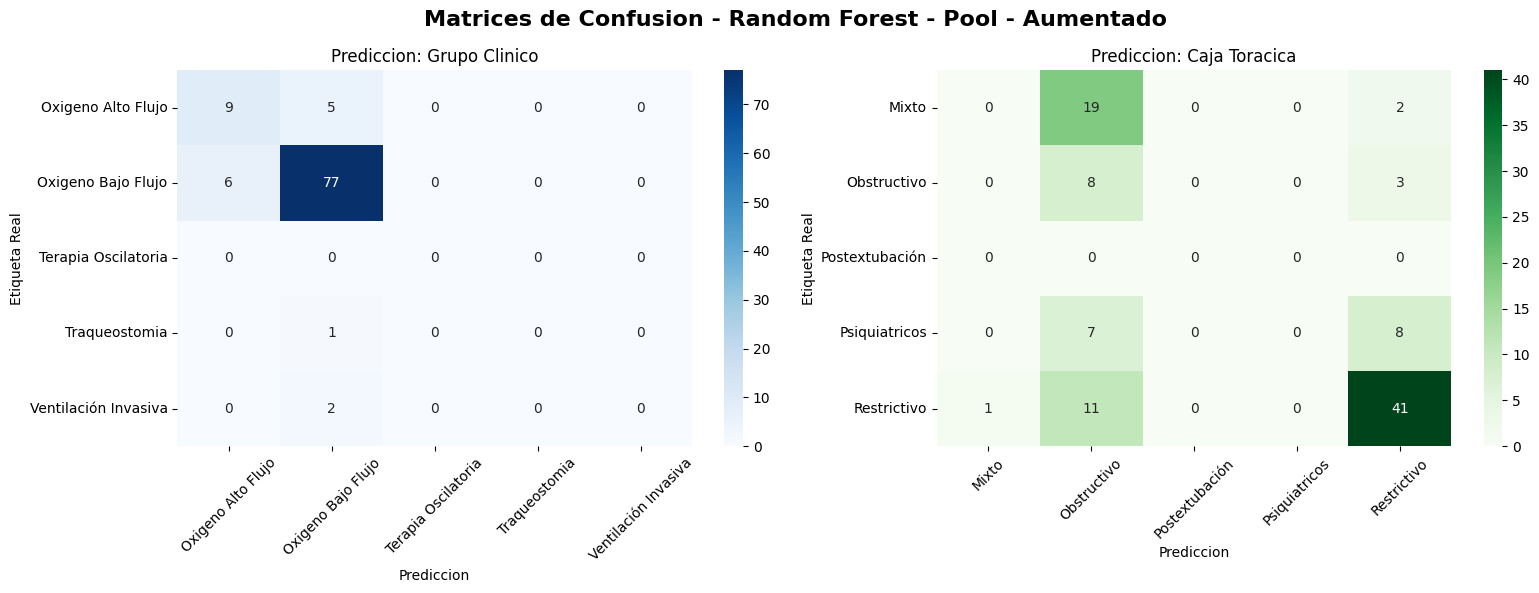

In [154]:
#Comenzamos con RF: comenzaremos utilizando sus hiperparámetros de base:
#https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
param_grid_rf = {
    'n_estimators': [100],      
    'max_depth': [None],        
    'min_samples_split': [2],   
    'min_samples_leaf': [1],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 150}
Mejores Hiperparametros para Toracica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 85.00% | F1-Score (Macro): 38.02%
CAJA TORACICA -> Accuracy: 52.00% | F1-Score (Macro): 29.95%


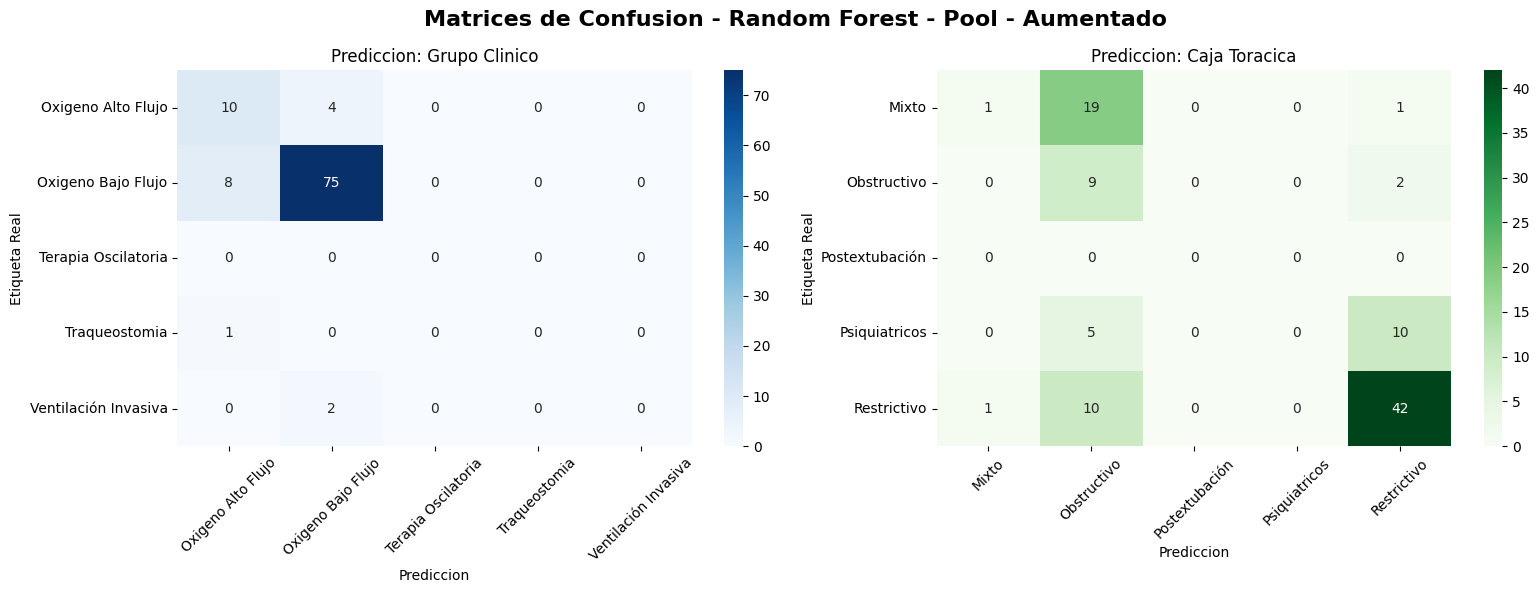

In [155]:
param_grid_rf_1 = {
    'n_estimators': [100, 150],      
    'max_depth': [None, 10, 20],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [1, 2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejores Hiperparametros para Toracica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 88.00% | F1-Score (Macro): 39.44%
CAJA TORACICA -> Accuracy: 52.00% | F1-Score (Macro): 29.95%


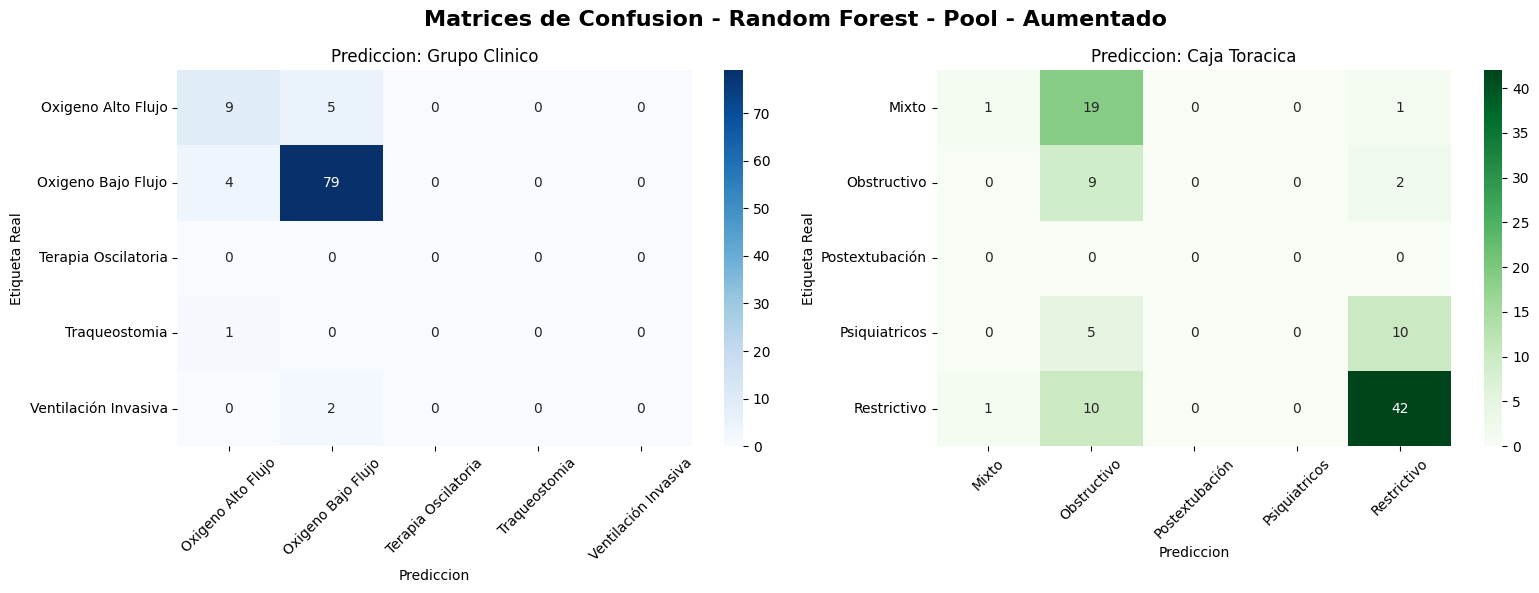

In [160]:
param_grid_rf_grupo_2 = {
    'n_estimators': [100, 200],      
    'max_depth': [None],        
    'min_samples_split': [2, 5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_caja_2 = {
    'n_estimators': [100, 200],      
    'max_depth': [10, 20],        
    'min_samples_split': [5],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_grupo_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_caja_2, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}
Mejores Hiperparametros para Toracica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 85.00% | F1-Score (Macro): 38.35%
CAJA TORACICA -> Accuracy: 52.00% | F1-Score (Macro): 29.95%


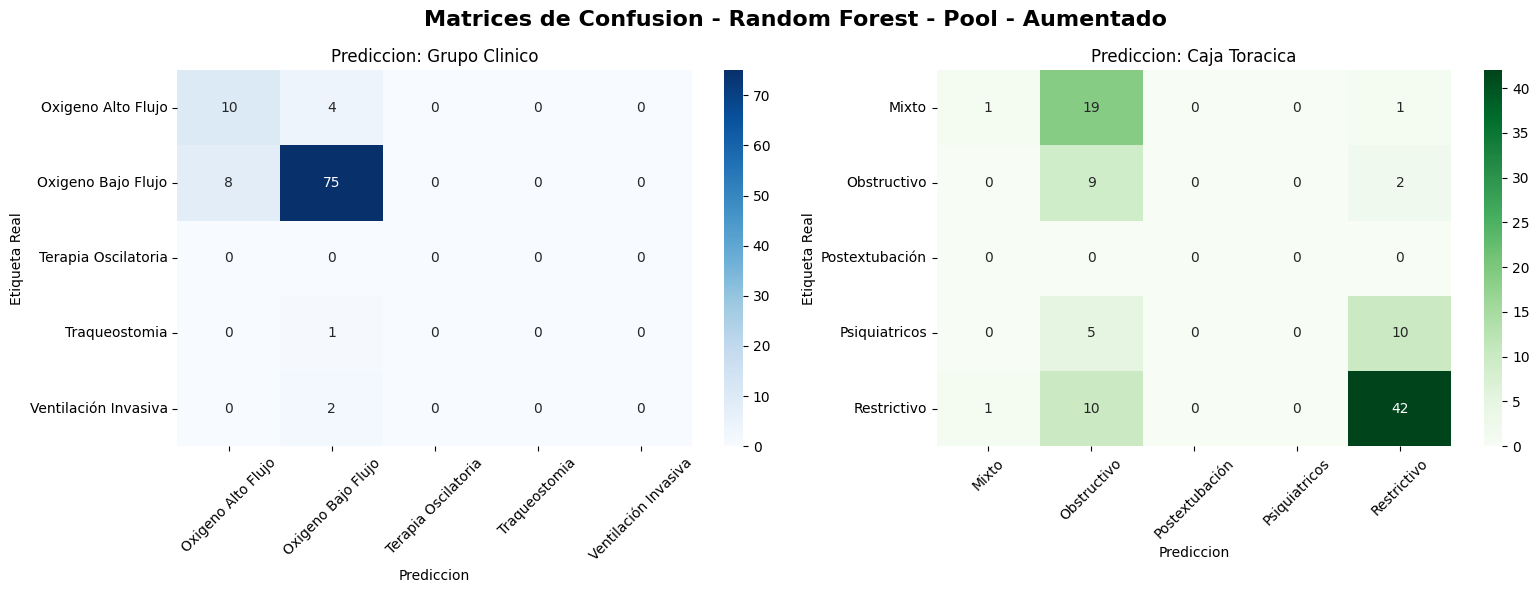

In [162]:
param_grid_rf_3_grupo_pool = {
    'n_estimators': [200, 300],      
    'max_depth': [None],        
    'min_samples_split': [5, 10],   
    'min_samples_leaf': [2, 6],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}

param_grid_rf_final_caja_pool = {
    'n_estimators': [100],      
    'max_depth': [20],        
    'min_samples_split': [5],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}


#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tune3"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_3_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Mejores Hiperparametros para Toracica: {'bootstrap': True, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
GRUPOS -> Accuracy: 88.00% | F1-Score (Macro): 39.44%
CAJA TORACICA -> Accuracy: 52.00% | F1-Score (Macro): 29.95%


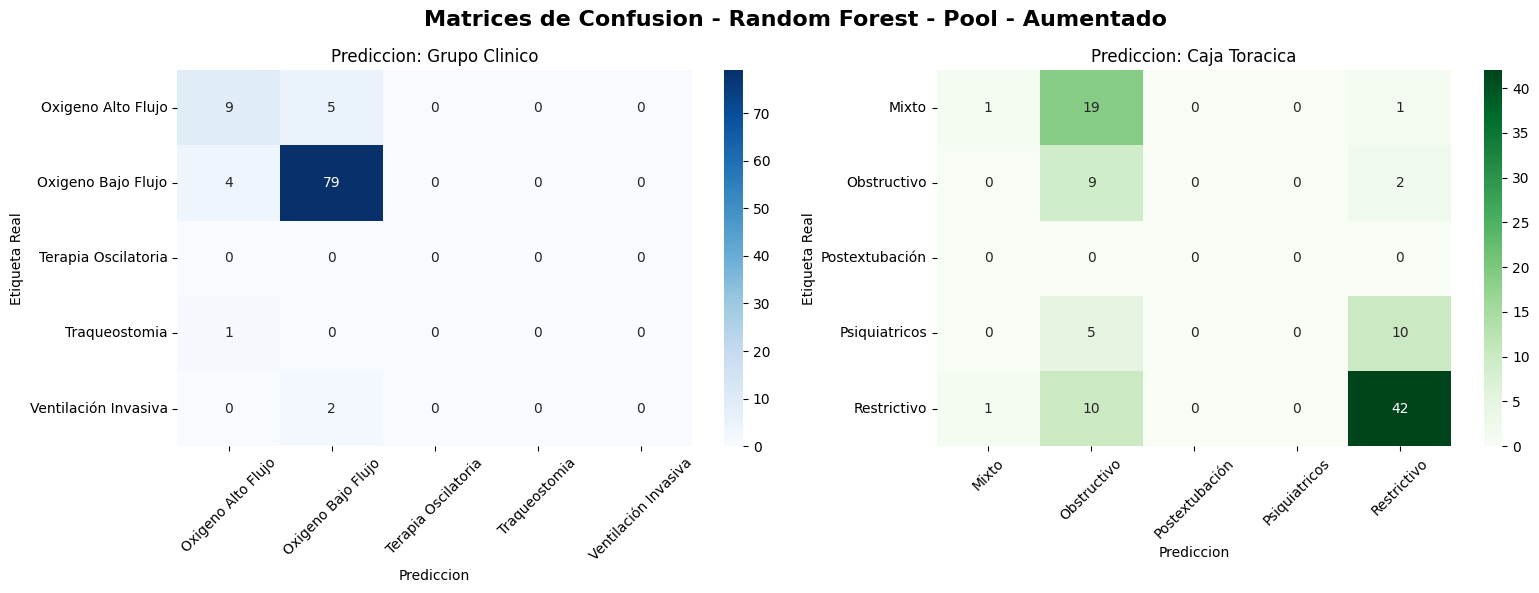

In [164]:
param_grid_rf_final_grupo_pool = {
    'n_estimators': [200],      
    'max_depth': [None],        
    'min_samples_split': [5],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]        
}

param_grid_rf_final_caja_pool = {
    'n_estimators': [100],      
    'max_depth': [20],        
    'min_samples_split': [5],   
    'min_samples_leaf': [2],    
    'max_features': ['sqrt'], 
    'bootstrap': [True]         
}
#Entrenamos para cada objetivo
with mlflow.start_run(run_name="RF_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "Random Forest")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    rf_base_grupo = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_grupo = GridSearchCV(rf_base_grupo, param_grid_rf_final_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_grupo.fit(X_train_model, y_train_grupo)
    
    rf_base_caja = RandomForestClassifier(class_weight='balanced', random_state=42)
    grid_rf_caja = GridSearchCV(rf_base_caja, param_grid_rf_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_rf_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_rf_grupo, grid_rf_caja, "Random Forest - Pool - Aumentado")

#### SVM

Mejores Hiperparametros para Grupo Clinico: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparametros para Toracica: {'C': 1.0, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 37.00% | F1-Score (Macro): 22.11%
CAJA TORACICA -> Accuracy: 58.00% | F1-Score (Macro): 34.00%


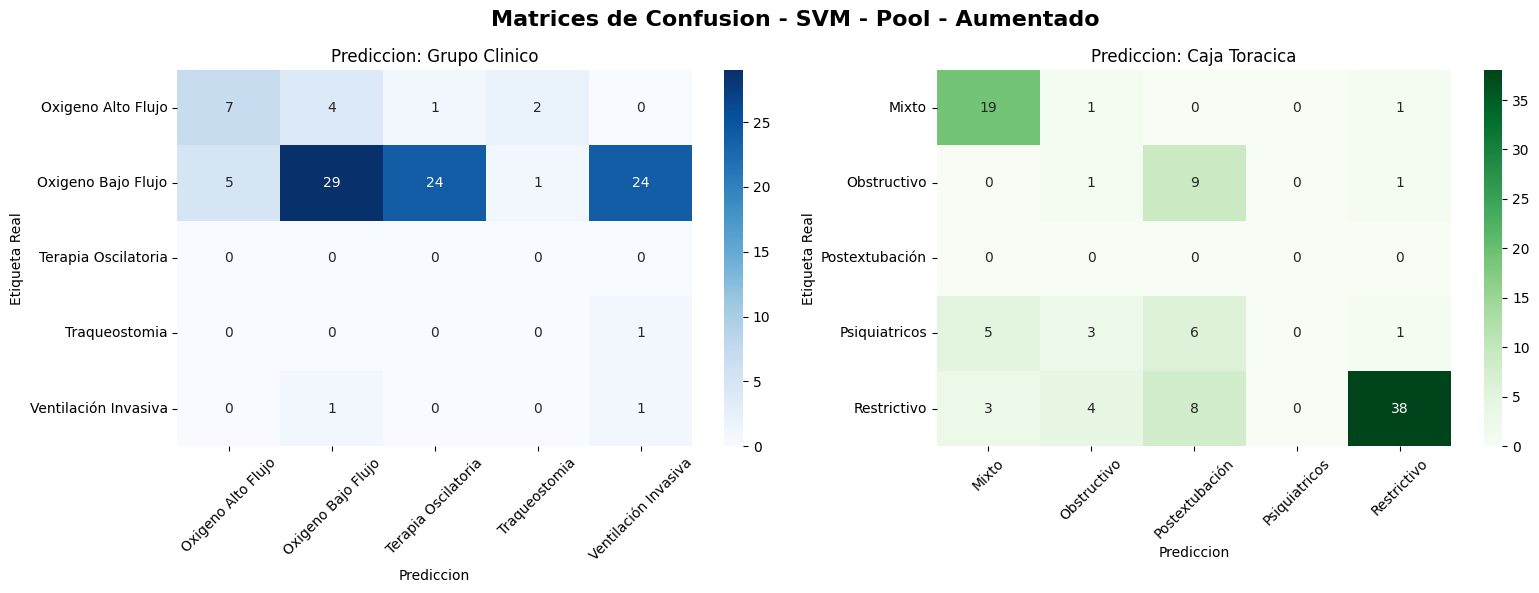

In [166]:
param_grid_svm = {
    'C': [1.0],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")
    


Mejores Hiperparametros para Grupo Clinico: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparametros para Toracica: {'C': 0.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 39.00% | F1-Score (Macro): 19.86%
CAJA TORACICA -> Accuracy: 56.00% | F1-Score (Macro): 32.03%


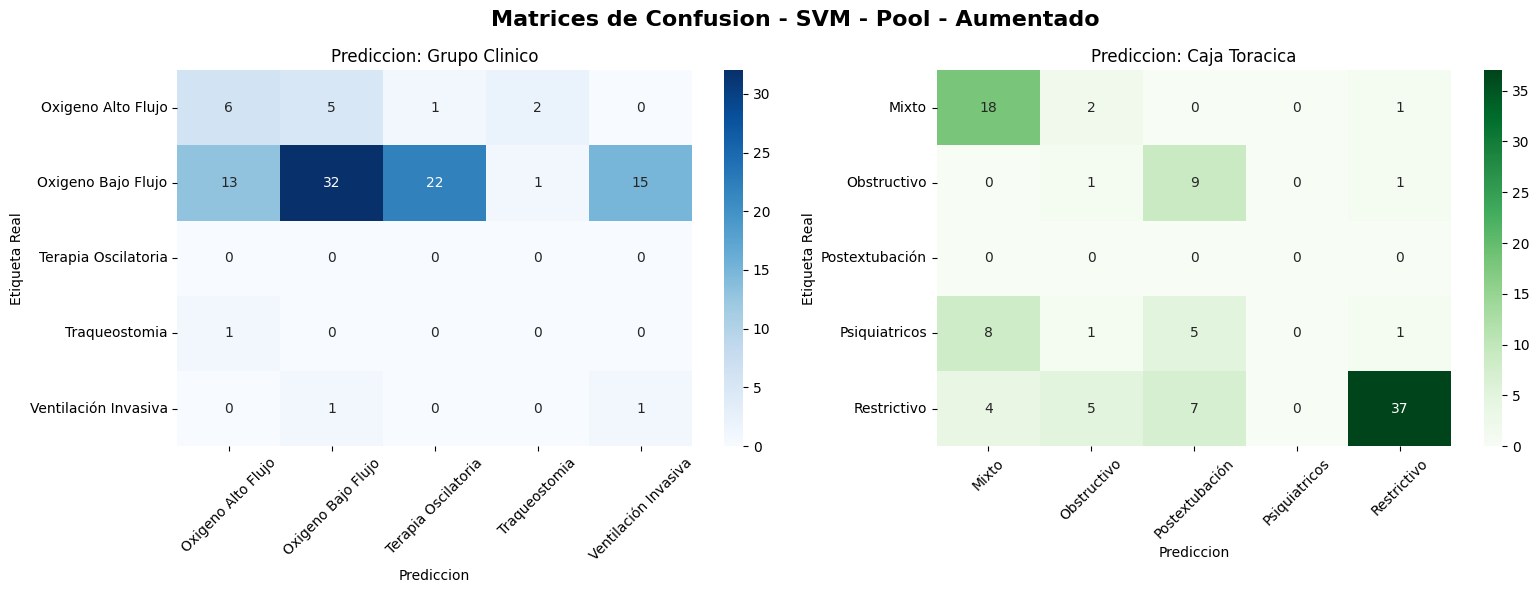

In [167]:
param_grid_svm_1 = {
    'C': [0.5, 1.0, 1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparametros para Toracica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 44.00% | F1-Score (Macro): 19.62%
CAJA TORACICA -> Accuracy: 58.00% | F1-Score (Macro): 34.35%


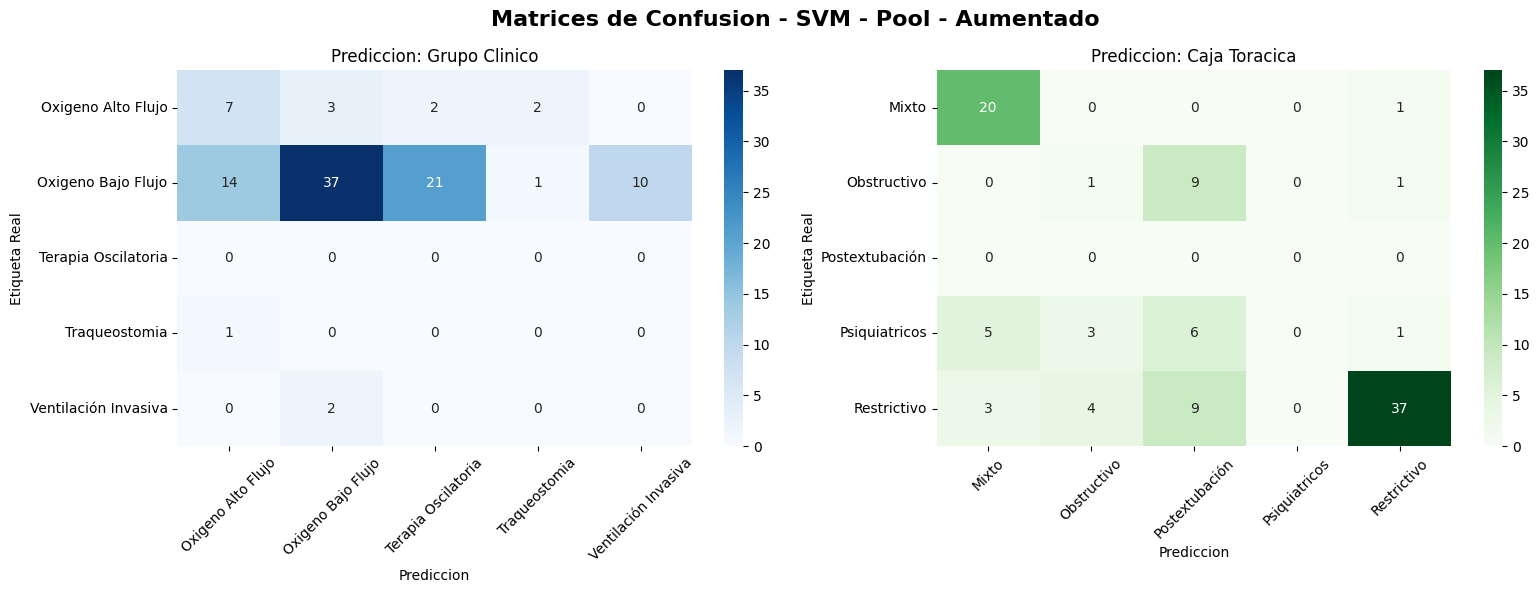

In [173]:
param_grid_svm_2_caja = {
    'C': [1.5, 2.0, 2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_2_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_2_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'C': 2.5, 'gamma': 'scale', 'kernel': 'rbf'}
Mejores Hiperparametros para Toracica: {'C': 1.5, 'gamma': 'scale', 'kernel': 'rbf'}
GRUPOS -> Accuracy: 44.00% | F1-Score (Macro): 19.62%
CAJA TORACICA -> Accuracy: 58.00% | F1-Score (Macro): 34.35%


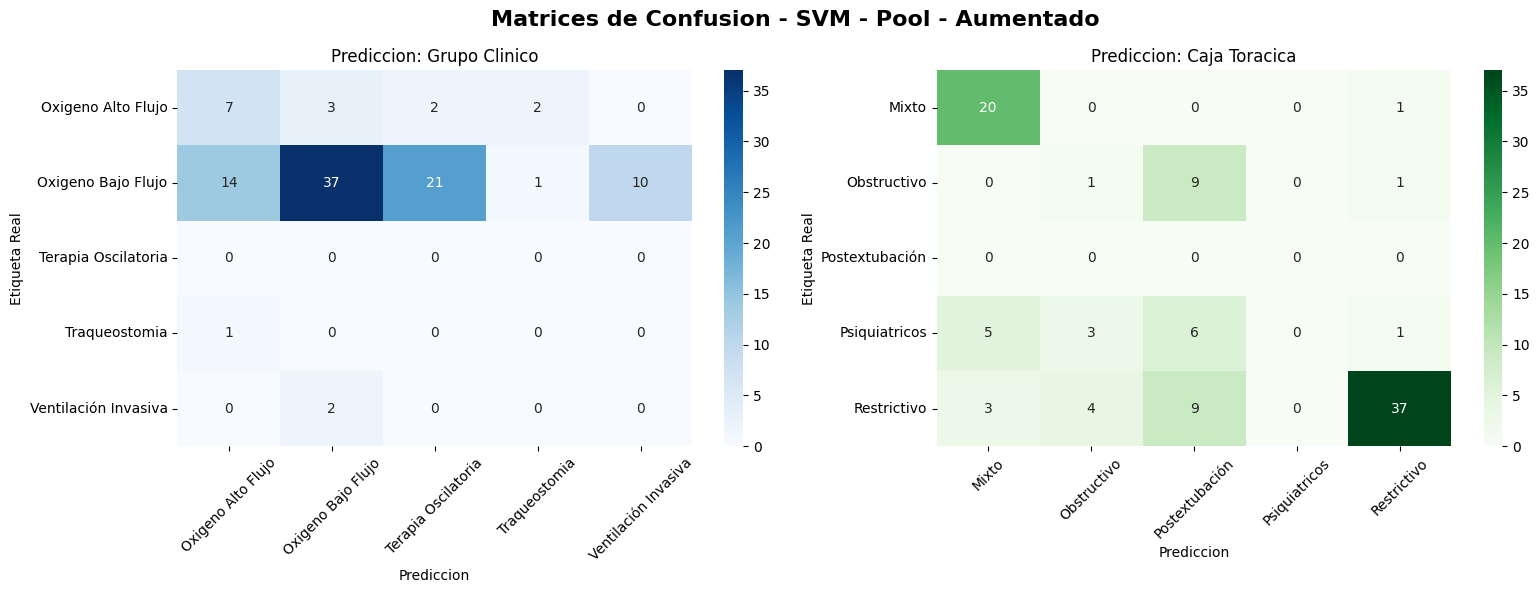

In [175]:
param_grid_svm_final_grupo = {
    'C': [2.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}
param_grid_svm_final_caja = {
    'C': [1.5],
    'kernel': ['rbf'],
    'gamma': ['scale']
}

with mlflow.start_run(run_name="SVM_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "SVM")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    svm_base_grupo = SVC(class_weight='balanced', random_state=42)
    grid_svm_grupo = GridSearchCV(svm_base_grupo, param_grid_svm_final_grupo, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_grupo.fit(X_train_model, y_train_grupo)
    
    svm_base_caja = SVC(class_weight='balanced', random_state=42)
    grid_svm_caja = GridSearchCV(svm_base_caja, param_grid_svm_final_caja, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_svm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_svm_grupo, grid_svm_caja, "SVM - Pool - Aumentado")

#### LigthGBM

Mejores Hiperparametros para Grupo Clinico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparametros para Toracica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 30.04%
CAJA TORACICA -> Accuracy: 53.00% | F1-Score (Macro): 33.09%


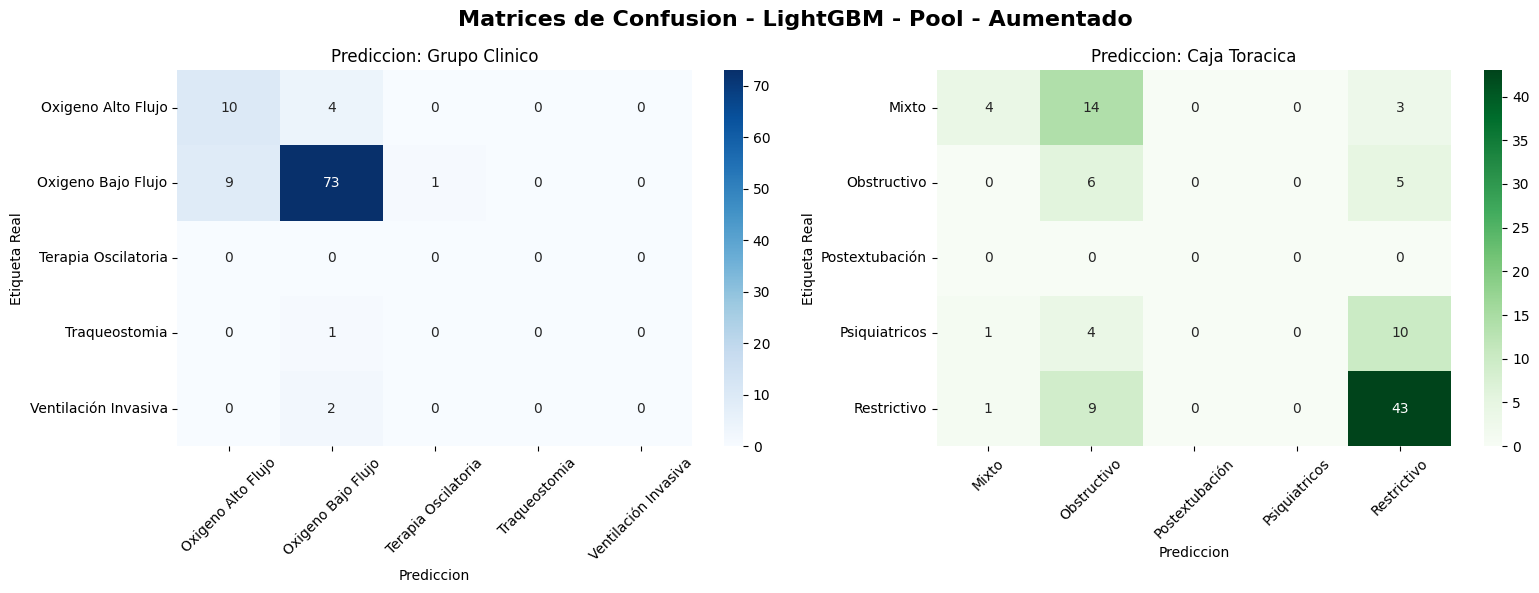

In [178]:
# Parámetros por defecto de LGBMClassifier:
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html
param_grid_lgbm = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")
    


Mejores Hiperparametros para Grupo Clinico: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
Mejores Hiperparametros para Toracica: {'learning_rate': 0.1, 'max_depth': 10, 'min_child_samples': 50, 'n_estimators': 200, 'num_leaves': 31}
GRUPOS -> Accuracy: 82.00% | F1-Score (Macro): 29.43%
CAJA TORACICA -> Accuracy: 49.00% | F1-Score (Macro): 29.32%


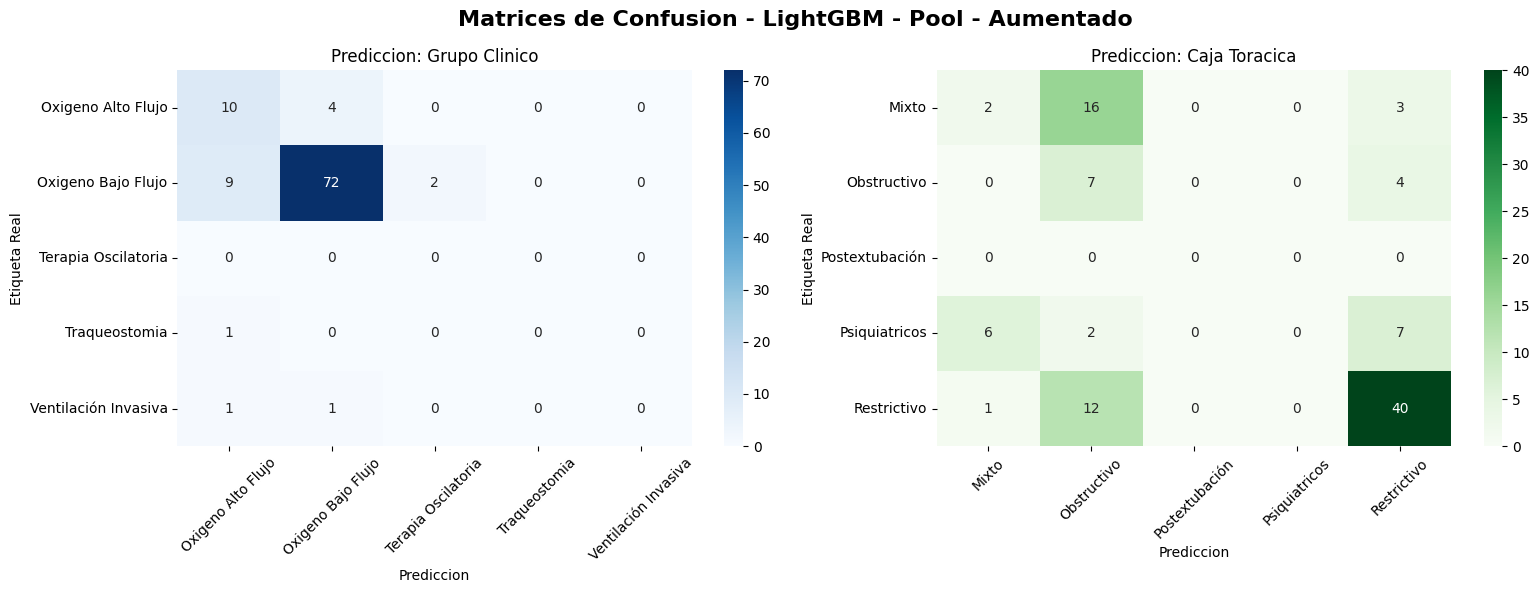

In [179]:
param_grid_lgbm_1 = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 63],
    'max_depth': [-1, 10],
    'min_child_samples': [20, 50]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_1, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'learning_rate': 0.15, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
Mejores Hiperparametros para Toracica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
GRUPOS -> Accuracy: 82.00% | F1-Score (Macro): 30.01%
CAJA TORACICA -> Accuracy: 54.00% | F1-Score (Macro): 35.94%


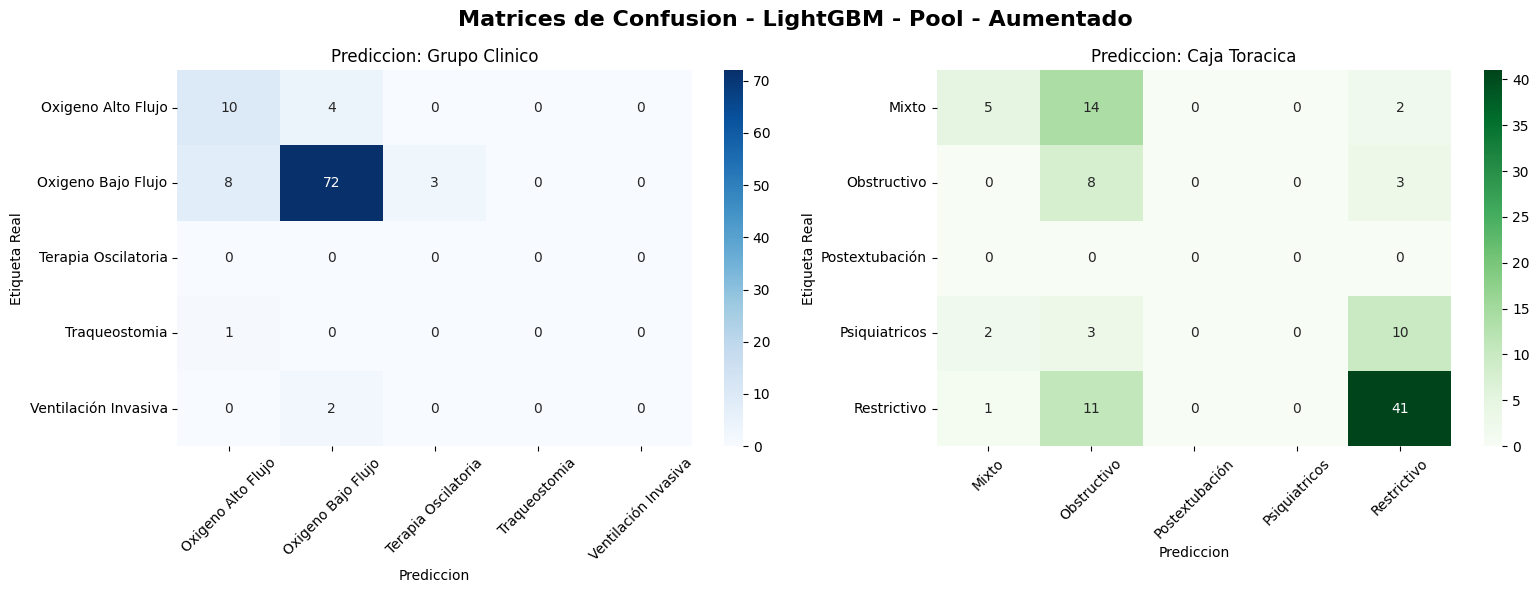

In [182]:
param_grid_lgbm_2_pool = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.1, 0.15],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_tune2"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_2_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_2_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 100, 'num_leaves': 31}
Mejores Hiperparametros para Toracica: {'learning_rate': 0.1, 'max_depth': -1, 'min_child_samples': 20, 'n_estimators': 300, 'num_leaves': 31}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 30.04%
CAJA TORACICA -> Accuracy: 54.00% | F1-Score (Macro): 35.94%


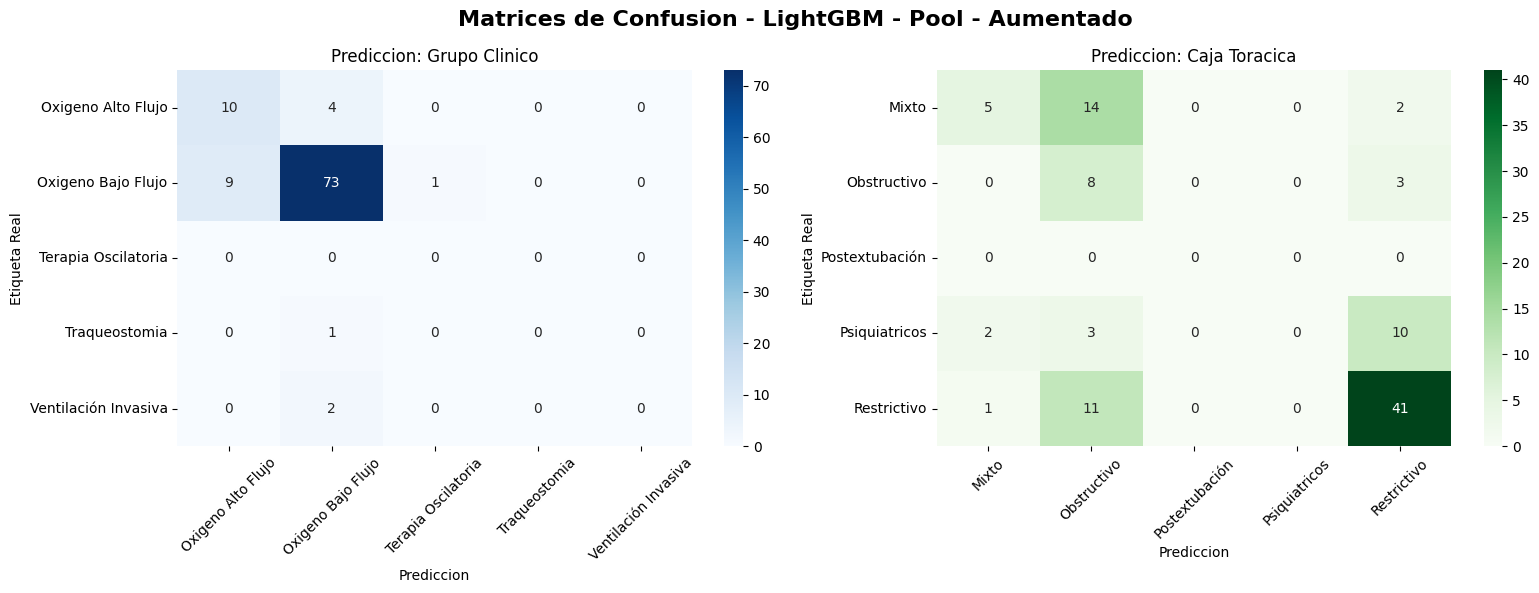

In [184]:
param_grid_lgbm_final_grupo_pool = {
    'n_estimators': [100],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

param_grid_lgbm_final_caja_pool = {
    'n_estimators': [300],
    'learning_rate': [0.1],
    'num_leaves': [31],
    'max_depth': [-1],
    'min_child_samples': [20]
}

with mlflow.start_run(run_name="LGB_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "LGB")
    mlflow.set_tag("feature_extraction", "Simple")
        
    #Entrenamos para cada objetivo
    lgbm_base_grupo = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_grupo = GridSearchCV(lgbm_base_grupo, param_grid_lgbm_final_grupo_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_grupo.fit(X_train_model, y_train_grupo)
    
    lgbm_base_caja = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=1, verbose=-1)
    grid_lgbm_caja = GridSearchCV(lgbm_base_caja, param_grid_lgbm_final_caja_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_lgbm_caja.fit(X_train_model, y_train_caja)
    
    evaluar_modelo_pool(grid_lgbm_grupo, grid_lgbm_caja, "LightGBM - Pool - Aumentado")

##### KNN

Mejores Hiperparametros para Grupo Clinico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparametros para Toracica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 36.82%
CAJA TORACICA -> Accuracy: 43.00% | F1-Score (Macro): 24.01%


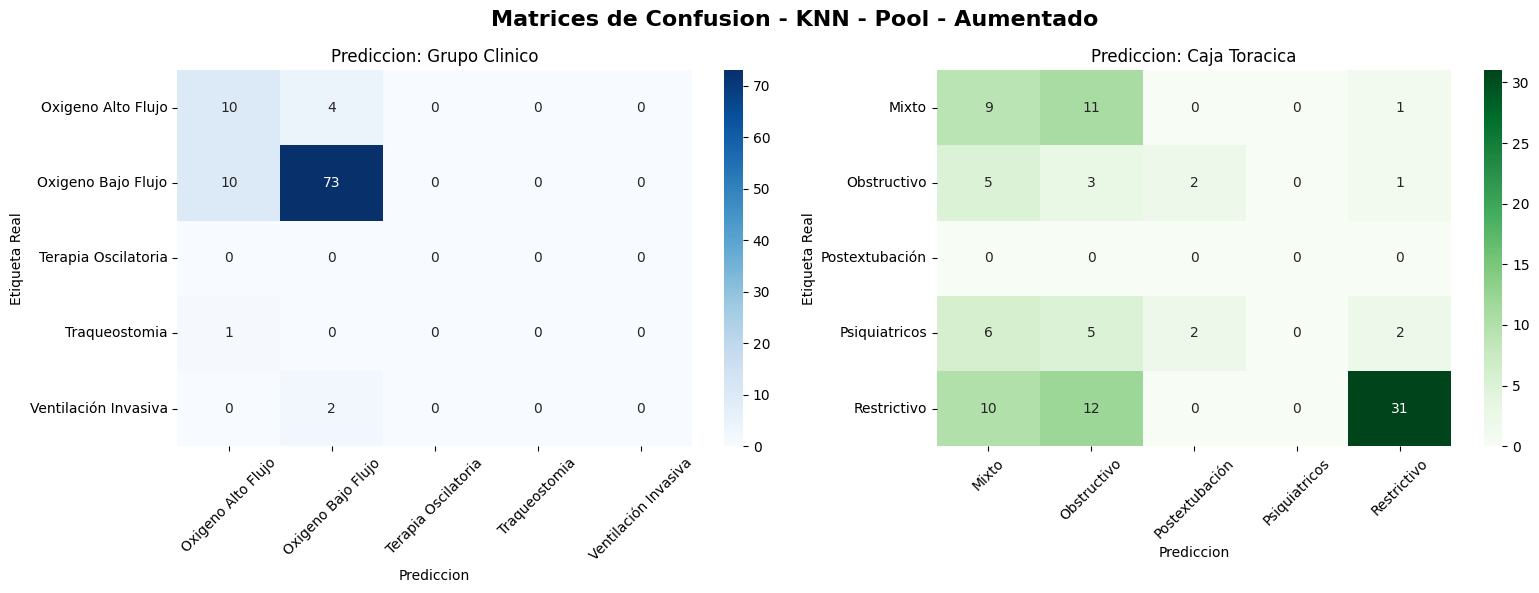

In [186]:
# Comenzamos con KNN: utilizando sus hiperparámetros de base:
# https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
param_grid_knn = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_default"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'algorithm': 'auto', 'metric': 'manhattan', 'n_neighbors': 9, 'weights': 'uniform'}
Mejores Hiperparametros para Toracica: {'algorithm': 'auto', 'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'uniform'}
GRUPOS -> Accuracy: 81.00% | F1-Score (Macro): 35.70%
CAJA TORACICA -> Accuracy: 43.00% | F1-Score (Macro): 22.51%


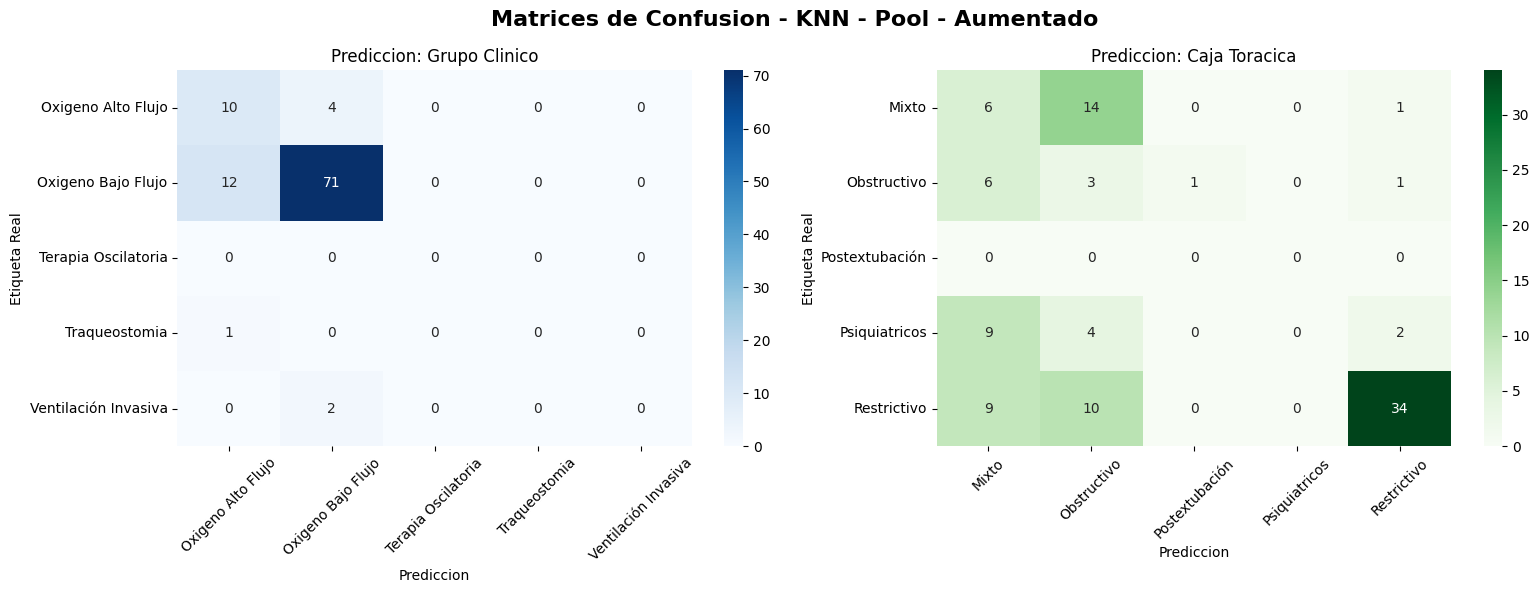

In [187]:
param_grid_knn_1_pool = {
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'metric': ['euclidean', 'manhattan', 'cosine'], 
    'algorithm': ['auto']                   
}

with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tune1"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_1_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_1_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}
Mejores Hiperparametros para Toracica: {'algorithm': 'auto', 'n_neighbors': 9, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 81.00% | F1-Score (Macro): 35.70%
CAJA TORACICA -> Accuracy: 43.00% | F1-Score (Macro): 22.51%


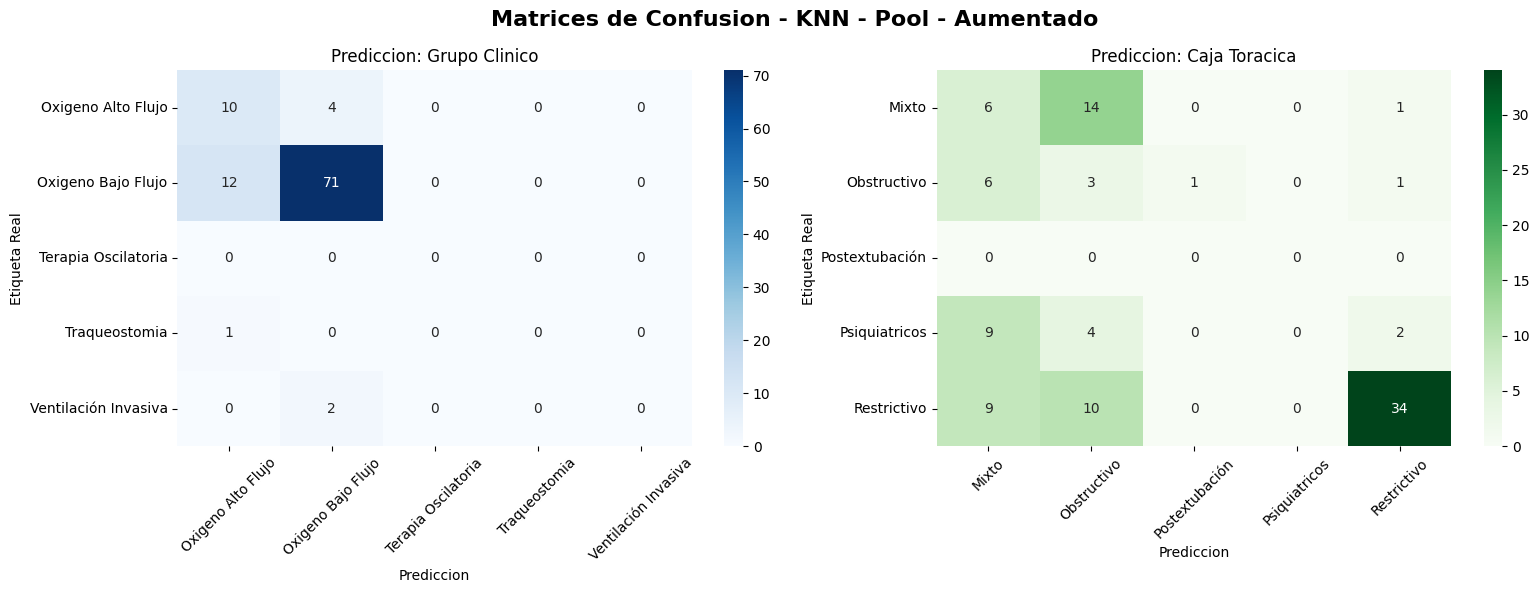

In [197]:
param_grid_knn_2_minkowski_pool = { #De base, la metrica elegida es minkowski. Modificamos el p = potenciador de dicha métrica
    'n_neighbors': [3, 5, 9],   
    'weights': ['uniform', 'distance'],     
    'p': [1, 2, 3],
    'algorithm': ['auto']                   
}


with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tune2_minkowski"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_2_minkowski_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_2_minkowski_pool, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

Mejores Hiperparametros para Grupo Clinico: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
Mejores Hiperparametros para Toracica: {'algorithm': 'auto', 'n_neighbors': 5, 'p': 2, 'weights': 'uniform'}
GRUPOS -> Accuracy: 83.00% | F1-Score (Macro): 36.82%
CAJA TORACICA -> Accuracy: 43.00% | F1-Score (Macro): 24.01%


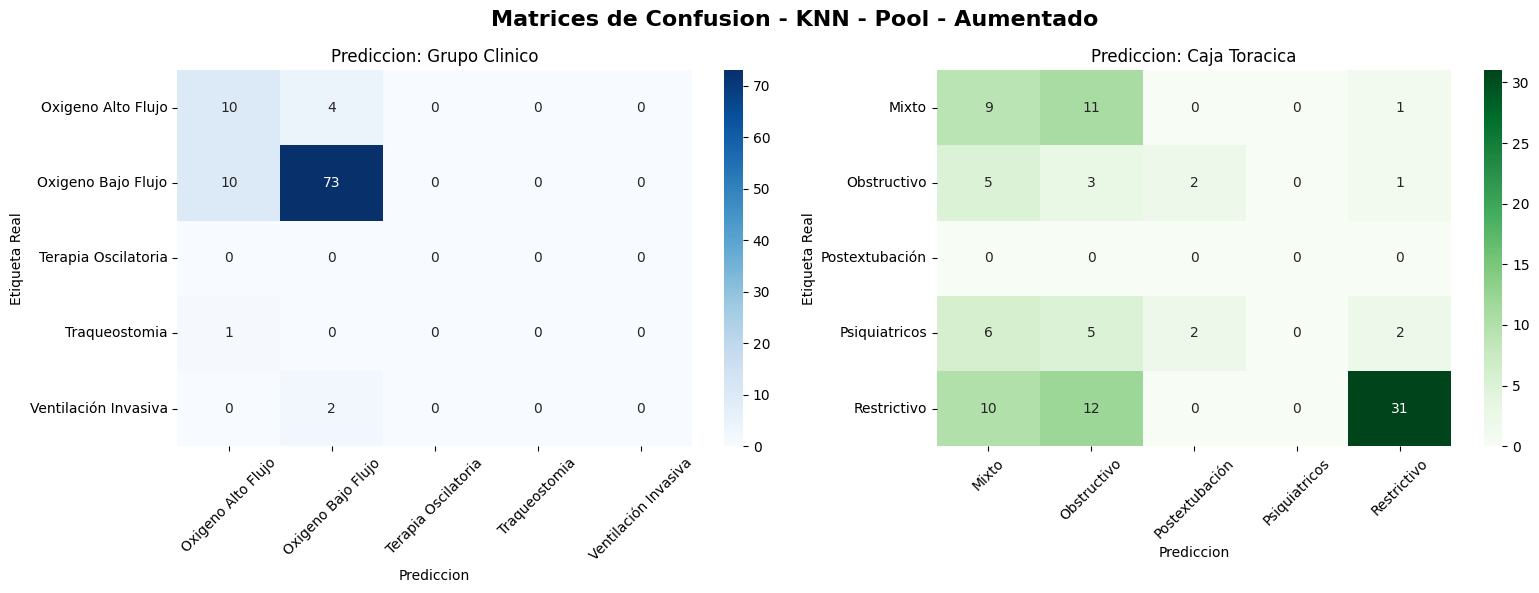

In [199]:
param_grid_knn_final = {
    'n_neighbors': [5],       
    'weights': ['uniform'],   
    'algorithm': ['auto'],    
    'p': [2]                 
}

# Entrenamos para el objetivo de Grupo Clínico
with mlflow.start_run(run_name="KNN_Chunking_Diarizado_Aumentado_pool_tunefinal"):

    mlflow.set_tag("tipo_dataset", "Chunking_Diarizado_Aumentado_pool") 
    mlflow.set_tag("modelo", "KNN")
    mlflow.set_tag("feature_extraction", "Simple")
        
    # Entrenamos para el objetivo de Grupo Clínico
    knn_base_grupo = KNeighborsClassifier()
    grid_knn_grupo = GridSearchCV(knn_base_grupo, param_grid_knn_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_grupo.fit(X_train_model, y_train_grupo)
    
    # Entrenamos para el objetivo de Caja Torácica
    knn_base_caja = KNeighborsClassifier()
    grid_knn_caja = GridSearchCV(knn_base_caja, param_grid_knn_final, scoring=scoring_cv, refit='f1_macro', cv=ps, n_jobs=-1)
    grid_knn_caja.fit(X_train_model, y_train_caja)
    
    # Evaluamos usando tu función personalizada
    evaluar_modelo_pool(grid_knn_grupo, grid_knn_caja, "KNN - Pool - Aumentado")

## Evaluación Final: Test

> Ejecutar estas celdas **una sola vez**, después de decidir qué modelo y preprocesamiento usar basándote en los resultados de CV anteriores.

La función `evaluar_modelo_test` muestra: métricas, classification report, matrices de confusión y curvas AUC-ROC sobre el conjunto de **test**.

In [ ]:
def evaluar_modelo_test(modelo_grupo, modelo_caja, X_test_grupo, X_test_caja,
                        y_test_grupo, y_test_caja, nombre_modelo):
    """
    Evaluación final sobre el conjunto de test (sin validación cruzada).
    - PCA+flat / Pool: pasar el mismo array en X_test_grupo y X_test_caja
    - KBest:           X_test_grupo = X_test_grupo_selected
                       X_test_caja  = X_test_caja_selected
    """
    import numpy as np

    pred_grupo = modelo_grupo.predict(X_test_grupo)
    pred_caja  = modelo_caja.predict(X_test_caja)

    # --- Métricas escalares ---
    acc_g = accuracy_score(y_test_grupo, pred_grupo)
    f1_mg = f1_score(y_test_grupo, pred_grupo, average='macro',zero_division=0)
    f1_wg = f1_score(y_test_grupo, pred_grupo, average='weighted', zero_division=0)
    acc_c = accuracy_score(y_test_caja,  pred_caja)
    f1_mc = f1_score(y_test_caja,  pred_caja,  average='macro', zero_division=0)
    f1_wc = f1_score(y_test_caja,  pred_caja,  average='weighted', zero_division=0)
    print(f"[TEST] Grupo - Acc: {acc_g*100:.2f}% | F1-Macro: {f1_mg*100:.2f}% | F1-Weighted: {f1_wg*100:.2f}%")
    print(f"[TEST] Caja  - Acc: {acc_c*100:.2f}% | F1-Macro: {f1_mc*100:.2f}% | F1-Weighted: {f1_wc*100:.2f}%")

    # --- Classification reports ---
    print("\n--- Classification Report: Grupo ---")
    print(classification_report(y_test_grupo, pred_grupo, zero_division=0))
    print("\n--- Classification Report: Caja Torácica ---")
    print(classification_report(y_test_caja, pred_caja, zero_division=0))

    # --- Matrices de confusión ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Matrices de Confusión [TEST] - {nombre_modelo}', fontsize=14, fontweight='bold')
    cm_g = confusion_matrix(y_test_grupo, pred_grupo)
    sns.heatmap(cm_g, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Grupo Clínico')
    axes[0].set_ylabel('Real'); axes[0].set_xlabel('Predicción')
    axes[0].tick_params(axis='x', rotation=45)
    cm_c = confusion_matrix(y_test_caja, pred_caja)
    sns.heatmap(cm_c, annot=True, fmt='d', cmap='Greens', ax=axes[1])
    axes[1].set_title('Caja Torácica')
    axes[1].set_ylabel('Real'); axes[1].set_xlabel('Predicción')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    # --- AUC-ROC ---
    clases_g = np.unique(y_test_grupo)
    clases_c = np.unique(y_test_caja)
    y_score_g = modelo_grupo.predict_proba(X_test_grupo)
    y_score_c = modelo_caja.predict_proba(X_test_caja)
    y_bin_g = label_binarize(y_test_grupo, classes=clases_g)
    y_bin_c = label_binarize(y_test_caja,  classes=clases_c)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'AUC-ROC [TEST] - {nombre_modelo}', fontsize=14, fontweight='bold')
    for i, cls in enumerate(clases_g):
        fpr, tpr, _ = roc_curve(y_bin_g[:, i], y_score_g[:, i])
        axes[0].plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    axes[0].plot([0, 1], [0, 1], 'k--')
    axes[0].set_title('Grupo Clínico'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].legend(fontsize=8)
    for i, cls in enumerate(clases_c):
        fpr, tpr, _ = roc_curve(y_bin_c[:, i], y_score_c[:, i])
        axes[1].plot(fpr, tpr, label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_title('Caja Torácica'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [ ]:
# =========================================================
# TEST FINAL: Random Forest
# Elige el preprocesamiento con mejor resultado en CV
# =========================================================

# ← COMPLETAR: elige el conjunto de datos según la técnica elegida
# PCA+flat:  X_train_rf = X_train_model,         X_test_rf = X_test_model  (mismo para grupo y caja)
# KBest:     X_train_rf_grupo = X_train_grupo_selected, X_test_rf_grupo = X_test_grupo_selected
#            X_train_rf_caja  = X_train_caja_selected,  X_test_rf_caja  = X_test_caja_selected
# Pool:      X_train_rf = X_train_model,         X_test_rf = X_test_model  (variables del bloque Pool)

X_train_rf_grupo = ...  # ← COMPLETAR
X_test_rf_grupo  = ...  # ← COMPLETAR
X_train_rf_caja  = ...  # ← COMPLETAR (puede ser igual a X_train_rf_grupo si no es KBest)
X_test_rf_caja   = ...  # ← COMPLETAR

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
modelo_rf_grupo = RandomForestClassifier(
    n_estimators=...,       # ← COMPLETAR
    max_depth=...,          # ← COMPLETAR
    min_samples_split=...,  # ← COMPLETAR
    random_state=42
)
modelo_rf_caja = RandomForestClassifier(
    n_estimators=...,       # ← COMPLETAR
    max_depth=...,          # ← COMPLETAR
    min_samples_split=...,  # ← COMPLETAR
    random_state=42
)

modelo_rf_grupo.fit(X_train_rf_grupo, y_train_grupo)
modelo_rf_caja.fit(X_train_rf_caja,   y_train_caja)

evaluar_modelo_test(modelo_rf_grupo, modelo_rf_caja,
                    X_test_rf_grupo, X_test_rf_caja,
                    y_test_grupo, y_test_caja,
                    "RF_Test_Final")

In [ ]:
# =========================================================
# TEST FINAL: SVM
# Elige el preprocesamiento con mejor resultado en CV
# =========================================================

# ← COMPLETAR: elige el conjunto de datos según la técnica elegida
# PCA+flat:  X_train_svm = X_train_model,         X_test_svm = X_test_model
# KBest:     X_train_svm_grupo = X_train_grupo_selected, X_test_svm_grupo = X_test_grupo_selected
#            X_train_svm_caja  = X_train_caja_selected,  X_test_svm_caja  = X_test_caja_selected
# Pool:      X_train_svm = X_train_model,         X_test_svm = X_test_model  (variables del bloque Pool)

X_train_svm_grupo = ...  # ← COMPLETAR
X_test_svm_grupo  = ...  # ← COMPLETAR
X_train_svm_caja  = ...  # ← COMPLETAR
X_test_svm_caja   = ...  # ← COMPLETAR

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
# Nota: SVC(probability=True) es necesario para AUC-ROC con predict_proba
modelo_svm_grupo = SVC(
    C=...,        # ← COMPLETAR
    kernel=...,   # ← COMPLETAR  p.ej. 'rbf'
    gamma=...,    # ← COMPLETAR  p.ej. 'scale'
    probability=True,
    random_state=42
)
modelo_svm_caja = SVC(
    C=...,        # ← COMPLETAR
    kernel=...,   # ← COMPLETAR
    gamma=...,    # ← COMPLETAR
    probability=True,
    random_state=42
)

modelo_svm_grupo.fit(X_train_svm_grupo, y_train_grupo)
modelo_svm_caja.fit(X_train_svm_caja,   y_train_caja)

evaluar_modelo_test(modelo_svm_grupo, modelo_svm_caja,
                    X_test_svm_grupo, X_test_svm_caja,
                    y_test_grupo, y_test_caja,
                    "SVM_Test_Final")

In [ ]:
# =========================================================
# TEST FINAL: LightGBM
# Elige el preprocesamiento con mejor resultado en CV
# =========================================================

# ← COMPLETAR: elige el conjunto de datos según la técnica elegida
# PCA+flat:  X_train_lgbm = X_train_model,         X_test_lgbm = X_test_model
# KBest:     X_train_lgbm_grupo = X_train_grupo_selected, X_test_lgbm_grupo = X_test_grupo_selected
#            X_train_lgbm_caja  = X_train_caja_selected,  X_test_lgbm_caja  = X_test_caja_selected
# Pool:      X_train_lgbm = X_train_model,         X_test_lgbm = X_test_model  (variables del bloque Pool)

X_train_lgbm_grupo = ...  # ← COMPLETAR
X_test_lgbm_grupo  = ...  # ← COMPLETAR
X_train_lgbm_caja  = ...  # ← COMPLETAR
X_test_lgbm_caja   = ...  # ← COMPLETAR

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
modelo_lgbm_grupo = LGBMClassifier(
    n_estimators=...,    # ← COMPLETAR
    learning_rate=...,   # ← COMPLETAR
    max_depth=...,       # ← COMPLETAR
    num_leaves=...,      # ← COMPLETAR
    random_state=42,
    verbose=-1
)
modelo_lgbm_caja = LGBMClassifier(
    n_estimators=...,    # ← COMPLETAR
    learning_rate=...,   # ← COMPLETAR
    max_depth=...,       # ← COMPLETAR
    num_leaves=...,      # ← COMPLETAR
    random_state=42,
    verbose=-1
)

modelo_lgbm_grupo.fit(X_train_lgbm_grupo, y_train_grupo)
modelo_lgbm_caja.fit(X_train_lgbm_caja,   y_train_caja)

evaluar_modelo_test(modelo_lgbm_grupo, modelo_lgbm_caja,
                    X_test_lgbm_grupo, X_test_lgbm_caja,
                    y_test_grupo, y_test_caja,
                    "LGBM_Test_Final")

In [ ]:
# =========================================================
# TEST FINAL: KNN
# Elige el preprocesamiento con mejor resultado en CV
# =========================================================

# ← COMPLETAR: elige el conjunto de datos según la técnica elegida
# PCA+flat:  X_train_knn = X_train_model,         X_test_knn = X_test_model
# KBest:     X_train_knn_grupo = X_train_grupo_selected, X_test_knn_grupo = X_test_grupo_selected
#            X_train_knn_caja  = X_train_caja_selected,  X_test_knn_caja  = X_test_caja_selected
# Pool:      X_train_knn = X_train_model,         X_test_knn = X_test_model  (variables del bloque Pool)

X_train_knn_grupo = ...  # ← COMPLETAR
X_test_knn_grupo  = ...  # ← COMPLETAR
X_train_knn_caja  = ...  # ← COMPLETAR
X_test_knn_caja   = ...  # ← COMPLETAR

# ← COMPLETAR: introduce los mejores hiperparámetros encontrados en CV (consultar MLflow)
modelo_knn_grupo = KNeighborsClassifier(
    n_neighbors=...,  # ← COMPLETAR
    weights=...,      # ← COMPLETAR  p.ej. 'uniform' o 'distance'
    metric=...,       # ← COMPLETAR  p.ej. 'minkowski'
)
modelo_knn_caja = KNeighborsClassifier(
    n_neighbors=...,  # ← COMPLETAR
    weights=...,      # ← COMPLETAR
    metric=...,       # ← COMPLETAR
)

modelo_knn_grupo.fit(X_train_knn_grupo, y_train_grupo)
modelo_knn_caja.fit(X_train_knn_caja,   y_train_caja)

# Nota: KNN tiene predict_proba nativo, no hace falta probability=True
evaluar_modelo_test(modelo_knn_grupo, modelo_knn_caja,
                    X_test_knn_grupo, X_test_knn_caja,
                    y_test_grupo, y_test_caja,
                    "KNN_Test_Final")